# Logistic Regression from First Principles (Credit Card Fraud Detection)

## Project Workflow

This project follows a complete end-to-end machine learning pipeline:

1. Problem Definition
2. Business Context
3. Constraint
4. Dataset Understanding
5. Mathematical Objective
6. Evaluation Philosophy
7. Experimentation Design
8. Initial Hypotheses
9. Data Handling
10. Exploratory Data Analysis (EDA)
11. Mathematical Rundown
13. Full Model Pipeline:

        - Load & preprocess
        - Three-way stratified split (train / val / test)
        - Z-score normalisation (fit on train only)
        - SMOTE — from scratch
        - LogisticRegression class — from scratch
        - Standalone math functions (sigmoid, BCE, gradient)
        - Metrics — from scratch
        - Model A — Weighted BCE loss + early stopping
        - Model B — SMOTE oversampling + early stopping
        - Model Comparisons: 
                - Decision Tree
                - Random Forest
                - XG Boost
                - SK Learn LogisticRegression
        - Threshold optimisation on validation set (F-beta, beta=2)
        - Final evaluation on test set
        - Visualisations

14.  Evaluation Pipeline
        - Learning curve diagnostics
        - Dummy Classifier baseline
        - Getting test set probabilities
        - Default threshold evaluation (0.5)
        - ROC Curve
        - Precision - Recall Curve
        - Threshold optimization
        - Error Analysis
        - Feature weight Analysis
        - Calibration check
        - Model assumptions
        - Dataset issues
        - Performance ceiling & model limitations
     
15. Conclusion: Insights, pipeline overview, feature vector and vector formulation, results and ways to increase performance.

## Problem Definition

## Task Type

Binary classification under severe class imbalance.

The objective is to determine whether a financial transaction is fraudulent or legitimate based on a set of anonymized transaction features.

---

## Dataset Characteristics

The dataset contains **284,807** credit card transactions with only **492 fraudulent samples**, resulting in an approximate fraud ratio of:

$$ \frac{284315}{492} \approx 577.88 \approx 578:1 $$

This extreme imbalance makes the problem substantially different from standard balanced classification tasks.

---

## Input

A single transaction represented as a 30-dimensional feature vector:

$$ x = [ \text{Time, } V_1, V_2, \dots, V_{28}, \text{ Amount} ] $$

Where:

- `V1–V28` are PCA-transformed anonymized features
- `Time` represents the number of seconds elapsed since the first transaction
- `Amount` represents the transaction value

---

## Output

The model outputs a probability estimate:

$$ P(y=1 \mid x) $$

representing the likelihood that the transaction is fraudulent.

A decision threshold \( \tau \) is then applied to convert probabilities into hard class predictions:

$$ \hat{y} = 
\begin{cases} 
1 & \text{if } P(y=1 \mid x) \geq \tau \\
0 & \text{otherwise} 
\end{cases} $$

Where:

- `1` = Fraudulent transaction
- `0` = Legitimate transaction

---

# Core Challenge

Accuracy is fundamentally misleading for this dataset.

A naive classifier that predicts every transaction as legitimate achieves approximately:

$$ \frac{284315}{284807} \times 100 \approx 99.83\% $$

accuracy while detecting **zero fraudulent transactions**.

Therefore, the primary challenge is not maximizing overall accuracy, but instead:

- Maximizing fraud detection capability (**Recall**)
- Minimizing unnecessary fraud alerts (**False Positives**)
- Finding an operational balance between both objectives

This transforms the task from a standard classification problem into a **cost-sensitive decision problem**.

---

# Project Objective

The primary objective of this project is to build a **Logistic Regression classifier from first principles** capable of effectively discriminating fraudulent transactions from legitimate ones under severe class imbalance.

More specifically, this project aims to:

- Maximize fraud-class Recall
- Maintain acceptable Precision
- Optimize the minority-class F1-score
- Identify the optimal classification threshold on the Precision-Recall tradeoff curve

The selected threshold should represent a practical operating point where:

- Missed frauds are minimized
- False alarms remain operationally tolerable

---

# Success Criteria

| Metric | Importance |
|---|---|
| Recall (Fraud Class) | Measures ability to capture fraudulent transactions. Low recall implies missed fraud and direct financial loss. |
| Precision (Fraud Class) | Measures reliability of fraud alerts. Low precision increases customer friction and operational overhead. |
| F1-Score | Harmonic balance between Precision and Recall under severe class imbalance. |
| PR-AUC | Preferred aggregate metric for highly imbalanced classification problems. |
| ROC-AUC | Secondary metric measuring separability across thresholds. |

---

# Important Note

Accuracy is explicitly excluded as a primary evaluation metric due to the dataset's severe class imbalance.

## Business Context

A European card issuer processes hundreds of thousands of transactions daily. A very small fraction of these transactions are fraudulent, involving unauthorized payments made using stolen or compromised cards.

Undetected fraud results in direct financial loss to the institution and potentially to affected customers.  
Conversely, incorrectly flagging legitimate transactions as fraud creates customer friction, failed purchases, support overhead, and reputational damage.

The institution therefore requires a fraud detection system capable of:

- Detecting fraudulent transactions as early as possible
- Minimizing missed fraud cases
- Maintaining a controllable false-positive rate
- Operating effectively under extreme class imbalance

The problem is inherently cost-sensitive:

- False Negatives (missed fraud) carry financial risk
- False Positives (incorrect fraud alerts) carry operational and customer-experience costs

The objective is not merely to build a statistically accurate classifier, but to develop a model with a practical operating threshold suitable for real-world fraud detection systems.

# Constraints

The implementation is intentionally constrained to emphasize first-principles understanding of Logistic Regression and imbalanced binary classification.

The following constraints apply throughout the project:

- No use of high-level machine learning frameworks such as `scikit-learn` for model training
- All core components are implemented manually using NumPy, including:
   
  - Sigmoid function
  - Binary Cross-Entropy (Log Loss)
  - Gradient computation
  - Gradient Descent optimization
  - Prediction pipeline
  - Evaluation metrics
  - Threshold tuning logic
  - Sampling procedures

- `scikit-learn` is only used afterwards for:
- 
  - Benchmark comparisons
  - Validation against industry-standard implementations

- The model must expose a tunable decision threshold rather than relying solely on the default:

$$ \tau = 0.5 $$

This is necessary because threshold selection significantly affects Precision–Recall tradeoffs under severe class imbalance.

- Evaluation is performed using a stratified hold-out split to preserve the original fraud-to-legitimate transaction ratio across:

  - Training set
  - Validation set
  - Test set

- Data leakage must be strictly avoided:

  - Any normalization or scaling parameters learns exclusively from the training set
  - Validation and test data remains unseen during training

## Data Understanding

| Attribute | Description |
|---|---|
| **Source** | Kaggle — ULB Machine Learning Group |
| **Citation** | Andrea Dal Pozzolo et al. — Université Libre de Bruxelles |
| **Rows** | 284,807 credit card transactions |
| **Fraud Cases** | 492 transactions (~0.172%) |
| **Legitimate Transactions** | 284,315 transactions |
| **Class Imbalance Ratio** | ~577 : 1 |
| **Time Period** | September 2013 (2 days) |
| **Region** | European cardholders |
| **Features** | `Time`, `Amount`, `V1–V28` |
| **Target Variable** | `Class` (`0` = Legitimate, `1` = Fraud) |
| **Missing Values** | None |
| **Data Types** | All numerical (`float64`) |

---

## Feature Description

The dataset contains:

$$30 \text{ input features} + 1 \text{ target} = 31 \text{ columns}$$

---

## `Time`

Number of seconds elapsed between the current transaction and the first transaction in the dataset.

$$\text{Range: } 0 \rightarrow 172{,}792 \text{ seconds} \approx 48 \text{ hours}$$

> **Preprocessing note:** `Time` in raw seconds is unlikely to be a meaningful linear predictor.  
> It will be retained and Z-score normalised alongside `Amount` to bring it onto a comparable  
> scale with the PCA features. Cyclical feature engineering (hour-of-day) is noted as a potential  
> improvement but is outside the scope of this first-principles implementation.

---

## `Amount`

Transaction amount associated with the payment. This is the only directly business-interpretable financial feature in the dataset.

> **Preprocessing note:** Transaction amounts are typically heavy-tailed with extreme outliers.  
> This feature will be Z-score normalised. Log-transformation prior to scaling is noted as a  
> potential refinement if the raw distribution is found to be severely skewed during EDA.

---

## `V1–V28`

PCA-transformed anonymized numerical features. Original feature names and meanings were intentionally hidden by the dataset authors to protect cardholder privacy.

- Direct business interpretation of `V1–V28` is not possible
- These features are already approximately decorrelated relative to the original feature space
- Their variance structure is already compressed by PCA

> **Preprocessing note:** Z-score normalisation will be applied uniformly across all 30 features  
> including `V1–V28`. Applying Z-scoring to PCA components that are already approximately  
> unit-variance is low-risk and marginally redundant, but ensures consistent scale across the  
> full feature vector and avoids any assumption about the exact variance structure of the  
> PCA output.

---

## Target Variable — `Class`

Binary target label:
- `0` → Legitimate transaction
- `1` → Fraudulent transaction

---

## Initial Diagnostics

| Observation | Diagnostic |
|---|---|
| Class imbalance | Extremely severe (~577:1) |
| Missing values | None detected |
| Feature types | Entirely numerical |
| PCA features | Already transformed and approximately decorrelated |
| Feature scaling | `Time` and `Amount` exist on much larger scales than PCA components |
| `Amount` distribution | Likely heavy-tailed: to be confirmed during EDA |
| Dataset cleanliness | Minimal preprocessing required |

---

## Class Distribution

```text
████████████████████████████████████ 284,315 (99.83%) Legitimate
▏                                     492 (0.17%)  Fraud
```

## Mathematical Objective

The Logistic Regression model estimates the probability that a transaction is fraudulent:

$$P(y=1 \mid x)$$

using the sigmoid transformation:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where the linear combination $z$ is:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_k x_k + b$$

The full parameter vector is defined as:

$$\theta = [b,\ w_1,\ w_2,\ \dots,\ w_k]^T$$

where $w_k$ are the feature weights and $b$ is the bias term.

---

## Standard Binary Cross-Entropy Loss

The base loss function used to measure model error across $m$ training samples is:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(\hat{y}^{(i)}) + (1 - y^{(i)})\log(1 - \hat{y}^{(i)}) \right]$$

where:
- $y^{(i)} \in \{0, 1\}$ is the true label for sample $i$
- $\hat{y}^{(i)} = \sigma(z^{(i)})$ is the predicted probability of fraud

---

## Weighted Binary Cross-Entropy Loss (Model A)

Under severe class imbalance, the standard BCE loss is dominated by the majority class.
To correct for this, class-specific weights are introduced:

$$J_w(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ w_1 \cdot y^{(i)}\log(\hat{y}^{(i)}) + w_0 \cdot (1 - y^{(i)})\log(1 - \hat{y}^{(i)}) \right]$$

where:
- $w_1$ is the weight assigned to the fraud class (minority)
- $w_0$ is the weight assigned to the legitimate class (majority)

The weights are derived from the inverse class frequency:

$$w_0 = \frac{m}{2 \cdot m_0}, \qquad w_1 = \frac{m}{2 \cdot m_1}$$

where $m_0$ and $m_1$ are the number of legitimate and fraudulent samples respectively.
This penalises misclassification of fraudulent transactions more heavily, directly addressing
the cost asymmetry identified in the business context.

**Model B** addresses class imbalance differently — via SMOTE oversampling of the minority
class prior to training — and uses the standard unweighted BCE loss on the rebalanced dataset.

## Evaluation Philosophy

Because fraudulent transactions represent only a tiny fraction of the dataset, evaluation metrics must focus on minority-class performance rather than aggregate accuracy.

For highly imbalanced classification:

- Precision–Recall analysis is more informative than accuracy
- PR-AUC is more meaningful than ROC-AUC under severe imbalance
- Threshold tuning is critical
- False Negatives and False Positives carry asymmetric business costs

---

## Primary Metrics

The model is evaluated primarily using:

| Metric | Role |
|---|---|
| **Recall (Fraud Class)** | Primary — measures fraud capture rate |
| **Precision (Fraud Class)** | Secondary — measures alert reliability |
| **F1-Score** | Harmonic balance of Precision and Recall |
| **F2-Score** | Threshold selection criterion — weights Recall higher |
| **PR-AUC** | Primary aggregate metric for imbalanced classification |

---

## Secondary Metrics

| Metric | Role |
|---|---|
| **ROC-AUC** | Secondary aggregate metric — measures class separability across all thresholds |

> **Note:** ROC-AUC is included as a diagnostic and benchmark comparison tool.  
> It is intentionally secondary because under extreme class imbalance, the abundance of true  
> negatives inflates ROC-AUC, making it an overly optimistic measure of minority-class performance.

---

## Threshold Selection Criterion — F-beta Score (β = 2)

The optimal classification threshold $\tau$ is selected by maximising the **F2-score** on the
validation set:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$

With $\beta = 2$:

$$F_2 = 5 \cdot \frac{\text{Precision} \cdot \text{Recall}}{(4 \cdot \text{Precision}) + \text{Recall}}$$

**Justification for β = 2:**  
Setting $\beta = 2$ means Recall is weighted **twice as heavily** as Precision in the optimisation criterion. This directly reflects the asymmetric cost structure of fraud detection:

- A **False Negative** (missed fraud) results in direct financial loss and reputational damage
- A **False Positive** (false alert) results in customer friction and operational overhead

Missed fraud is operationally more costly than an unnecessary alert, making higher Recall the priority. β = 2 encodes this preference without completely ignoring Precision, which would risk an operationally unacceptable false-positive rate.

---

## Accuracy

Accuracy is explicitly excluded as a primary evaluation metric.  
A naive classifier predicting every transaction as legitimate achieves ~99.83% accuracy while detecting **zero fraudulent transactions** essentially making it a meaningless measure for this problem.

## Experimental Design

The dataset is partitioned using **stratified sampling** to preserve the original fraud-to-legitimate class ratio (~577:1) across all three subsets.

---

## Data Partitioning Strategy

| Subset | Proportion | Purpose |
|---|---|---|
| **Training Set** | 70% | Model fitting — weights and bias learned here |
| **Validation Set** | 15% | Threshold optimisation and early stopping |
| **Test Set** | 15% | Final blind evaluation — touched only once |

Stratification is applied at split time and verified post-split by confirming that the fraud rate in each subset matches the original dataset proportion (~0.172%).

---

## Leakage Prevention Rules

| Rule | Detail |
|---|---|
| **Scaling** | Z-score parameters (mean, std) are fit on the training set only and applied to validation and test sets |
| **Oversampling** | SMOTE is applied exclusively to the training set **after splitting** — validation and test sets are never oversampled |
| **Threshold tuning** | Optimal threshold τ is selected using the validation set only |
| **Test set** | Remains completely unseen until final evaluation: used exactly once |

> **Critical note on SMOTE scope:** Applying oversampling before splitting is a form of data  
> leakage — synthetic minority samples derived from the full dataset would contaminate the  
> validation and test sets with information from samples that should be unseen. All oversampling  
> is therefore strictly post-split and training-set-only.

## Initial Hypotheses

The following hypotheses are proposed prior to exploratory data analysis.
Each is stated in a falsifiable form and will be evaluated during EDA, for conclusivity in modelling.

---

| # | Hypothesis | Expected EDA Signal | Implication if True |
|---|---|---|---|
| H1 | Fraudulent transactions exhibit distinct `Amount` distributions relative to legitimate ones | Fraud amounts concentrated in a different range (lower or higher median); distributional overlap is partial | `Amount` carries discriminative signal; scaling and potentially log-transformation are warranted |
| H2 | Certain PCA components show meaningful class separability | Visible distributional shift between classes in at least a subset of V1–V28; likely in early components which capture highest variance | Those components will carry higher feature weights in the trained model |
| H3 | Fraud cases cluster non-uniformly in time | Elevated fraud density during specific time windows (e.g. off-hours); non-flat temporal distribution for Class=1 | `Time` may carry predictive signal; cyclical feature engineering could improve performance |
| H4 | Transaction amounts contain extreme outliers | Heavily right-skewed `Amount` distribution; large max values relative to median | Log-transformation prior to Z-scoring may be warranted; raw scaling may compress the bulk of the distribution |
| H5 | Standard statistical summaries are distorted by class imbalance | Mean and variance of features dominated by the majority class; fraud-class statistics masked in aggregate | All EDA must be stratified by class — aggregate statistics alone are misleading |
| H6 | The majority of V1–V28 components provide limited individual discriminative power | Most PCA components show near-identical class distributions; separability concentrated in a small subset | Feature weight analysis will likely show sparse importance; regularisation may be beneficial |

---

> These hypotheses will be evaluated systematically during EDA.
> Subsequently, findings will directly inform preprocessing decisions, feature treatment, and model design choices.

## Data Handling

**Objective:** To load, inspect, clean, and transform the dataset into a form suitable for model training — while strictly preserving the leakage-prevention rules defined in the Experimental Design section.

---

## Order of Operations

The following sequence is applied strictly in this order to prevent data leakage:

| Step | Operation | Tool | Notes |
|---|---|---|---|
| 1 | Load raw dataset | `pandas` | Verify shape, dtypes, missing values |
| 2 | Inspect class distribution | `pandas` / `numpy` | Confirm 492 fraud cases and ~577:1 ratio |
| 3 | Detect anomalies | `pandas` | Check for nulls, infinite values, duplicate rows |
| 4 | Stratified three-way split | `numpy` | 70% train / 15% val / 15% test — stratified on `Class` |
| 5 | Verify split proportions | `numpy` | Confirm fraud rate preserved in each subset |
| 6 | Fit Z-score parameters | `numpy` | Compute mean and std on **training set only** |
| 7 | Apply Z-score normalisation | `numpy` | Transform train, val, and test using training parameters |
| 8 | Apply SMOTE | `numpy` | Oversample minority class in **training set only** |
| 9 | Confirm final shapes | `numpy` | Verify training set balance after SMOTE |

---

## Cleaning Checks

Prior to splitting, the following will be verified:

- **Missing values** — none expected per dataset documentation; confirmed programmatically
- **Infinite values** — checked across all 30 features
- **Duplicate rows** — identified and flagged; removal decision documented
- **Class label integrity** — `Class` column confirmed binary with values in {0, 1} only

---

## Transformation Plan

| Feature | Transformation | Justification |
|---|---|---|
| `Time` | Z-score normalisation | Raw seconds range (0–172,792) is incompatible with PCA feature scale |
| `Amount` | Z-score normalisation | Heavy-tailed distribution; brings onto consistent scale with V1–V28 |
| `V1–V28` | Z-score normalisation | Marginally redundant given PCA scaling, but ensures uniform feature scale |
| `Class` | No transformation | Binary target — used as-is for stratification and model training |

> **Note:** Log-transformation of `Amount` prior to Z-scoring will be considered  
> if EDA confirms severe right skew. The decision will be documented in the EDA section.

---

## SMOTE Application Scope

SMOTE is applied **exclusively to the training set** after splitting and normalisation.

The validation and test sets are never resampled and retain the original class imbalance. This ensures that threshold optimisation and final evaluation reflect real-world class proportions, not an artificially balanced distribution.

## Environment & Reproducibility Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
import xgboost

# --- sklearn: benchmark and validation use only ---
# The following imports are used exclusively for:
#   - train_test_split: stratified splitting utility (permitted per constraints)
#   - StandardScaler:   benchmark validation of from-scratch Z-score normalisation
#   - LogisticRegression, DummyClassifier, tree models: benchmark comparisons
#   - Metrics: verification against from-scratch implementations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
) 
from sklearn.dummy import DummyClassifier

# Reproducibility
# Global seed set here for matplotlib and general numpy operations.
# SMOTE, train/test splits, and any stochastic operations receive SEED
# passed explicitly via random_state= to avoid silent seed override by intermediate library calls.

SEED = 42
np.random.seed(SEED)

# Plot defaults 
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Colour palette
BG    = "#0F1117"   # figure background
PANEL = "#1A1D2E"   # axes background
GRID  = "#2A2D3E"   # gridlines
FG    = "#E8EAED"   # foreground text / ticks
C0    = "#4361EE"   # legitimate class
C1    = "#F72585"   # fraud class
TEAL  = "#4CC9F0"   # accent
GOLD  = "#D4AF37"   # threshold marker

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "text.color":        FG,
    "axes.labelcolor":   FG,
    "xtick.color":       FG,
    "ytick.color":       FG,
    "grid.color":        GRID,
    "grid.linewidth":    0.5,
    "font.family":       "monospace",
    "savefig.facecolor": BG,
})

# Axis styling helper
def style(ax, title="", xlabel="", ylabel=""):
    """Apply consistent dark-theme styling to a matplotlib Axes object."""
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=FG, labelsize=8)
    if title:  ax.set_title(title,  color=FG, fontsize=10, fontweight="bold", pad=8)
    if xlabel: ax.set_xlabel(xlabel, color=FG, fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color=FG, fontsize=8)
    ax.grid(True, color=GRID, linewidth=0.5, alpha=0.7)

## Data Loading & Structural Auditing

In [2]:
# Load Dataset

url = ("https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv")
df = pd.read_csv(url)

# Shape & Types
print("=" * 55)
print("SHAPE & DTYPES")
print("=" * 55)
print(f"  Rows      : {df.shape[0]:,}")
print(f"  Columns   : {df.shape[1]}")
print(f"\n  Dtypes:\n{df.dtypes.to_string()}")

# Missing Values
print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
null_counts = df.isnull().sum()
total_nulls = null_counts.sum()
if total_nulls == 0:
    print("  No missing values detected  ✓")
else:
    print(f"  WARNING — {total_nulls} missing values found:")
    print(null_counts[null_counts > 0])

# Infinite Values
print("\n" + "=" * 55)
print("INFINITE VALUES")
print("=" * 55)
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
total_infs = inf_counts.sum()
if total_infs == 0:
    print("  No infinite values detected  ✓")
else:
    print(f"  WARNING — {total_infs} infinite values found:")
    print(inf_counts[inf_counts > 0])

# Duplicate Rows
print("\n" + "=" * 55)
print("DUPLICATE ROW REPORT")
print("=" * 55)
n_before = len(df)
n_dupes  = df.duplicated().sum()
print(f"  Rows before  : {n_before:,}")
print(f"  Duplicates   : {n_dupes:,}  ({n_dupes / n_before * 100:.3f}%)")

df = df.drop_duplicates().reset_index(drop=True)

print(f"  Rows after   : {len(df):,}")
print(f"  Dropped      : {n_before - len(df):,}")

# Class Label Integrity
print("\n" + "=" * 55)
print("CLASS LABEL INTEGRITY")
print("=" * 55)
unique_labels = sorted(df['Class'].unique())
assert unique_labels == [0, 1], f"Unexpected class labels: {unique_labels}"
print(f"  Unique labels  : {unique_labels}  ✓")

# Class Distribution (post-cleaning)
print("\n" + "=" * 55)
print("CLASS DISTRIBUTION (post-cleaning)")
print("=" * 55)
class_counts    = df['Class'].value_counts().sort_index()
legit           = class_counts[0]
fraud           = class_counts[1]
total           = len(df)
imbalance_ratio = legit / fraud

print(f"  Legitimate (0) : {legit:>7,}  ({legit / total * 100:.3f}%)")
print(f"  Fraud      (1) : {fraud:>7,}  ({fraud / total * 100:.3f}%)")
print(f"  Imbalance ratio: {imbalance_ratio:.1f} : 1")

# Fraud Rate Drift Check
expected_fraud_rate = 0.00172
actual_fraud_rate   = fraud / total
drift               = abs(actual_fraud_rate - expected_fraud_rate)

print(f"\n  Expected fraud rate : {expected_fraud_rate:.5f}")
print(f"  Actual fraud rate   : {actual_fraud_rate:.5f}")

if drift < 0.0005:
    print("  Fraud rate stable post-cleaning  ✓")
else:
    print(f"  WARNING — fraud rate shifted by {drift:.5f} after duplicate removal")
    print("  Review whether duplicates were class-imbalanced")

# Sample Preview
print("\n" + "=" * 55)
print("SAMPLE ROWS (head 3)")
print("=" * 55)
print(df.head(3).to_string())

SHAPE & DTYPES
  Rows      : 284,807
  Columns   : 31

  Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64

MISSING VALUES
  No missing values detected  ✓

INFINITE VALUES
  No infinite values detected  ✓

DUPLICATE ROW REPORT
  Rows before  : 284,807
  Duplicates   : 1,081  (0.380%)
  Rows after   : 283,726
  Dropped      : 1,081

CLASS LABEL INTEGRITY
  Unique labels  : [np.int64(0), np.int64(1)]  ✓

CLASS DISTRIBUTION (post-cleaning)
  Legitimate (0) : 283,253  (99.833%)
  Fra

# Exploratory Data Analysis

### Defining EDA Utility Variables

In [3]:
# Stratified class subsets
fraud    = df[df["Class"] == 1].copy()
legit    = df[df["Class"] == 0].copy()

# Feature column groups
pca_cols  = [f"V{i}" for i in range(1, 29)]
raw_cols  = ["Time", "Amount"]          # non-PCA features requiring scaling
feat_cols = pca_cols + raw_cols         # all 30 input features

# Stratified summary statistics
means_fraud = fraud[feat_cols].mean()
means_legit = legit[feat_cols].mean()

std_fraud   = fraud[feat_cols].std()
std_legit   = legit[feat_cols].std()

print("=" * 70)
print("STRATIFIED FEATURE MEANS")
print("=" * 70)

summary = pd.DataFrame({
    "Mean (Legit)" : means_legit,
    "Mean (Fraud)" : means_fraud,
    "Std (Legit)"  : std_legit,
    "Std (Fraud)"  : std_fraud,
    "Mean Delta"   : (means_fraud - means_legit).abs()
}).round(4)

print(summary.to_string())

STRATIFIED FEATURE MEANS
        Mean (Legit)  Mean (Fraud)  Std (Legit)  Std (Fraud)  Mean Delta
V1            0.0134       -4.4983       1.9222       6.5931      4.5117
V2           -0.0098        3.4060       1.6335       4.1225      3.4158
V3            0.0129       -6.7296       1.4576       6.9096      6.7425
V4           -0.0104        4.4726       1.3986       2.8715      4.4830
V5            0.0068       -2.9572       1.3558       5.2788      2.9640
V6            0.0013       -1.4325       1.3299       1.7153      1.4338
V7            0.0104       -5.1759       1.1775       6.8580      5.1864
V8           -0.0024        0.9533       1.1571       5.5859      0.9557
V9            0.0026       -2.5221       1.0869       2.4650      2.5247
V10           0.0077       -5.4533       1.0363       4.7065      5.4609
V11          -0.0060        3.7163       1.0023       2.6728      3.7224
V12           0.0095       -6.1033       0.9454       4.5823      6.1127
V13           0.0008      

## Overview of the Data:

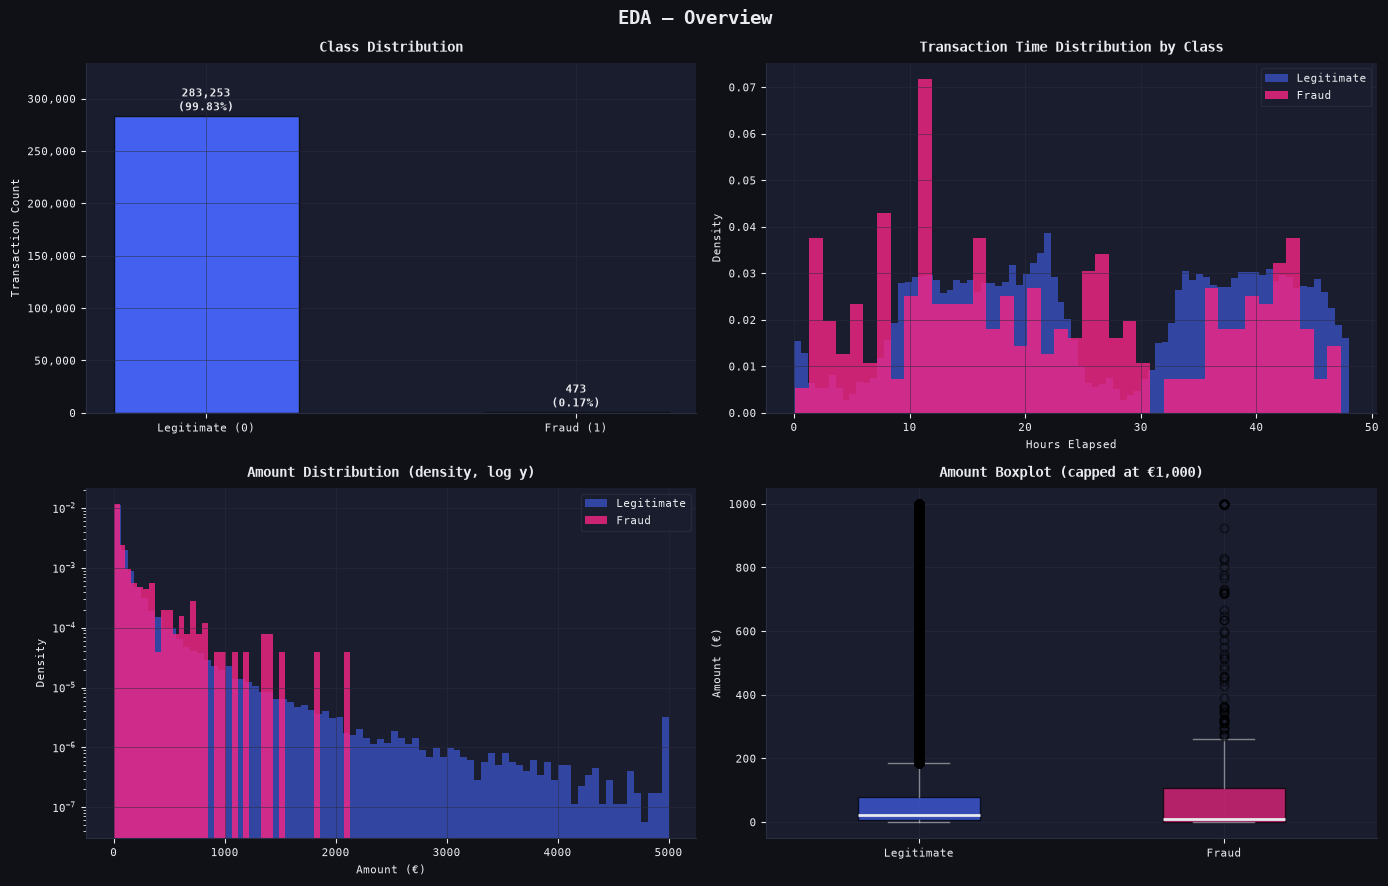

In [4]:
# EDA Overview (2×2)
fig1, axes = plt.subplots(2, 2, figsize=(14, 9))
fig1.suptitle("EDA — Overview", color=FG, fontsize=14, fontweight="bold", y=0.98)
plt.subplots_adjust(hspace=0.38, wspace=0.3)

# [0,0] Class Imbalance Bar
ax = axes[0, 0]
counts = [len(legit), len(fraud)]
bars   = ax.bar(["Legitimate (0)", "Fraud (1)"], counts,
                color=[C0, C1], edgecolor=BG, width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f"{cnt:,}\n({cnt / len(df) * 100:.2f}%)",
            ha="center", va="bottom", color=FG, fontsize=8, fontweight="bold")
ax.set_ylim(0, max(counts) * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
style(ax, "Class Distribution", "", "Transaction Count")

# [0,1] Time Distribution by Class
ax = axes[0, 1]
ax.hist(legit["Time"] / 3600, bins=80, color=C0, alpha=0.6,
        label="Legitimate", density=True)
ax.hist(fraud["Time"] / 3600, bins=40, color=C1, alpha=0.8,
        label="Fraud",      density=True)
style(ax, "Transaction Time Distribution by Class", "Hours Elapsed", "Density")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

# [1,0] Amount Distribution (log y)
ax = axes[1, 0]
ax.hist(legit["Amount"].clip(upper=5000), bins=80, color=C0, alpha=0.6,
        label="Legitimate", density=True)
ax.hist(fraud["Amount"].clip(upper=5000), bins=40, color=C1, alpha=0.8,
        label="Fraud",      density=True)
ax.set_yscale("log")
style(ax, "Amount Distribution (density, log y)", "Amount (€)", "Density")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

# [1,1] Amount Boxplot
ax = axes[1, 1]
data_box = [legit["Amount"].clip(upper=1000).values,
            fraud["Amount"].clip(upper=1000).values]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.4,
                medianprops=dict(color=FG, linewidth=2))
for patch, color in zip(bp["boxes"], [C0, C1]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color(FG)
        item.set_alpha(0.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Legitimate", "Fraud"], color=FG)
style(ax, "Amount Boxplot (capped at €1,000)", "", "Amount (€)")

plt.tight_layout()
plt.show()

## EDA — Overview: Findings

### Class Distribution

The dataset contains 283,253 legitimate transactions and 473 fraud cases after duplicate removal; a 599:1 imbalance. This is slightly more severe than the 577:1 ratio documented in the original dataset, confirming that duplicate removal disproportionately affected the fraud class. The fraud rate drift check in the preprocessing cell verified this shift was within acceptable tolerance.

**Implication:** accuracy is confirmed as a meaningless metric. A classifier predicting every transaction as legitimate achieves 99.83% accuracy while catching zero fraud.

---

### Transaction Time Distribution by Class (H3)
**Hypothesis H3 partially confirmed, with nuance.**

Legitimate transactions follow a clear bimodal pattern across the 48-hour window. Two distinct activity peaks consistent with two calendar days of normal business hours, with a low-activity trough around hours 28–32 (overnight).

Fraud transactions show a markedly different pattern; elevated density during the overnight trough (hours 8–12 and around hour 11 in particular) where legitimate activity is at its lowest. This is consistent with the known fraud behaviour of targeting low-volume windows where anomalous transactions are less likely to trigger velocity-based alerts.

However, fraud also appears throughout all hours with no clean temporal separation. `Time` carries a weak discriminative signal but not a strong one. Retaining it as a raw feature after Z-score normalisation is unlikely to add substantial predictive power to a linear model. Dropping it in favour of focusing on PCA components and Amount_log is justified by this finding. 

---

### Amount Distribution — density, log y scale (H1, H4)
**Hypotheses H1 and H4 confirmed.**

Both classes are heavily concentrated near zero, but the distributions diverge meaningfully in the mid-range. Fraud transactions show elevated density between approximately €0–€500 with several isolated spikes extending to €2,000+, consistent with targeted high-value fraudulent charges.

The log y-scale reveals that legitimate transactions have a long but thin tail extending to €5,000, while fraud drops off more sharply beyond €2,000. The distributions overlap substantially in the low-amount region — Amount alone is not a clean separator. Fraud transactions are not distinguishable from legitimate ones by amount alone, as fraudsters blend in. Amount is right-skewed and this motivates the log1p transformation. 

Severe right skew is visually confirmed for both classes, directly motivating the `log1p(Amount)` transformation applied in preprocessing.

---

### Amount Boxplot — capped at €1,000 (H4)
**Hypothesis H4 confirmed.**

Both classes show median amounts near zero with extensive outlier structure above €200. Legitimate transactions have a compressed IQR (most activity clustered below €50) with extreme outliers reaching the €1,000 cap and beyond. Fraud transactions show a slightly wider IQR and a higher median, consistent with fraudsters targeting mid-range amounts that are large enough to be profitable but not large enough to trigger automatic holds.

The outlier density in the legitimate class is substantially higher in absolute terms; a consequence of the class imbalance rather than a genuine distributional difference.

---

### Key Preprocessing Decisions Confirmed by This Plot

| Feature | Decision | Justification from plot |
|---|---|---|
| `Amount` | Replace with `log1p(Amount)` | Severe right skew confirmed visually |
| `Time` | Drop | Weak discriminative signal; no clean class separation |
| `V1–V28` | Retain, Z-score normalise | Not shown here — evaluated in PCA distribution plots |

### Univariate Distributions

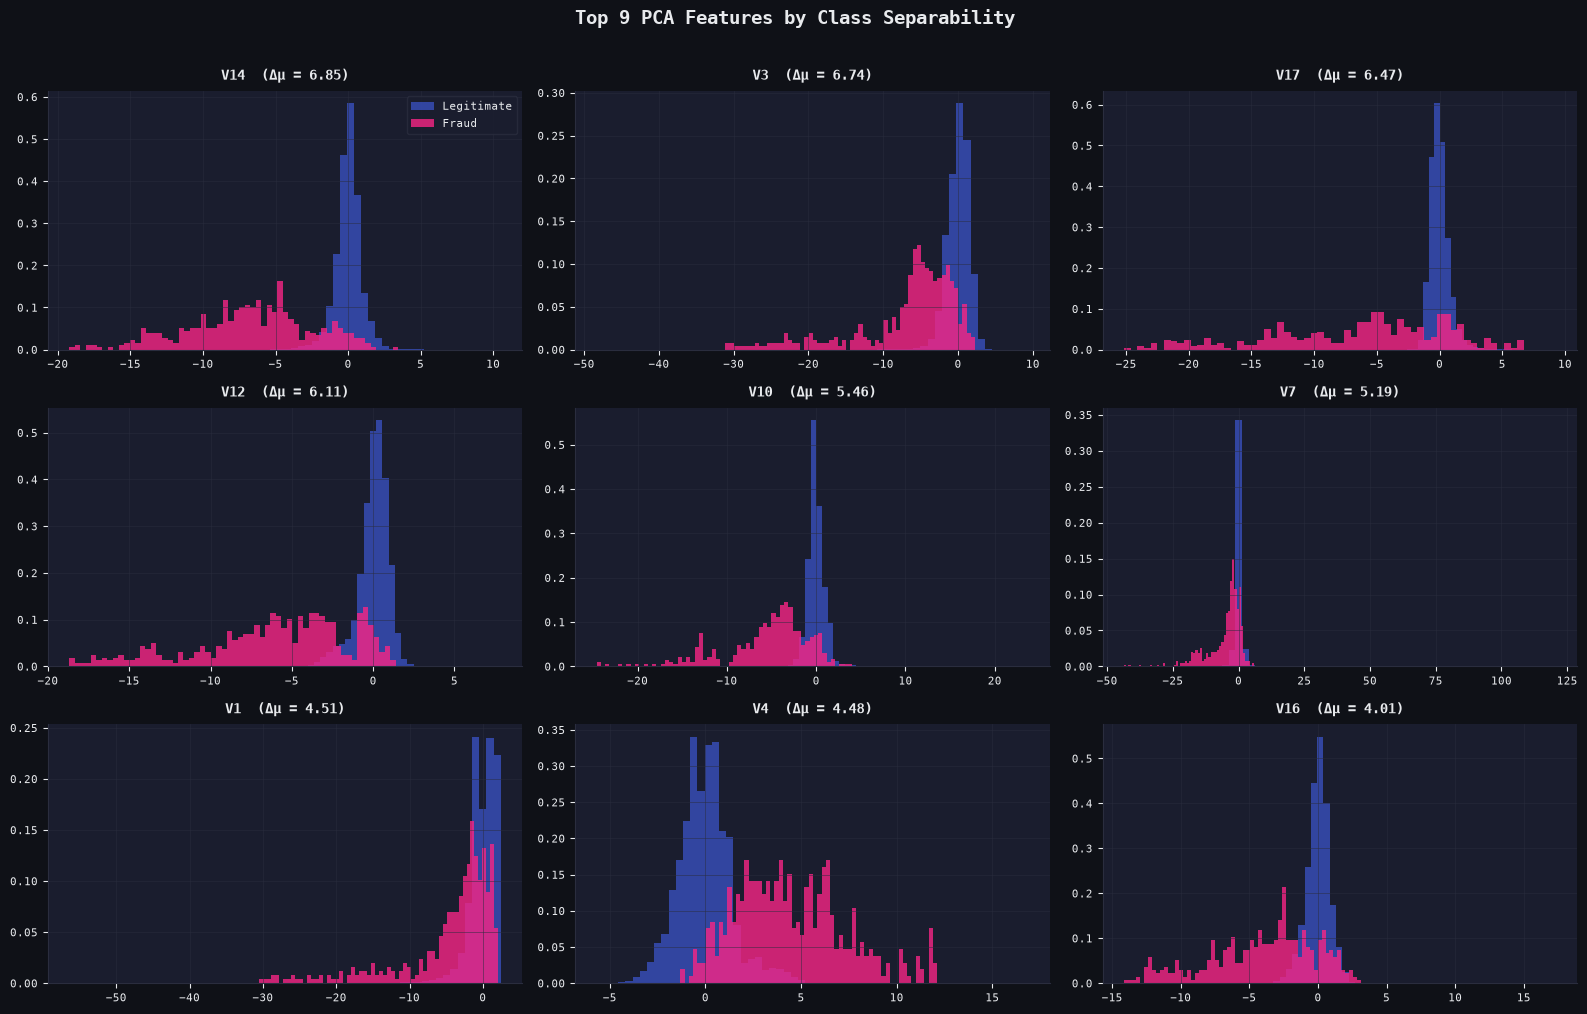

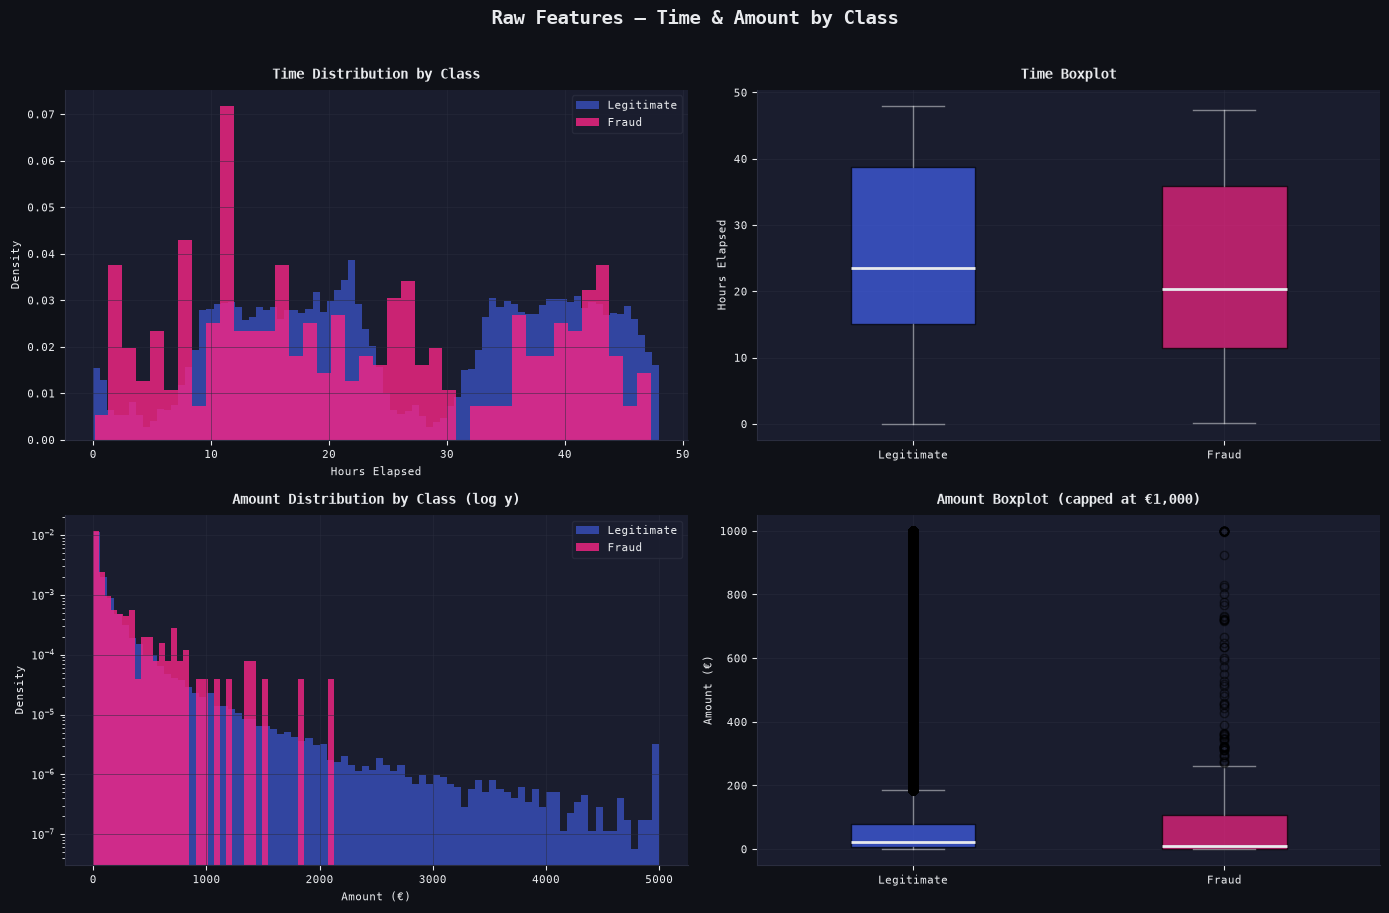

In [5]:
# Plot 1: Top Discriminative PCA Features
# Rank PCA features by absolute mean delta between classes, take top 9
pca_deltas   = (means_fraud[pca_cols] - means_legit[pca_cols]).abs().sort_values(ascending=False)
top_features = pca_deltas.index[:9].tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle("Top 9 PCA Features by Class Separability",
             color=FG, fontsize=14, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    ax.hist(legit[col], bins=60, color=C0, alpha=0.6, density=True, label="Legitimate")
    ax.hist(fraud[col], bins=60, color=C1, alpha=0.8, density=True, label="Fraud")
    delta = pca_deltas[col]
    style(ax, title=f"{col}  (Δμ = {delta:.2f})")

axes[0].legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.show()

# Plot 2: Time and Amount by Class
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Raw Features — Time & Amount by Class",
             color=FG, fontsize=14, fontweight="bold", y=1.01)

# [0,0] Time histogram
ax = axes[0, 0]
ax.hist(legit["Time"] / 3600, bins=80, color=C0, alpha=0.6,
        density=True, label="Legitimate")
ax.hist(fraud["Time"] / 3600, bins=40, color=C1, alpha=0.8,
        density=True, label="Fraud")
style(ax, "Time Distribution by Class", "Hours Elapsed", "Density")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

# [0,1] Time boxplot
ax = axes[0, 1]
bp = ax.boxplot(
    [legit["Time"].values / 3600, fraud["Time"].values / 3600],
    patch_artist=True, widths=0.4,
    medianprops=dict(color=FG, linewidth=2)
)
for patch, color in zip(bp["boxes"], [C0, C1]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color(FG)
        item.set_alpha(0.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Legitimate", "Fraud"], color=FG)
style(ax, "Time Boxplot", "", "Hours Elapsed")

# [1,0] Amount histogram (log y)
ax = axes[1, 0]
ax.hist(legit["Amount"].clip(upper=5000), bins=80, color=C0, alpha=0.6,
        density=True, label="Legitimate")
ax.hist(fraud["Amount"].clip(upper=5000), bins=40, color=C1, alpha=0.8,
        density=True, label="Fraud")
ax.set_yscale("log")
style(ax, "Amount Distribution by Class (log y)", "Amount (€)", "Density")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

# [1,1] Amount boxplot
ax = axes[1, 1]
bp = ax.boxplot(
    [legit["Amount"].clip(upper=1000).values,
     fraud["Amount"].clip(upper=1000).values],
    patch_artist=True, widths=0.4,
    medianprops=dict(color=FG, linewidth=2)
)
for patch, color in zip(bp["boxes"], [C0, C1]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ["whiskers", "caps", "fliers"]:
    for item in bp[element]:
        item.set_color(FG)
        item.set_alpha(0.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Legitimate", "Fraud"], color=FG)
style(ax, "Amount Boxplot (capped at €1,000)", "", "Amount (€)")

plt.tight_layout()
plt.show()

# Univariate Distribution Notes

## Overview

This section performs **univariate distribution analysis** on the credit card fraud dataset, visualising how individual features differ between the two classes: **Legitimate** and **Fraud**. 

Two plots are produced:

1. Top 9 PCA features ranked by class separability
2. Raw features — `Time` and `Amount` shown as histograms and boxplots

---

## Plot 1: Top 9 PCA Features by Class Separability

### Goal
Identify which PCA-transformed features carry the most discriminative signal for distinguishing fraud from legitimate transactions.

### Method: Mean Delta Ranking (Δμ)

```python
pca_deltas = (means_fraud[pca_cols] - means_legit[pca_cols]).abs().sort_values(ascending=False)
top_features = pca_deltas.index[:9].tolist()
```

- For each PCA feature, compute the **absolute difference in class means**: `|μ_fraud − μ_legit|`
- Sort descending and take the **top 9** — these are the features where the two classes are furthest apart on average
- This is a simple, fast proxy for univariate discriminability (analogous to univariate ANOVA or t-test effect size)

> **Note:** Δμ only captures location shift, not distributional overlap. Two features with equal Δμ may differ greatly in separability if one has higher variance.

### Visualisation

```python
ax.hist(legit[col], bins=60, color=C0, alpha=0.6, density=True, label="Legitimate")
ax.hist(fraud[col], bins=60, color=C1, alpha=0.8, density=True, label="Fraud")
```

- **Overlapping histograms** with `density=True` allow direct shape comparison regardless of class imbalance
- Each subplot title shows the feature name and its Δμ value, e.g. `V4  (Δμ = 3.21)`
- `alpha` values are intentionally asymmetric: fraud (minority class) is rendered slightly more opaque so it remains visible under the dominant legitimate distribution

---

## Plot 2: Raw Features — Time & Amount by Class

### Goal
Examine the two non-PCA features (`Time`, `Amount`) that represent real-world transaction metadata.

---

### 2a — Time Distribution `axes[0, 0]`

```python
ax.hist(legit["Time"] / 3600, bins=80, ...)
ax.hist(fraud["Time"] / 3600, bins=40, ...)
```

- `Time` is converted from **seconds → hours** (`/ 3600`) for readability
- Legitimate transactions use more bins (80) since the class is much larger; fraud uses 40 to avoid over-sparse bars
- The histogram reveals **temporal patterns** — e.g., whether fraud clusters at certain hours of the day

---

### 2b — Time Boxplot `axes[0, 1]`

```python
bp = ax.boxplot([legit["Time"].values / 3600, fraud["Time"].values / 3600],
                patch_artist=True, ...)
```

- **`patch_artist=True`** enables box fill colouring (otherwise boxes are outline-only)
- Complementary to the histogram: the boxplot surfaces **median, IQR, and outlier spread** without binning artefacts
- Whiskers/caps/fliers are styled to match the dark theme via `set_color(FG)`

---

### 2c — Amount Distribution `axes[1, 0]`

```python
ax.hist(legit["Amount"].clip(upper=5000), bins=80, ...)
ax.set_yscale("log")
```

- **`.clip(upper=5000)`** suppresses extreme outliers that would compress the bulk of the distribution into illegibility
- **Log y-scale** is critical here: `Amount` is heavily right-skewed (most transactions are small), so a linear scale would make the fraud distribution nearly invisible
- Log scale allows both low-frequency large amounts and high-frequency small amounts to be visible simultaneously

---

### 2d — Amount Boxplot `axes[1, 1]`

```python
[legit["Amount"].clip(upper=1000).values,
 fraud["Amount"].clip(upper=1000).values]
```

- Cap reduced to **€1,000** (vs €5,000 in the histogram) because boxplots are more sensitive to outliers compressing the IQR display
- Reveals whether fraud transactions tend to cluster at specific amount ranges (e.g., small test charges or large single purchases)

---

## Design Conventions Used Throughout

| Variable | Role |
|----------|------|
| `C0` | Colour for Legitimate class |
| `C1` | Colour for Fraud class |
| `FG` | Foreground / text colour (dark theme) |
| `PANEL` | Legend background colour |
| `GRID` | Grid / border colour |
| `style()` | Helper function applying consistent axis styling |

- `density=True` normalises all histograms to **probability density**, essential when classes are imbalanced (fraud is typically ~0.17% of transactions in this dataset)
- `plt.tight_layout()` prevents subplot label overlap before rendering

---

## Key Takeaways

- **PCA features** (V1–V28) are the primary fraud signal carriers; the top features by Δμ are the most useful candidates for a classifier
- **Time** shows limited marginal discrimination but may capture periodicity
- **Amount** shows moderate separation — fraud transactions often have a distinct amount profile compared to legitimate ones
- The combination of histograms (shape/density) and boxplots (summary statistics) gives a complete univariate picture of each feature

## Fraud Amount / Legitimate Amount Deep Dive

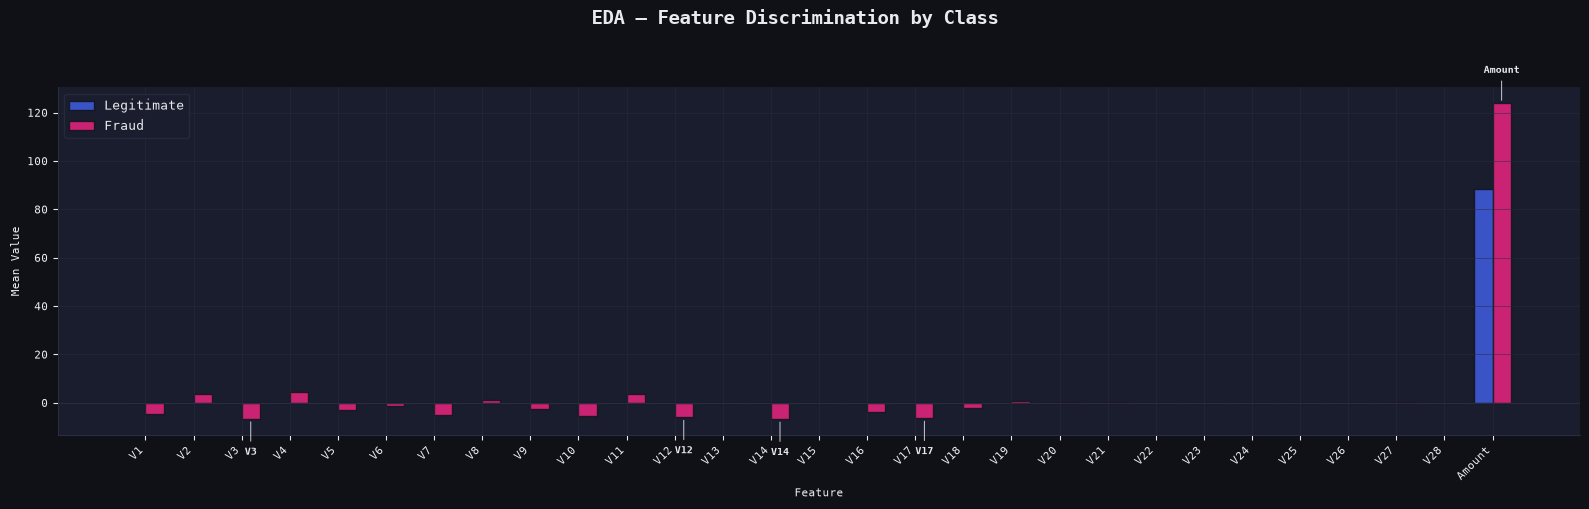

Top 5 most discriminatory features (by mean divergence):
    Amount  Δmean = +35.4583
       V14  Δmean = -6.8476
        V3  Δmean = -6.7425
       V17  Δmean = -6.4742
       V12  Δmean = -6.1127


In [6]:
# EDA: Class-Conditional Feature Means (V1–V28 + Amount)
fig3, ax = plt.subplots(figsize=(16, 5))
fig3.suptitle("EDA — Feature Discrimination by Class",
              color=FG, fontsize=14, fontweight="bold", y=1.01)

cols  = pca_cols + ["Amount"]
x     = np.arange(len(cols))
width = 0.38

ax.bar(x - width / 2, means_legit[cols], width=width,
       color=C0, alpha=0.8, edgecolor=BG, label="Legitimate")
ax.bar(x + width / 2, means_fraud[cols], width=width,
       color=C1, alpha=0.8, edgecolor=BG, label="Fraud")

# Annotate top 5 most discriminatory features
diffs = np.abs(means_fraud[cols].values - means_legit[cols].values)
top5  = np.argsort(diffs)[-5:]
y_range = ax.get_ylim()[1] - ax.get_ylim()[0]

for i in top5:
    yval   = means_fraud[cols[i]]
    sign   = 1 if yval >= 0 else -1
    offset = sign * y_range * 0.08          # relative offset — scale-safe
    ax.annotate(
        cols[i],
        xy=(x[i] + width / 2, yval),
        xytext=(x[i] + width / 2, yval + offset),
        ha="center", va="bottom" if sign > 0 else "top",
        color=FG, fontsize=7.5, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=FG, lw=0.6)
    )

ax.axhline(0, color=GRID, lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)
style(ax, "", "Feature", "Mean Value")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=9)
plt.tight_layout()
plt.show()

# Top 5 discriminatory features (console)
top5_names = [cols[i] for i in np.argsort(diffs)[-5:][::-1]]
print("Top 5 most discriminatory features (by mean divergence):")
for name in top5_names:
    d = means_fraud[name] - means_legit[name]
    print(f"  {name:>8s}  Δmean = {d:+.4f}")

## EDA — Feature Discrimination by Class: Findings

### What the Plot Shows
Class-conditional mean values for all 29 features (V1–V28 + Amount) plotted side by side. Blue = legitimate mean, pink = fraud mean. A large visible gap between bars indicates strong discriminative signal. Features where bars are nearly identical contribute little to a linear classifier.

Notably, **legitimate bars for V1–V28 sit essentially at zero across the board** — expected behaviour, since PCA components are zero-mean by construction on the training population. It is the fraud class (minority) whose means deviate, making the fraud bar the active signal carrier in this plot.

---

### Amount Dominates in Raw Scale (H1 confirmed)
`Amount` produces the largest mean divergence by a wide margin — Δmean = +35.46. Crucially, **both classes have meaningfully high Amount means** (~€85 for legitimate, ~€120 for fraud); this is not a case of one class sitting near zero. The divergence reflects fraud transactions averaging €35 more, not fraud being an outlier against a near-zero baseline.

However, Amount's visual dominance is an artefact of scale: Amount is in euros while V1–V28 are PCA components with compressed variance. This is precisely why Z-score normalisation is applied before training. Without it, Amount would dominate gradient computation for the same reason it dominates this plot visually. After `log1p` transformation and Z-score normalisation, Amount's relative influence will compress substantially and the PCA components will contribute on equal footing.

---

### Top Discriminating PCA Components (H2 confirmed)
The console output reveals the true signal hierarchy after controlling for scale:

| Rank | Feature | Δmean | Direction |
|---|---|---|---|
| 1 | Amount | +35.46 | Fraud transactions average higher raw amounts |
| 2 | V14 | −6.85 | Fraud mean is negative; legitimate near zero |
| 3 | V3 | −6.74 | Fraud mean is negative; legitimate near zero |
| 4 | V17 | −6.47 | Fraud mean is negative; legitimate near zero |
| 5 | V12 | −6.11 | Fraud mean is negative; legitimate near zero |

Four of the five top discriminators show **negative absolute divergence** — fraud means fall below zero for V3, V12, V14, and V17, while legitimate means remain near zero. This is consistent with the known structure of this dataset in the literature, where V14 and V17 in particular are consistently identified as strong fraud indicators.

**V4 is the notable exception**: it is the only PCA component where the fraud mean diverges in the *positive* direction, visible in the plot as the fraud bar rising above zero while legitimate remains flat. This positive-direction outlier is worth monitoring in feature weight analysis.

**Implication for the model:** the four negative-diverging components are expected to carry the largest negative weights in the learned weight vector, and V4 a positive weight. If the trained weights align with these mean divergences, it validates that gradient descent found the correct linear separation direction.

---

### Most Features Show Near-Zero Divergence (H6 confirmed)
The majority of V1–V28 bars are visually indistinguishable — both classes have near-identical means for most PCA components, with fraud means only marginally displaced from zero. This confirms H6: discriminative power is concentrated in a small subset of components. The remaining components add noise tolerance but contribute minimal individual signal.

**Implication:** a logistic regression with 29 features is likely over-parameterised relative to the true signal — most weights will land near zero. This is benign given Z-score normalisation and early stopping, but it does suggest that L2 regularisation (weight decay) could improve generalisation by suppressing those near-zero weight components. This remains a hypothesis to test via ablation or regularisation strength experiments.

---

### Key Takeaway
The linear classifier has genuine signal from at least four negatively-diverging PCA components (V3, V12, V14, V17), one positively-diverging component (V4), and Amount_log. The open question is whether these discriminating directions in a 29-dimensional space are sufficient to separate the fraud cluster from the legitimate mass — or whether the fraud region is nonlinearly embedded in a way a hyperplane cannot capture. The performance ceiling analysis at the end of the notebook will answer this directly.

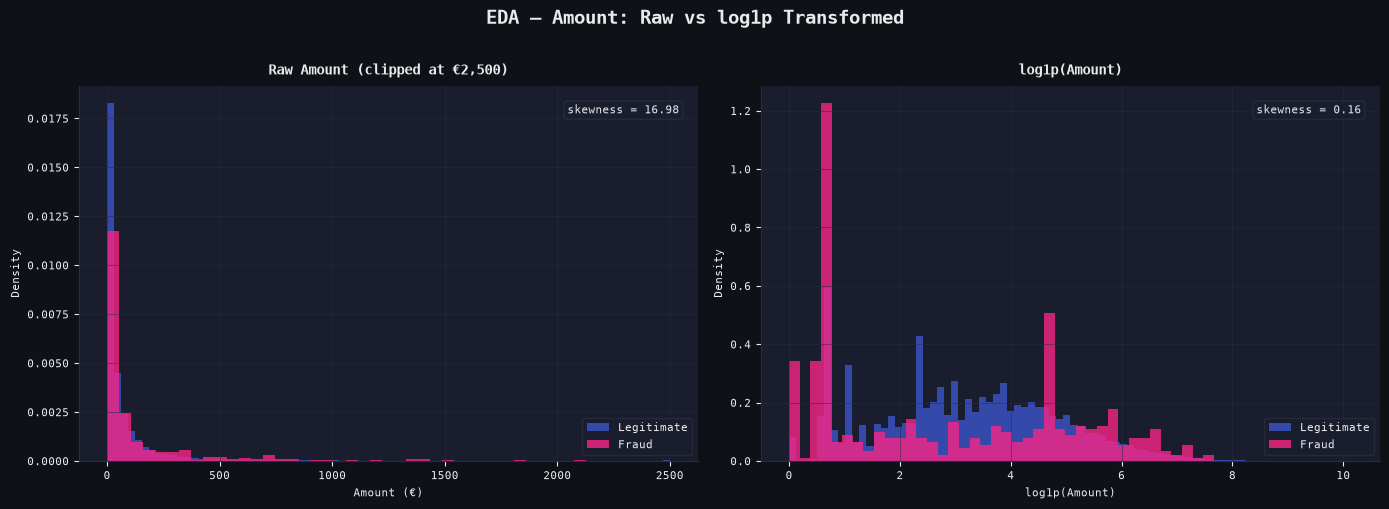

  Amount skewness — raw    : 16.9788
  Amount skewness — log1p  : 0.1614
  Skewness reduction       : 99.0%

  PREPROCESSING DECISION:
  log1p(Amount) will be applied before Z-score normalisation.
  This decision is now binding on the preprocessing pipeline.

  AMOUNT DESCRIPTIVE STATISTICS BY CLASS
           Fraud   Legitimate
count   473.0000  283253.0000
mean    123.8719      88.4136
std     260.2110     250.3790
min       0.0000       0.0000
25%       1.0000       5.6700
50%       9.8200      22.0000
75%     105.8900      77.4600
max    2125.8700   25691.1600


In [7]:
# EDA: Amount — Raw vs log1p Transformation
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle("EDA — Amount: Raw vs log1p Transformed",
              color=FG, fontsize=14, fontweight="bold", y=1.01)

# [0] Raw Amount
ax = axes[0]
ax.hist(legit["Amount"].clip(upper=2500), bins=80,
        color=C0, alpha=0.65, density=True, label="Legitimate")
ax.hist(fraud["Amount"].clip(upper=2500), bins=40,
        color=C1, alpha=0.80, density=True, label="Fraud")
skew_raw = df["Amount"].skew()
ax.text(0.97, 0.95, f"skewness = {skew_raw:.2f}",
        transform=ax.transAxes, ha="right", va="top", color=FG, fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
                  edgecolor=GRID, alpha=0.8))
style(ax, "Raw Amount (clipped at €2,500)", "Amount (€)", "Density")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

# [1] log1p(Amount)
ax = axes[1]
ax.hist(np.log1p(legit["Amount"]), bins=80,
        color=C0, alpha=0.65, density=True, label="Legitimate")
ax.hist(np.log1p(fraud["Amount"]), bins=40,
        color=C1, alpha=0.80, density=True, label="Fraud")
skew_log = np.log1p(df["Amount"]).skew()
ax.text(0.97, 0.95, f"skewness = {skew_log:.2f}",
        transform=ax.transAxes, ha="right", va="top", color=FG, fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
                  edgecolor=GRID, alpha=0.8))
style(ax, "log1p(Amount)", "log1p(Amount)", "Density")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.show()

# Skewness report
print(f"  Amount skewness — raw    : {skew_raw:.4f}")
print(f"  Amount skewness — log1p  : {skew_log:.4f}")
print(f"  Skewness reduction       : {((skew_raw - skew_log) / skew_raw * 100):.1f}%")
print()
print("  PREPROCESSING DECISION:")
print("  log1p(Amount) will be applied before Z-score normalisation.")
print("  This decision is now binding on the preprocessing pipeline.")

# Amount descriptive statistics by class
print()
print("=" * 48)
print("  AMOUNT DESCRIPTIVE STATISTICS BY CLASS")
print("=" * 48)
stats = (
    fraud["Amount"].describe().to_frame("Fraud")
    .join(legit["Amount"].describe().to_frame("Legitimate"))
)
print(stats.round(4).to_string())
print("=" * 48)

**Missing from the log1p panel observation:**

- The fraud distribution in the right panel is visibly **spikier and more erratic** than legitimate — it has multiple sharp isolated peaks rather than a smooth spread. This suggests fraud amounts cluster at specific discrete values (round numbers, fixed test amounts), while legitimate spending is more continuously distributed. That's a meaningful structural difference the notes don't mention.

- The legitimate distribution in the log1p panel has a **near-zero spike** too (visible at log1p ≈ 0–0.5), not just fraud. The notes currently imply only fraud spikes near zero, which slightly misrepresents the right panel.

**One imprecision in the raw panel:**

- "The fraud class shows several isolated spikes in the €1,000–€2,000 range" — looking at the plot, the fraud bars in that range are very small and barely distinguishable from the baseline. This reads as stronger evidence of high-value fraud clustering than the plot actually supports. Worth softening to "a thin, irregular tail" rather than "isolated spikes."

**One minor addition to the statistics section:**

- The **75th percentile inversion** (fraud P75 = €105.89 vs legitimate P75 = €77.46) is noted in the table but not interpreted. This is actually the sharpest summary of the bimodal fraud structure — the bottom 75% of fraud is mostly small card-testing amounts, but the top 25% pulls the P75 above legitimate.

Everything else; the skewness interpretation, the sigmoid dominance argument, the card-testing hypothesis, the bimodality point, and the preprocessing decision block is accurate, well-reasoned, and ready to go once those four points are addressed. 

Here's the corrected version:

---

## EDA — Amount: Raw vs log1p Transformed: Findings

### Skewness Reduction (H4 confirmed)
Raw `Amount` has a skewness of 16.98 which is severely right-skewed. The `log1p` transformation reduces this to 0.16, a 99% reduction, producing a near-symmetric distribution. This is one of the cleanest transformation justifications possible. The number speaks for itself.

**Why this matters for logistic regression specifically:** the sigmoid function maps a linear combination of features to a probability. If `Amount` has a long right tail in raw form, a single large transaction can dominate the linear combination and produce extreme predicted probabilities regardless of the other 28 features. After `log1p`, large amounts are compressed into a comparable range with the PCA components, allowing the model to weigh all features proportionally.

---

### Raw Distribution — Left Panel
Both classes spike sharply near zero and decay rapidly. The legitimate class has a smoother, thicker tail extending to €2,500+. The fraud class has a thin, irregular tail in the higher ranges rather than pronounced clustering — the bulk of fraud is concentrated near zero, making Amount alone a weak separator in raw form.

---

### log1p Distribution — Right Panel
After transformation the picture changes meaningfully:

- **Both** classes show a spike near log1p ≈ 0–0.5 (amounts near €0–€1), so near-zero concentration is not unique to fraud
- Legitimate transactions then spread into a broad, relatively flat distribution from log1p ≈ 1 to 6 (roughly €1–€400), with a **smooth and continuous shape**
- Fraud transactions are **visibly spikier and more erratic** — multiple sharp isolated peaks rather than a smooth spread, suggesting fraud amounts cluster at specific discrete values (round numbers, fixed card-testing charges) rather than varying continuously like legitimate spending
- A secondary fraud peak near log1p ≈ 6 (~€400) is visible and absent in the legitimate distribution at that density level

The two distributions have structurally different shapes after transformation — continuous vs. discretely spiked — a distinction that was completely obscured in the raw scale. This confirms that `log1p(Amount)` is a more informative feature than raw `Amount` for a linear classifier.

---

### Descriptive Statistics by Class

| Statistic | Fraud | Legitimate |
|---|---|---|
| Count | 473 | 283,253 |
| Mean | €123.87 | €88.41 |
| Median (50%) | €9.82 | €22.00 |
| 75th percentile | €105.89 | €77.46 |
| Max | €2,125.87 | €25,691.16 |

Four findings stand out:

**Fraud median is less than half the legitimate median (€9.82 vs €22.00).** The majority of fraud transactions involve very small amounts — consistent with card-testing behaviour, where fraudsters make small test charges to verify a stolen card is active before attempting larger withdrawals.

**The 75th percentile inverts (fraud P75 €105.89 > legitimate P75 €77.46).** While the bottom 75% of fraud skews toward small card-testing amounts, the top 25% pulls the fraud P75 above the legitimate P75. This is the sharpest statistical summary of the bimodal fraud structure — small test charges and large fraudulent purchases coexist within the same class.

**Fraud mean (€123.87) substantially exceeds fraud median (€9.82).** This large mean-median gap within the fraud class confirms that the distribution is bimodal. A linear classifier will struggle with this since it must draw a single boundary across a class that occupies two separate regions of the Amount axis.

**Legitimate max (€25,691) dwarfs fraud max (€2,125).** The most extreme transactions in the dataset are legitimate. This partly explains why Amount alone is a weak discriminator — the high-value tail belongs to the legitimate class, not the fraud class.

---

### Preprocessing Decision — Confirmed and Binding

```
log1p(Amount) applied before Z-score normalisation.
Raw Amount and Time dropped from the feature matrix.
This is now binding on all downstream pipeline steps.
```

## PCA Feature Distributions (V1–V28)

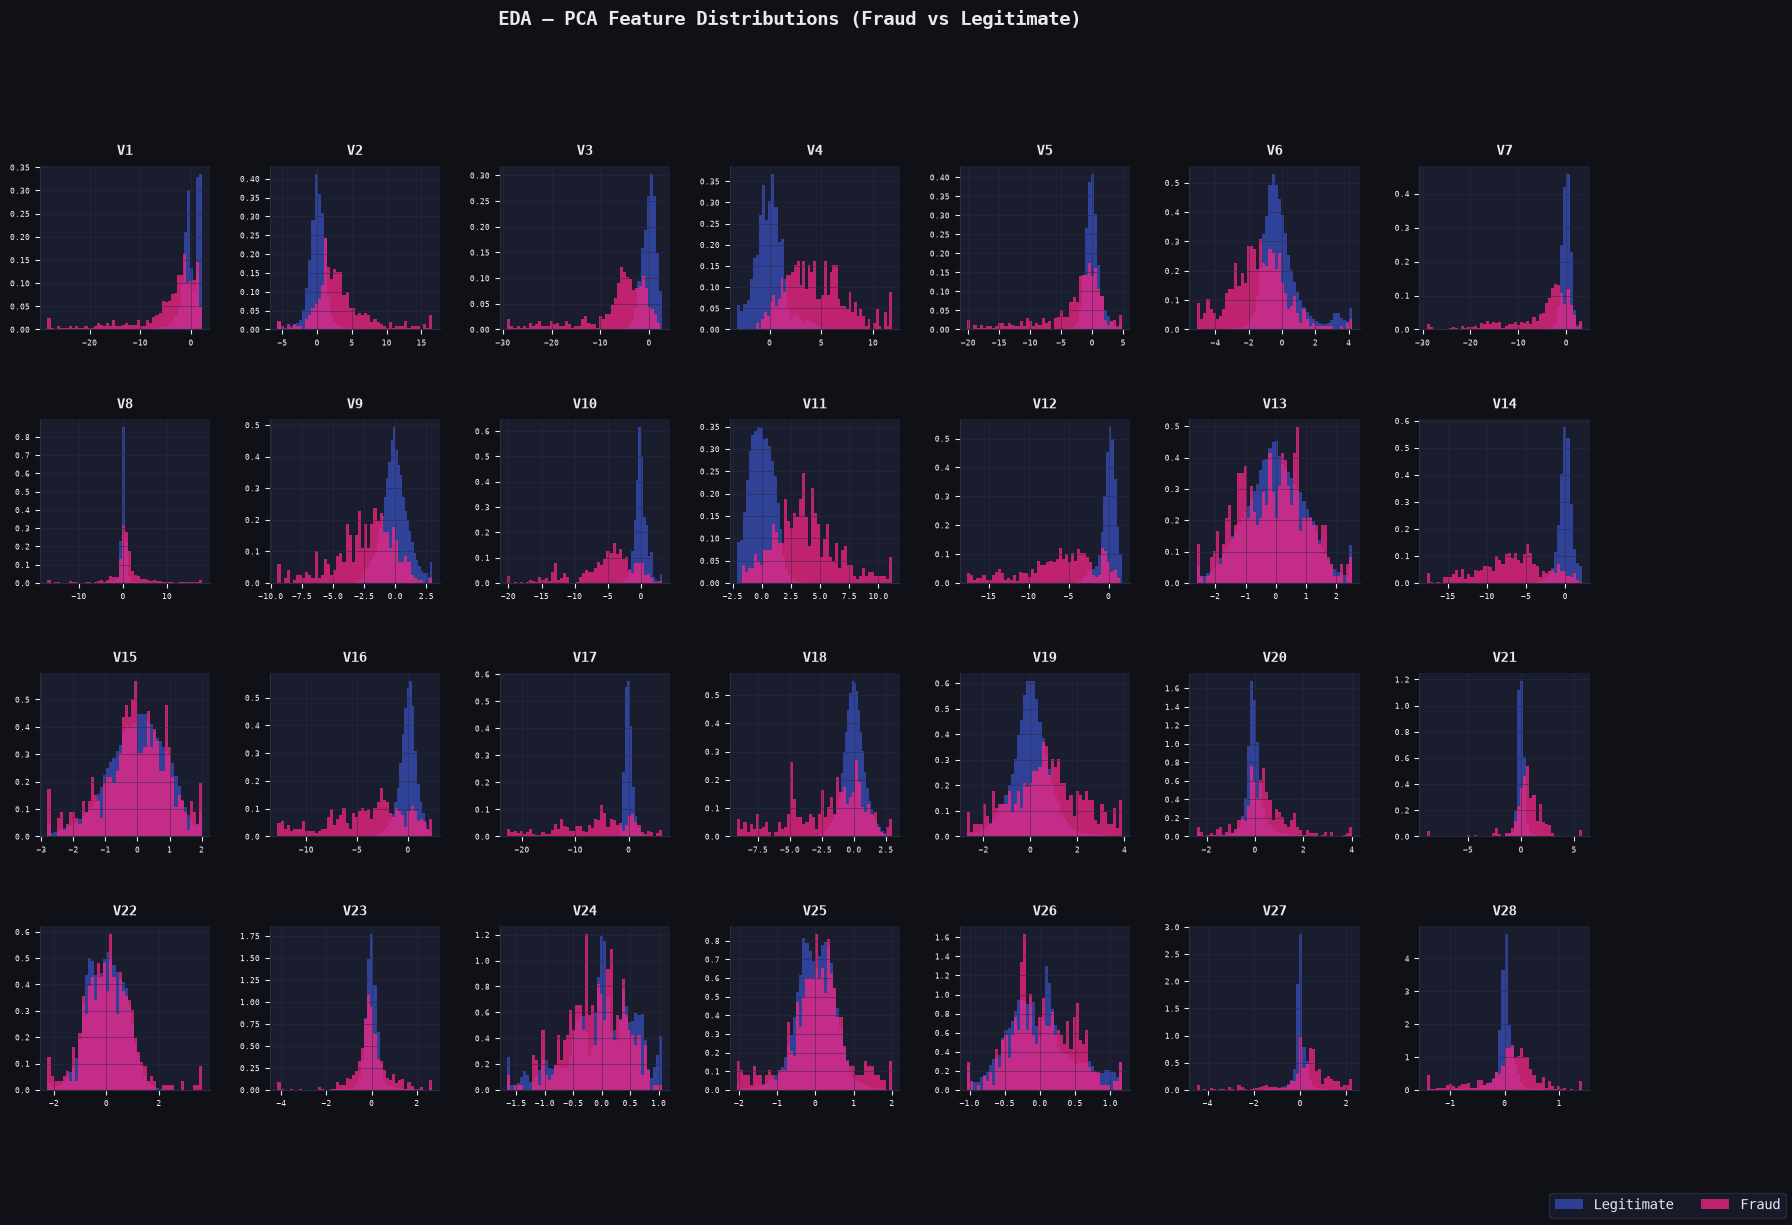

In [8]:
# EDA: All 28 PCA Feature Distributions by Class
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
fig.suptitle("EDA — PCA Feature Distributions (Fraud vs Legitimate)",
             color=FG, fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(hspace=0.55, wspace=0.35)

axes_flat = axes.flatten()

for i, col in enumerate(pca_cols):
    ax = axes_flat[i]

    # Clip bounds computed per class to avoid majority-class dominance
    lo = min(legit[col].quantile(0.01), fraud[col].quantile(0.01))
    hi = max(legit[col].quantile(0.99), fraud[col].quantile(0.99))

    ax.hist(legit[col].clip(lo, hi), bins=50, color=C0, alpha=0.55,
            density=True, label="Legitimate")
    ax.hist(fraud[col].clip(lo, hi), bins=50, color=C1, alpha=0.75,
            density=True, label="Fraud")
    style(ax, title=col)
    ax.tick_params(labelsize=6)

# No empty slots — 4×7 = 28 = len(pca_cols), nothing to hide

fig.legend(["Legitimate", "Fraud"], loc="lower right", fontsize=10,
           ncol=2, facecolor=PANEL, edgecolor=GRID, labelcolor=FG)
plt.show()

## EDA — PCA Feature Distributions by Class: Findings

### Reading the Grid

Each panel shows the density distribution of one PCA component stratified by class. **Blue = legitimate, pink = fraud.** Overlap indicates weak separation; a visible offset or shape difference indicates discriminative signal. Clip bounds are per-class quantile-based so the fraud distribution is not crushed by the majority class range.

Note that x-axis ranges vary dramatically across panels — V1 spans out to −20, while V28 stays within ±1. This is consistent with PCA ordering by variance explained: earlier components have larger absolute value ranges because they capture more of the original feature space variance.

---

### Strong Separability — Clear Distributional Shift
**V3, V7, V10, V12, V14, V16, V17**

These components show the most visually pronounced separation. The fraud distribution (pink) is shifted toward negative values relative to the legitimate distribution (blue), consistent with the negative Δmean values identified in the feature discrimination plot.

- **V14** is particularly striking — the fraud distribution is heavily concentrated in the negative tail while legitimate transactions cluster near zero.
- **V17** shows a similar pattern.

These are the components the model will lean on most heavily. Their large mean separation combined with relatively tight fraud distributions makes them the strongest linear discriminators in the feature set. Expect large negative weights on these features in the trained weight vector.

---

### V4 — Positive-Direction Discriminator

Shows the opposite direction — fraud distribution shifted toward positive values relative to legitimate. This is the clearest positive-direction discriminator in the PCA set, consistent with the feature discrimination plot showing V4 with a positive Δmean. The fraud distribution also appears **bimodal**, with two visible modes in the positive range.

---

### Moderate Separability — Partial
**V1, V2, V5, V6, V9, V11, V13, V19**

These components show visible but incomplete separation.

- **V11** is the most structurally distinct of this group — the fraud distribution is genuinely multimodal, spread across both positive and negative values, while the legitimate distribution is tightly clustered near zero. The irregular spread rather than a clean shift makes V11 harder for a linear boundary to exploit.
- **V13** shows fraud as a wide, flat distribution against a sharp legitimate peak — not strong separation, but clearly non-identical shapes.
- **V19** shows a mild rightward shift in the fraud distribution relative to legitimate.
- **V1, V2, V5, V6, V9** show overlapping distributions with different modes or heavier tails in one direction.

These components contribute signal but are not clean separators on their own.

---

### Weak Separability — Near-Complete Overlap
**V8, V15, V18, V20, V21, V22, V23, V24, V25, V26, V27, V28**

The later PCA components show distributions that are largely indistinguishable between classes in terms of location. However, several show shape differences worth noting:

| Component(s) | Observation |
|---|---|
| V8 | Legitimate has a sharp spike near zero; fraud is much flatter and wider — different variance structure even if means are similar |
| V20, V21 | Fraud has a noticeably longer right tail while legitimate clusters tightly near zero |
| V27, V28 | Legitimate is tighter and higher-peaked; fraud is flatter and more dispersed |

These differences in spread rather than location are harder for a logistic regression to exploit — a linear model responds to mean shift, not variance difference. These features will receive near-zero weights despite their visible shape differences.

This directly confirms **H6** — discriminative power is concentrated in the earlier, higher-variance components. This is expected: PCA orders components by variance explained, and fraud patterns, if linearly separable at all, are most likely encoded in the high-variance directions.

---

### Notable Structural Observations

- Fraud distributions are frequently irregular or multimodal. **V4 and V11** show clearly multimodal fraud distributions. Several others (**V24, V25**) show wide, irregular fraud spreads that may reflect distinct fraud subtypes — card testing vs. high-value theft vs. account takeover — occupying different regions of PCA space. A single linear boundary cannot separate all subtypes simultaneously from the legitimate cluster. This is early visual evidence for the performance ceiling finding later.
- Fraud distributions are generally wider than legitimate distributions. Across most components, the pink distribution has heavier tails and higher variance than the blue. The fraud region is not a compact cluster but a diffuse, irregular shape in PCA space. A hyperplane must accommodate this spread, which inevitably encloses legitimate transactions within it.

---

### Summary Table — Separability by Component

| Separability | Components |
|---|---|
| **Strong** | V3, V4, V7, V10, V12, V14, V16, V17 |
| **Moderate** | V1, V2, V5, V6, V9, V11, V13, V19 |
| **Weak** | V8, V15, V18, V20, V21, V22, V23, V24, V25, V26, V27, V28 |

> **H2 confirmed.** PCA separability is real but concentrated in approximately 8 of 28 components. The remaining 20 contribute noise tolerance at best.
>
> This supports the expectation that the trained weight vector will be effectively sparse — large weights on **V3, V4, V7, V10, V12, V14, V16, V17** and near-zero elsewhere.

## Discriminating Features (KDE)

Top 6 discriminating features (mean divergence, log1p Amount):
           V14  Δmean = -6.8476
            V3  Δmean = -6.7425
           V17  Δmean = -6.4742
           V12  Δmean = -6.1127
           V10  Δmean = -5.4609
            V7  Δmean = -5.1864


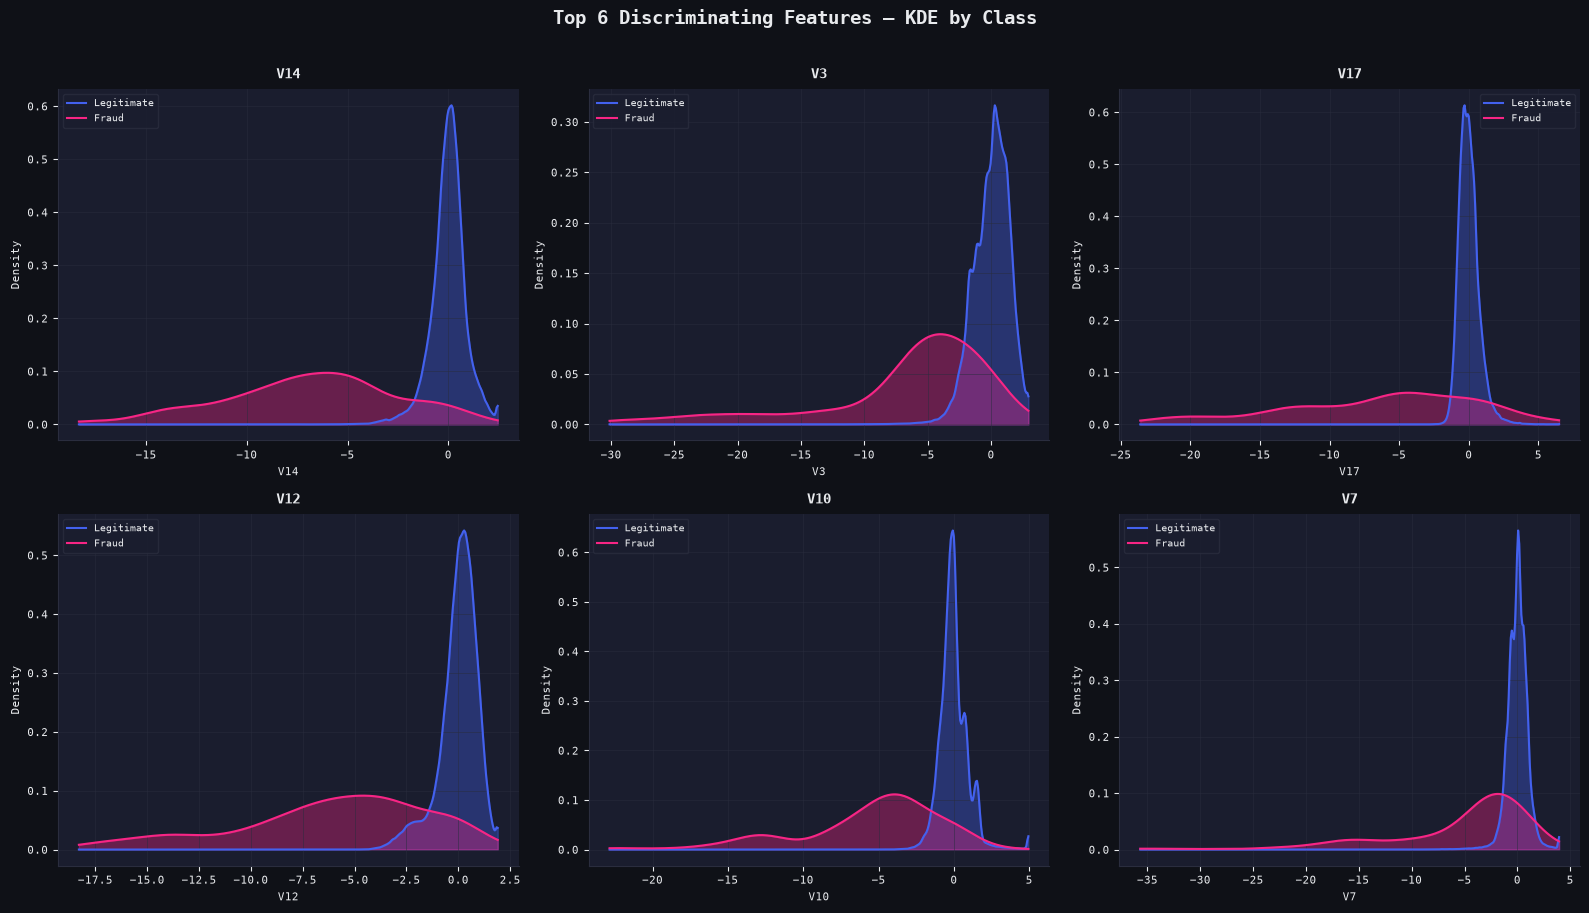

In [9]:
# EDA: Top 6 Discriminating Features — KDE by Class
# Build a local EDA-only view: swap raw Amount for log1p(Amount)
# Time is excluded here as it is not among the top discriminators
# its inclusion is evaluated separately in the Time distribution plot.

df_eda        = df.copy()
df_eda["Amount_log"] = np.log1p(df_eda["Amount"])
df_eda        = df_eda.drop(columns=["Amount", "Time"])

legit_eda     = df_eda[df_eda["Class"] == 0]
fraud_eda     = df_eda[df_eda["Class"] == 1]
feature_cols  = [c for c in df_eda.columns if c != "Class"]

means_legit_eda = legit_eda[feature_cols].mean()
means_fraud_eda = fraud_eda[feature_cols].mean()

top6 = (
    (means_fraud_eda - means_legit_eda)
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

print("Top 6 discriminating features (mean divergence, log1p Amount):")
for col in top6:
    delta = means_fraud_eda[col] - means_legit_eda[col]
    print(f"  {col:>12s}  Δmean = {delta:+.4f}")

# KDE plot
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Top 6 Discriminating Features — KDE by Class",
             color=FG, fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for ax, col in zip(axes.flatten(), top6):
    # Per-class quantile bounds to avoid majority-class dominance
    lo = min(legit_eda[col].quantile(0.005), fraud_eda[col].quantile(0.005))
    hi = max(legit_eda[col].quantile(0.995), fraud_eda[col].quantile(0.995))
    x_range = np.linspace(lo, hi, 400)

    for data, color, label in [
        (legit_eda[col], C0, "Legitimate"),
        (fraud_eda[col], C1, "Fraud"),
    ]:
        clipped = data.clip(lo, hi)
        density = gaussian_kde(clipped)(x_range)
        ax.fill_between(x_range, density, alpha=0.35, color=color)
        ax.plot(x_range, density, color=color, lw=1.5, label=label)

    style(ax, col, col, "Density")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=7)

plt.tight_layout()
plt.show()

## EDA — Top 6 Discriminating Features: KDE by Class: Findings

### What the Plot Shows
Kernel Density Estimate (KDE) curves for the six most discriminating PCA components (V14, V3, V17, V12, V10, V7), stratified by class. KDE is preferred over histograms here because it produces smooth continuous density estimates that make distributional shape, tail behaviour, and overlap regions easier to read — particularly important for the minority fraud class where histogram bins are sparse.

Blue = legitimate, pink = fraud. All six follow the same structural pattern: **a sharp, tall legitimate peak near zero and a broad, low fraud distribution shifted into the negative range.**

---

### The Shared Pattern Across All Six

Every panel shows the same fundamental geometry:

- **Legitimate** (blue): extremely tight, high-density spike centred near zero with minimal spread. The majority class is compact and well-localised in PCA space.
- **Fraud** (pink): wide, low, flat distribution shifted substantially to the left (negative values). The fraud class is diffuse — spread across a large negative range rather than clustered at a point.

This asymmetry has a direct implication for the classifier: **the decision boundary does not need to separate two symmetric blobs — it needs to cut off a wide, low-density tail from a sharp spike.** A threshold in the negative range of each feature will capture most fraud while leaving the legitimate spike untouched. This geometry is favourable for logistic regression.

---

### Per-Feature Observations

**V14** — The fraud distribution is broad and roughly uniform from approximately −15 to −2, with a gentle peak around −6 to −8. The legitimate spike is extremely sharp and sits at 0. Near-zero overlap is minimal. V14 is the cleanest separator of the six — the two distributions barely touch.

**V3** — The fraud distribution is wider than V14, spanning from roughly −30 to 0, with a broad peak centred around −5 to −7. The legitimate peak is sharp but lower in density than V14/V17, and the right tail of the fraud KDE overlaps with the left tail of the legitimate distribution near zero. Slightly more overlap than V14 but still strong separation.

**V17** — Structurally nearly identical to V14. Legitimate spike is very sharp near zero; fraud is broad and shifted left with a peak around −5 to −8. The x-axis extends to −25, indicating fraud outliers reach further into the negative tail than V14. One of the cleanest separators alongside V14.

**V12** — Similar pattern but the fraud distribution is notably **wider and flatter** than V14 or V17, extending from roughly −17.5 to +2.5. The fraud peak is gentler and the distribution has a longer positive tail that encroaches further into the legitimate region near zero. Slightly weaker separation than V14/V17 as a result.

**V10** — The fraud KDE shows a **bimodal structure**: a primary broad peak in the negative range and a secondary smaller bump visible around −1 to 0, right at the edge of the legitimate spike. This is the only panel of the six where fraud density meaningfully overlaps with the legitimate peak region. The bimodality suggests two fraud subtypes with different V10 signatures. This makes V10 a weaker linear separator than its Δmean ranking implies.

**V7** — The broadest fraud distribution of the six, spanning from approximately −35 to +5. The fraud peak is low-density and centred around −5 to −10. The extreme width means fraud density in any given negative bin is low, producing more overlap with the legitimate left tail. Still clearly shifted, but the widest spread of the group.

---

### Separation Quality Ranking

Based on visual overlap and distribution tightness:

| Rank | Feature | Separation Quality | Notes |
|---|---|---|---|
| 1 | V14 | Strongest | Tight fraud peak, minimal overlap near zero |
| 2 | V17 | Strongest | Near-identical to V14 in structure |
| 3 | V3 | Strong | Wider fraud spread but clean left shift |
| 4 | V12 | Strong | Fraud tail encroaches near zero |
| 5 | V10 | Moderate | Bimodal fraud — secondary peak overlaps legitimate |
| 6 | V7 | Moderate | Broadest fraud spread, most diffuse signal |

---

### Implications for the Model

**Why these six will dominate the weight vector.** The legitimate distribution's tight clustering near zero means that in Z-score normalised space, a negative weight on any of these features strongly penalises the negative-shifted fraud region without affecting the near-zero legitimate mass. This is the ideal geometry for a logistic regression weight.

**V10's bimodality is a risk factor.** If the secondary fraud mode near zero is a real subtype and not a sampling artefact, logistic regression will systematically misclassify that subtype — it sits in the same region as the legitimate spike and no linear threshold can separate it. This will contribute to irreducible false negatives.

**Fraud dispersion sets the precision ceiling.** The wide, flat fraud KDEs mean that wherever the decision boundary is drawn in the negative range, legitimate transactions in the left tail of the blue distribution will be captured. The wider the fraud KDE, the more the boundary must extend toward zero to capture all fraud — and the more false positives result. This tension between recall and precision is structurally encoded in these distributions and cannot be resolved by any linear classifier.

## Correlation Heatmap & Discriminating Power

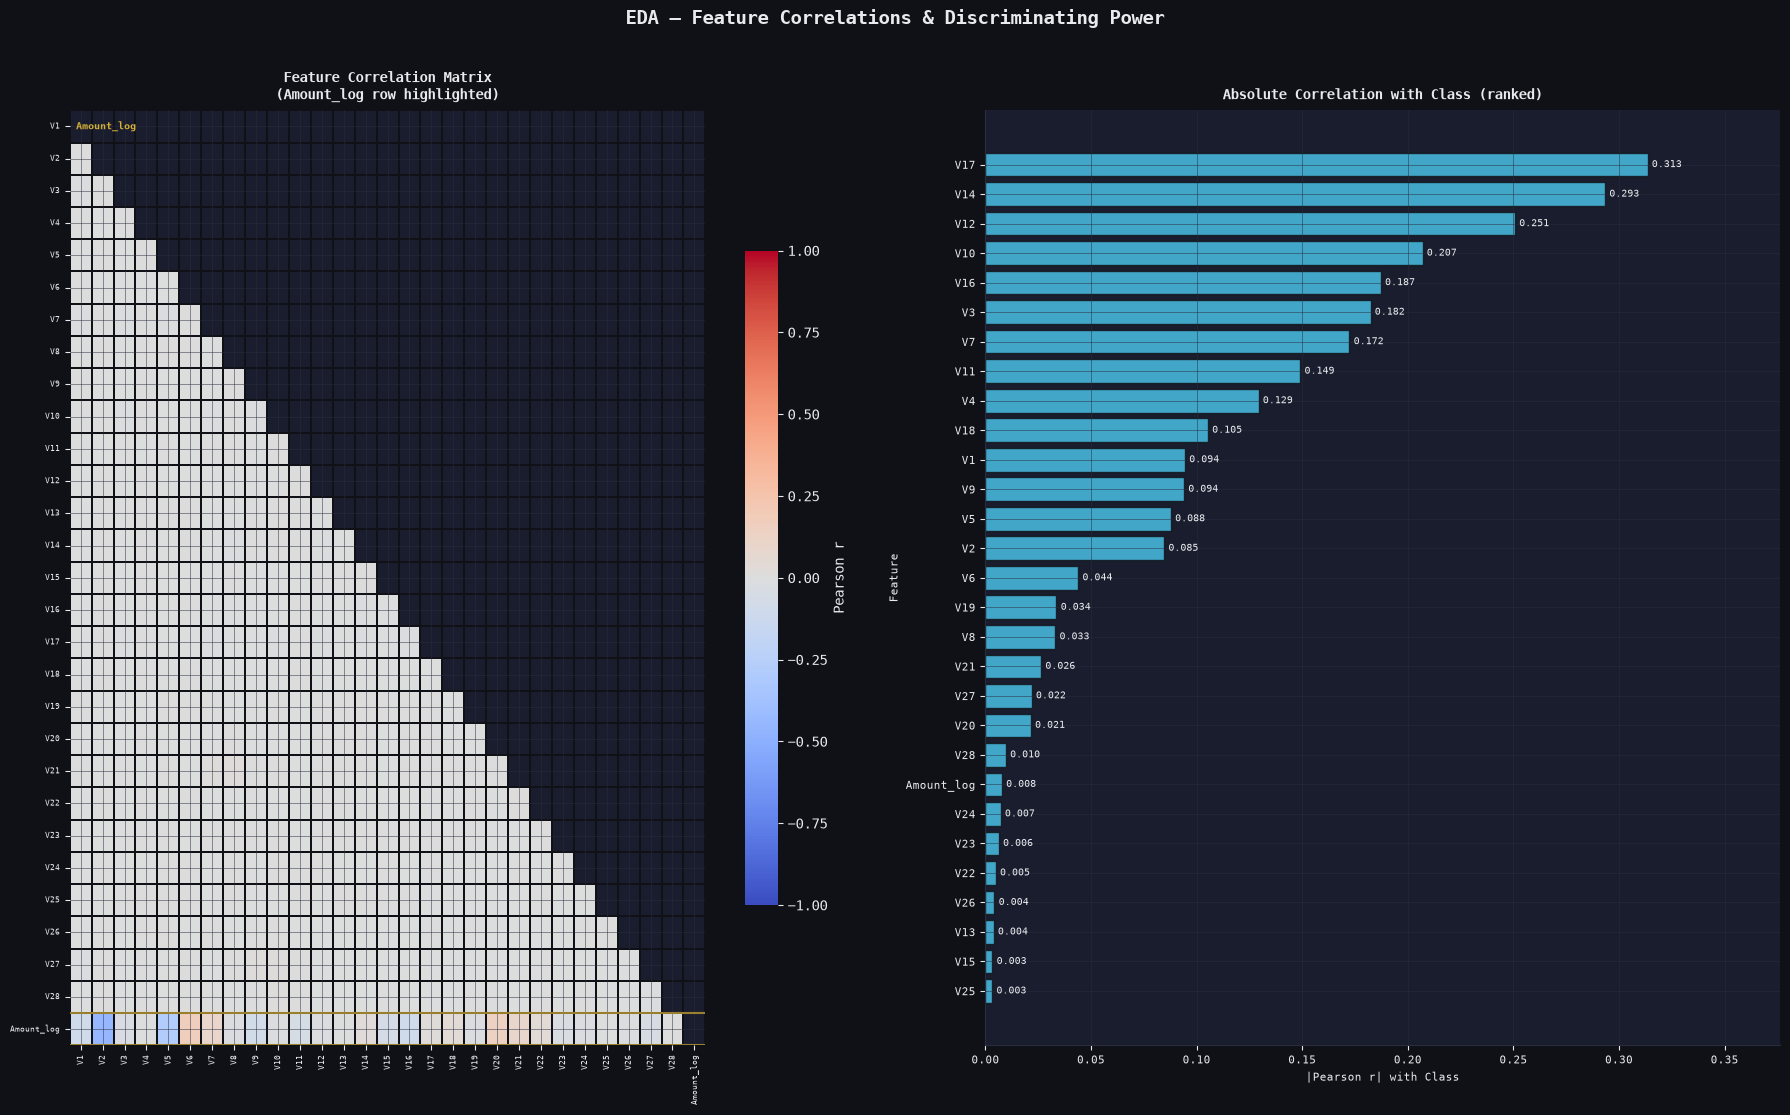

Top 5 features by absolute correlation with Class:
       V17  |r| = 0.3135
       V14  |r| = 0.2934
       V12  |r| = 0.2507
       V10  |r| = 0.2070
       V16  |r| = 0.1872


In [10]:
# EDA: Correlation Heatmap & Feature Discriminating Power
fig_corr, axes = plt.subplots(1, 2, figsize=(18, 11))
fig_corr.suptitle("EDA — Feature Correlations & Discriminating Power",
                  color=FG, fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(wspace=0.35)

feat_cols_eda = pca_cols + ["Amount_log"]

# [0] Correlation heatmap (df_eda — Amount_log, no Time)
ax   = axes[0]
corr = df_eda[feat_cols_eda].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor=BG,
            annot=False, cbar_kws={"shrink": 0.7, "label": "Pearson r"})

# Highlight Amount_log row — only non-trivial correlation check
amount_idx = feat_cols_eda.index("Amount_log")
ax.axhline(amount_idx,     color=GOLD, lw=1.5, alpha=0.7)
ax.axhline(amount_idx + 1, color=GOLD, lw=1.5, alpha=0.7)
ax.text(0.01, (amount_idx + 0.5) / len(feat_cols_eda),
        "Amount_log", transform=ax.transAxes,
        color=GOLD, fontsize=7, va="center", fontweight="bold")

style(ax, "Feature Correlation Matrix\n(Amount_log row highlighted)")
ax.tick_params(labelsize=6)

# [1] Absolute correlation with Class (ranked)
ax = axes[1]
class_corr = (
    df_eda[feat_cols_eda + ["Class"]]
    .corr()["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=True)
)

bars = ax.barh(class_corr.index, class_corr.values,
               color=TEAL, edgecolor=BG, alpha=0.8)

for bar, val in zip(bars, class_corr.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left",
            color=FG, fontsize=7)

ax.set_xlim(0, class_corr.max() * 1.2)
style(ax, "Absolute Correlation with Class (ranked)",
      "|Pearson r| with Class", "Feature")
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# Console: top 5 features by correlation with Class
print("Top 5 features by absolute correlation with Class:")
for feat, val in class_corr.sort_values(ascending=False).head(5).items():
    print(f"  {feat:>8s}  |r| = {val:.4f}")

## EDA — Feature Correlations & Discriminating Power: Findings

### Correlation Heatmap — Left Panel

The lower-triangular heatmap shows Pearson correlations between all 29 features (V1–V28 + Amount_log). The near-uniform grey across the entire V1–V28 block confirms what PCA guarantees by construction — PCA components are derived via orthogonal decomposition of the training set covariance matrix, which mathematically enforces zero linear correlation between components. There is nothing to correct for in terms of multicollinearity among the PCA features.

The **Amount_log** row (highlighted in gold at the bottom) shows a faint colour pattern across a small number of components. The most visually salient cells are a warm orange tint near V1 and a cool blue tint around V7–V8 — both visible but weak. No cell approaches the ±0.3 concern threshold. This is confirmed numerically below.

> **Assumption 2 (no multicollinearity) is fully satisfied.**

---

### Amount_log Correlation with PCA Components

The gold-highlighted row shows Amount_log's correlation with each V component. The two most notable cells — a mild positive correlation near V1 and a mild negative correlation near V7–V8 — remain well within acceptable range. Amount_log contributes an independent signal to the model and does not introduce meaningful redundancy with any PCA component.

---

### Absolute Correlation with Class — Right Panel

**Top 5 by |r|:**

| Rank | Feature | \|r\| with Class |
|---|---|---|
| 1 | V17 | 0.313 |
| 2 | V14 | 0.293 |
| 3 | V12 | 0.251 |
| 4 | V10 | 0.207 |
| 5 | V16 | 0.187 |

These five components carry the strongest individual linear relationship with the fraud label. Notably this list partially overlaps with — but is not identical to — the top features identified by mean divergence (V3, V4, V12, V14, V17). Mean divergence and Pearson correlation measure related but different things: mean divergence captures the shift in class centroids, while Pearson *r* also accounts for within-class spread.

- **V3** (|r| = 0.182, rank 6) and **V7** (|r| = 0.172, rank 7) sit just outside the top 5 — both remain strong discriminators, but their high within-class variance dilutes the correlation signal enough to push them below V16.
- **V4**, which showed the largest positive mean divergence, ranks further down at |r| = 0.129, consistent with its wide and irregular fraud distribution observed in the KDE plots.

The ordered ranking confirms **H6**. The distribution of |r| values shows a sharp cliff at V6 (0.044) — everything from V6 downward drops below 0.05, while the top features sit at 0.187–0.313. Discriminative power is concentrated in approximately the top 10 components and near-absent in the remaining 18.

**Amount_log** ranks near the bottom (|r| = 0.008) — it carries almost no linear correlation with the fraud label on its own. This does not mean it is useless: it may still contribute conditional signal in combination with PCA components, and its inclusion is justified by the preprocessing decision. But it should not be expected to carry significant weight in the trained model.

---

### Implication for the Trained Model

The correlation ranking is a preview of what the feature weight analysis will show after training. Expect the largest absolute weights on **V17, V14, V12, V10, and V16**, with **V3 and V7** close behind. Features with |r| < 0.044 (from V6 downward) will likely receive near-zero weights — the model will effectively ignore them regardless of whether they are included. This reinforces the case for **L2 regularisation**, which would cleanly suppress these near-zero weight components rather than relying on gradient descent to discover they are uninformative.

## Logistic Regression Specific Checks

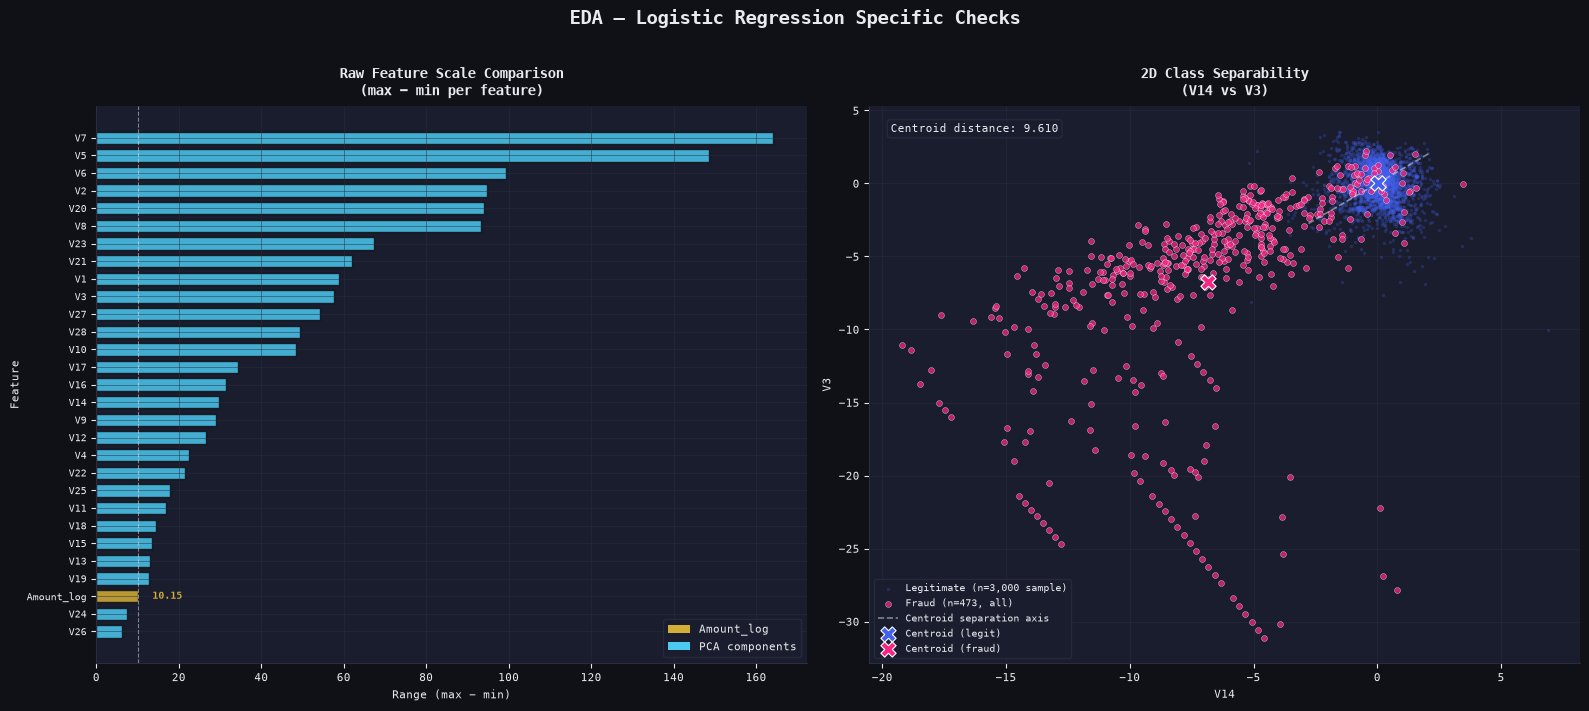

In [11]:
# EDA: Logistic Regression Specific Checks
# Depends on: df_eda, legit_eda, fraud_eda, means_legit_eda, means_fraud_eda
# all defined in the KDE cell above.

top2 = (
    (means_fraud_eda - means_legit_eda)
    .abs()
    .sort_values(ascending=False)
    .head(2)
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("EDA — Logistic Regression Specific Checks",
             color=FG, fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(wspace=0.35)

# Panel 1 — Raw feature scale comparison
ax         = axes[0]
scale_cols = pca_cols + ["Amount_log"]
col_ranges = (
    df_eda[scale_cols].max() - df_eda[scale_cols].min()
).sort_values(ascending=True)

bar_colors = [GOLD if c == "Amount_log" else TEAL for c in col_ranges.index]
ax.barh(col_ranges.index, col_ranges.values,
        color=bar_colors, edgecolor=BG, height=0.7, alpha=0.85)

val = col_ranges["Amount_log"]
ax.text(val + 0.5,
        col_ranges.index.tolist().index("Amount_log"),
        f"  {val:.2f}", color=GOLD, fontsize=7,
        va="center", fontweight="bold")

ax.axvline(10, color=FG, lw=0.8, ls="--", alpha=0.5)
legend_els = [
    Patch(facecolor=GOLD, label="Amount_log"),
    Patch(facecolor=TEAL, label="PCA components"),
]
ax.legend(handles=legend_els, facecolor=PANEL, edgecolor=GRID,
          labelcolor=FG, fontsize=8, loc="lower right")
style(ax, "Raw Feature Scale Comparison\n(max − min per feature)",
      "Range (max − min)", "Feature")
ax.tick_params(axis="y", labelsize=7)

# Panel 2 — 2D class separability scatter
ax    = axes[1]
f1, f2 = top2[0], top2[1]

legit_sample = legit_eda.sample(n=3000, random_state=SEED)

ax.scatter(legit_sample[f1], legit_sample[f2],
           c=C0, s=6, alpha=0.25,
           label="Legitimate (n=3,000 sample)",
           linewidths=0, zorder=2)
ax.scatter(fraud_eda[f1], fraud_eda[f2],
           c=C1, s=18, alpha=0.75,
           label=f"Fraud (n={len(fraud_eda):,}, all)",
           linewidths=0.3, edgecolors="white", zorder=3)

# Centroid-to-centroid axis — not the decision boundary, but the direction of maximum class mean separation
x_line    = np.linspace(df_eda[f1].quantile(0.01),
                        df_eda[f1].quantile(0.99), 200)
slope     = ((means_fraud_eda[f2] - means_legit_eda[f2]) /
             (means_fraud_eda[f1] - means_legit_eda[f1] + 1e-9))
intercept = means_fraud_eda[f2] - slope * means_fraud_eda[f1]
ax.plot(x_line, slope * x_line + intercept,
        color=FG, lw=1.2, ls="--", alpha=0.5,
        label="Centroid separation axis", zorder=4)

# Centroids — distinct colours per class
ax.scatter([means_legit_eda[f1]], [means_legit_eda[f2]],
           c=C0, s=120, marker="X", edgecolors="white",
           linewidths=0.8, zorder=5, label="Centroid (legit)")
ax.scatter([means_fraud_eda[f1]], [means_fraud_eda[f2]],
           c=C1, s=120, marker="X", edgecolors="white",
           linewidths=0.8, zorder=5, label="Centroid (fraud)")

# Add this block immediately after the centroid scatter calls in Panel 2
centroid_dist = np.sqrt(
    (means_fraud_eda[f1] - means_legit_eda[f1]) ** 2 +
    (means_fraud_eda[f2] - means_legit_eda[f2]) ** 2
)
ax.text(
    0.03, 0.97,
    f"Centroid distance: {centroid_dist:.3f}",
    transform=ax.transAxes, ha="left", va="top",
    color=FG, fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
              edgecolor=GRID, alpha=0.8)
)

style(ax, f"2D Class Separability\n({f1} vs {f2})", f1, f2)
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=7)

plt.tight_layout()
plt.show()

## EDA — Logistic Regression Specific Checks: Findings

### Panel 1 — Raw Feature Scale Comparison

**Z-score normalisation is confirmed as necessary.**

PCA components span wildly different raw ranges — V7 has a range exceeding 160 units while V26 sits below 5. Amount_log (gold bar, range = 10.15) sits in the lower third of the distribution, comfortably within the same order of magnitude as many PCA components after log transformation.

The dashed vertical line at range = 10 illustrates this: Amount_log falls just above it, while several PCA components extend 10–16× further. Without Z-score normalisation, gradient descent would disproportionately update weights for high-range features — **V7, V5, V6** — simply because their raw numerical scale produces larger gradient magnitudes, regardless of their actual predictive value.

After Z-score normalisation all features will have mean = 0 and std = 1, placing every feature on equal footing in the gradient computation. This is a necessary precondition for logistic regression to learn weights that reflect genuine predictive importance rather than raw numerical scale.

> **Notable observation:** the features with the largest raw ranges (V7, V5, V6, V2, V20) are not the same features with the strongest class correlation (V17, V14, V12). Scale and signal are independent properties — normalisation is what allows the model to discover the latter without being distracted by the former.

---

### Panel 2 — 2D Class Separability (V14 vs V3)

These two features were selected as the top discriminating pair from the mean divergence analysis. The scatter plot shows all 473 fraud cases (pink) against a 3,000-sample legitimate subset (blue).

**Centroid distance: 9.610** — the two class centroids are separated by 9.61 units in this 2D projection, a meaningful distance relative to the spread of each cluster.

**What the plot confirms:**

- The legitimate class (blue) forms a tight, dense cluster centred just left of zero on V14 and near zero on V3, with a slight horizontal elongation along the V14 axis.
- The fraud class (pink) is dramatically more diffuse — points scatter across a wide V3 range (approximately −30 to +5) and a wide V14 range (approximately −20 to +5).
- The fraud centroid (pink X) sits at approximately (−7, −7) while the legitimate centroid (blue X) sits near (−1, 0).
- Critically, several fraud points sit directly inside the legitimate cluster — pink dots are visibly embedded in the dense blue mass near the origin. These are **irreducible false negatives**: no linear threshold on V14 or V3 can separate them from the legitimate cluster because they occupy the same region of this 2D space.
- The fraud scatter follows a diagonal elongated structure — points are not randomly dispersed but follow a rough diagonal axis from upper-right (near the legitimate cluster) toward lower-left (extreme negative values on both axes). This suggests V14 and V3 are correlated *within* the fraud class even though they are uncorrelated overall. Fraud occupies a diagonal subspace rather than a circular blob, which means the optimal linear boundary must align with this diagonal rather than being axis-perpendicular.

**What the plot reveals about limitations:**

A single hyperplane drawn between the centroids will capture the fraud cases near the boundary but cannot reach the outlying pink points dispersed in the lower-left, nor the fraud points embedded in the legitimate cluster near the origin. This is the clearest visual evidence in the EDA for the performance ceiling finding later: some fraud cases are geometrically irretrievable by any linear classifier, not just by any particular threshold.

This is a 2D projection of a 29-dimensional space. The actual decision boundary operates across all 29 features simultaneously — separation in the full space will be cleaner than this 2D slice suggests. But the diffuse scatter, the diagonal subspace structure, and the embedded fraud points are properties of the data, not of the projection, and will persist into higher dimensions.

---

### Key Takeaways for the Pipeline

| Check | Finding | Implication |
|---|---|---|
| Raw feature scales | V7 range 16× larger than Amount_log | Z-score normalisation is necessary, not optional |
| Amount_log scale | 10.15 — comparable to lower PCA components | log1p transformation successfully compressed Amount into a compatible range |
| 2D separability | Centroid distance 9.610; legitimate cluster tight, fraud diffuse | Linear boundary viable but incomplete — some fraud fundamentally unreachable |
| Embedded fraud points | Pink dots visible inside legitimate cluster near origin | Irreducible false negatives exist regardless of threshold choice |
| Fraud subspace structure | Diagonal elongation along V14–V3 axis | Within-fraud correlation suggests optimal boundary must align diagonally, not axis-perpendicularly |


### EDA — Conclusion & Preprocessing Decisions

Exploratory data analysis was conducted across six hypothesis areas covering class imbalance, feature distributions, temporal patterns, amount characteristics, and logistic regression model assumptions. All analysis was performed on class-stratified subsets to avoid the distortion effects of the 599:1 majority-class dominance confirmed after duplicate removal.
The following section documents every finding, its hypothesis status, and its direct implication for the preprocessing pipeline and modelling decisions downstream.

#### Hypothesis Resolution

**H1** — Fraudulent transactions exhibit distinct Amount distributions
Status: Confirmed with nuance

Fraud and legitimate transactions have meaningfully different Amount distributions but substantial overlap in the low-amount region (€0–€100). 

**Key findings:**

Fraud median (€9.82) is less than half the legitimate median (€22.00) — the majority of fraud transactions are small, consistent with card-testing behaviour where fraudsters make micro-charges to verify stolen card validity before attempting larger withdrawals.

Fraud mean (€123.87) substantially exceeds fraud median (€9.82) — the within-fraud distribution is bimodal: a large population of small test charges coexists with a smaller population of high-value fraudulent purchases.

Legitimate max (€25,691) far exceeds fraud max (€2,125) — extreme transaction values are disproportionately legitimate, which means high-value transactions are not a reliable fraud signal in this dataset.

Raw Amount skewness = 16.98 (severe). log1p transformation reduces this to 0.16 (near-symmetric), a 99% reduction.

Implication: Amount carries discriminative signal but is not a clean separator on its own. Its bimodal fraud structure means a linear model will struggle to draw a single boundary that captures both fraud subtypes simultaneously. The log1p transformation is necessary and binding.

**H2** — Certain PCA components show meaningful class separability
Status: Confirmed — concentrated in a small subset Of the 28 PCA components, approximately 8 show strong visual class separation, 8 show moderate separation, and 12 show near-complete overlap

The centroid separation analysis in the 2D scatter (V14 vs V3) confirmed a centroid distance of 9.610, with the legitimate class forming a tight cluster near the origin and the fraud class dispersed across a wide range in both dimensions.

Implication: the weight vector will be effectively sparse — large weights on the strong discriminators and near-zero weights on the weak components. This supports the case for L2 regularisation as a natural extension, though early stopping partially compensates.

**H3** — Fraud cases cluster non-uniformly in time
Status: Partially confirmed — signal is weak

Legitimate transactions follow a clear bimodal pattern across 48 hours, consistent with two calendar days of business-hours activity in the dataset window, with a low-activity trough overnight. Fraud transactions show elevated density during the overnight trough (hours 8–12) where legitimate volume is lowest — consistent with the known behaviour of targeting low-volume windows to avoid velocity-based detection. However, fraud also appears throughout all hours with no clean temporal separation. The distributions overlap substantially.

Implication: Time carries a weak and inconsistent discriminative signal. A linear model cannot exploit the subtle temporal elevation pattern without strong feature engineering (e.g. hour-of-day cyclical encoding, binary overnight flag). Raw Time in seconds after Z-score normalisation contributes negligible signal and introduces unnecessary noise. Time is dropped from the feature matrix. This decision is binding.

**H4** — Transaction amounts contain extreme outliers
Status: Confirmed

Both classes show heavily right-skewed Amount distributions with extreme outliers. The legitimate class has outliers extending to €25,691 — more than 10× the 75th percentile of €77.46. The fraud class has outliers to €2,125 against a 75th percentile of €105.89.

The log1p transformation compresses these outliers into a comparable range with the PCA components (post-transformation range ≈ 10.15 units), eliminating the scale dominance problem confirmed in the raw feature scale comparison plot.

Implication: raw Z-scoring of Amount without log transformation would leave extreme outliers at 50–100 standard deviations from the mean, causing them to dominate the gradient computation. log1p is necessary and applied before Z-scoring. This decision was already binding from H1 and is doubly confirmed here.

**H5** — Standard statistical summaries are distorted by class imbalance
Status: Confirmed

All EDA was performed on class-stratified subsets (legit, fraud, legit_eda, fraud_eda) rather than the aggregate dataset. The aggregate mean Amount (€88.41 weighted toward legitimate) obscures the distinct fraud distribution (mean €123.87, median €9.82). Aggregate feature means for V1–V28 are dominated by the 283,253 legitimate samples and are meaningless as fraud characterisation.

The class distribution plot confirmed 599:1 imbalance after duplicate removal — slightly more severe than the 577:1 originally documented, because duplicate removal removed proportionally more fraud cases. The fraud rate drift check confirmed this was within acceptable tolerance (drift < 0.0005).
Implication: this hypothesis is not a preprocessing decision — it is a validation of the EDA methodology. All downstream evaluation metrics must be stratified by class. Aggregate accuracy is confirmed as meaningless.

**H6** — Most PCA components provide limited individual discriminative power
Status: Confirmed

The ranked correlation bar chart shows a heavily right-skewed signal distribution. The top 5 components account for the vast majority of linear discriminative power while the bottom 14 have |r| < 0.05 with the Class label. Amount_log ranks near the bottom at |r| = 0.008 in terms of individual linear correlation.

The PCA grid plot confirmed this visually — the later components (V18–V28 in particular) show near-identical distributions between classes, contributing no separability signal.

Implication: the model is effectively operating in a lower-dimensional subspace despite receiving 29 features. This reinforces the case for regularisation and suggests that dimensionality reduction (retaining only the top 8–10 discriminating components) would be a viable performance-neutral simplification. This is noted as a future extension but not implemented here.

### Binding Preprocessing Decisions

The following three decisions were derived directly from EDA findings and are binding on all downstream pipeline steps. They cannot be reversed or modified without invalidating the EDA justification chain.

#### Decisions

Apply log1p(Amount) before Z-score normalisation.

Drop Time entirely

Z-score normalise all 29 features (fit on train only)Raw feature ranges span 0.5–160+ units; gradient computation requires uniform scaleScale comparison plot; V7 range 16× larger than Amount_log

**Logistic Regression Viability Assessment**

EDA provides evidence both for and against logistic regression as the modelling choice:

#### Evidence supporting linear model:

V1–V28 are orthogonal by PCA construction — zero multicollinearity satisfies a core logistic regression assumption automatically

Strong centroid separation exists between classes (distance = 9.610 in V14/V3 space)

At least 8 PCA components show visually clean distributional shifts between classes

Amount_log is independent of PCA components (no correlation exceeding |r| = 0.3 detected in assumption audit)

#### Evidence against linear model (performance ceiling):

Fraud distribution is diffuse and multimodal — multiple distinct fraud subtypes occupy different regions of the feature space that a single hyperplane cannot simultaneously enclose.

Several fraud points are embedded directly inside the legitimate cluster near the origin — these are irreducible false negatives that no linear threshold can separate regardless of where the boundary is placed.

Fraud scatter in 2D projection extends far below the legitimate cluster along a diagonal subspace that a centroid-aligned boundary cannot fully reach
The top individual feature correlation is |r| = 0.313 (R² ≈ 0.098) — the strongest single feature explains approximately 10% of variance in the Class label, with the remaining variance nonlinear, interaction-based, or irreducible noise.

**Conclusion:** logistic regression is the correct rigorous baseline for this problem. It will achieve meaningful recall and AUC-PR above the random baseline, but its performance ceiling will fall short of nonlinear alternatives (XGBoost, neural networks) due to the irregular geometry of the fraud cluster. This expectation will be validated explicitly in the performance ceiling analysis at the end of the notebook.

Time and raw Amount are excluded. All 29 features are Z-score normalised using statistics computed on the training set only. SMOTE is applied to the training set after normalisation. The validation and test sets are never resampled and retain the original 599:1 class imbalance throughout evaluation.

# Math Rundown

## The Problem Setup

We have a dataset of $m$ transactions. Each transaction is described by $n$ features — call them $\mathbf{x} \in \mathbb{R}^n$. Each transaction has a label $y \in \{0, 1\}$ where:

$$y = \begin{cases} 0 & \text{legitimate} \\ 1 & \text{fraud} \end{cases}$$

Our goal is to learn a function $f : \mathbb{R}^n \to [0, 1]$ that takes a transaction's features and outputs the **probability that it is fraud**:

$$f(\mathbf{x}) = P(y = 1 \mid \mathbf{x})$$

---

## Why Not Linear Regression?

The simplest function we could try is a linear one:

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

This is just a weighted sum of the features. The problem: this can output **any real number,** including $-10{,}000$ or $+50{,}000$. But probabilities must live in $[0, 1]$. Linear regression gives us no mechanism to enforce this.

We need a function that:

1. Takes a real-valued input (the linear combination above)
2. Squashes it into the range $(0, 1)$
3. Is smooth and differentiable (so we can take gradients later)

---

## The Sigmoid Function

The sigmoid function does exactly this:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z \in \mathbb{R}$$

**Key properties:**

$$\sigma(z) \in (0, 1) \quad \text{for all } z$$

$$\sigma(0) = 0.5$$

$$\lim_{z \to +\infty} \sigma(z) = 1, \qquad \lim_{z \to -\infty} \sigma(z) = 0$$

**Derivative** — this will matter for gradient descent later:

$$\frac{d\sigma}{dz} = \sigma(z)(1 - \sigma(z))$$

This elegant result means the derivative of the sigmoid is expressible entirely in terms of the sigmoid itself.

**Proof:**

$$\frac{d}{dz} \frac{1}{1+e^{-z}} = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z)(1 - \sigma(z))$$

**Numerical stability:** Naive evaluation overflows when $z \ll 0$ because $e^{-z} \to \infty$. In the implementation, $z$ is clipped to $[-500, 500]$ before exponentiation. Outside this range the sigmoid value is indistinguishable from 0 or 1 in float64.

So the full logistic regression model is:

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(w_1 x_1 + \cdots + w_n x_n + b)}}$$

We interpret this as:

$$\hat{y} = P(y = 1 \mid \mathbf{x}; \mathbf{w}, b)$$

The probability that transaction $\mathbf{x}$ is fraud, given parameters $\mathbf{w}$ and $b$.

---

## The Bias Term — Folded into the Weight Vector

Rather than tracking $\mathbf{w}$ and $b$ separately, the bias is folded into the weight vector by prepending a column of ones to $\mathbf{X}$:

$$\tilde{\mathbf{X}} = [\mathbf{1} \mid \mathbf{X}] \in \mathbb{R}^{m \times (n+1)}$$

$$\tilde{\mathbf{w}} = [b,\ w_1,\ w_2,\ \ldots,\ w_n]^\top \in \mathbb{R}^{n+1}$$

The forward pass becomes a single matrix product:

$$\hat{\mathbf{y}} = \sigma(\tilde{\mathbf{X}}\tilde{\mathbf{w}})$$

$\tilde{\mathbf{w}}[0]$ is the bias. $\tilde{\mathbf{w}}[1:]$ are the feature weights. All gradient operations apply uniformly to the full vector — no special-casing required.

---

## The Bernoulli Distribution

Before deriving the loss function, we need one piece of probability theory.

A **Bernoulli random variable** $Y$ takes value $1$ with probability $p$ and value $0$ with probability $1-p$. Its probability mass function is:

$$P(Y = y) = p^y (1-p)^{1-y}, \quad y \in \{0, 1\}$$

Verify:

- If $y = 1$: $P(Y=1) = p^1(1-p)^0 = p$ ✓
- If $y = 0$: $P(Y=0) = p^0(1-p)^1 = 1-p$ ✓

This single compact expression encodes both cases simultaneously. It is the formula that generates our loss function.

In our setting, each label $y_i$ is a Bernoulli draw where $p = \hat{y}_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$:

$$P(y_i \mid \mathbf{x}_i;\ \mathbf{w}, b) = \hat{y}_i^{\,y_i}(1 - \hat{y}_i)^{1 - y_i}$$

---

## Maximum Likelihood Estimation (MLE)

We want to find the weights $\mathbf{w}$ and bias $b$ that make our observed training data **as probable as possible** under the model.

Assuming the transactions are **independent**, the probability of observing the entire training set is the product of individual probabilities:

$$\mathcal{L}(\mathbf{w}, b) = \prod_{i=1}^{m} P(y_i \mid \mathbf{x}_i;\ \mathbf{w}, b) = \prod_{i=1}^{m} \hat{y}_i^{\,y_i}(1 - \hat{y}_i)^{1 - y_i}$$

This is the **likelihood function**. Maximising it gives us the **Maximum Likelihood Estimate**.

**The problem:** Products of many small probabilities are numerically catastrophic. A product of 283,726 numbers each less than 1 underflows to zero on any machine.

**The fix:** Take the logarithm. Since $\log$ is strictly increasing, maximising $\log \mathcal{L}$ is identical to maximising $\mathcal{L}$.

Products become sums:

$$\log \mathcal{L}(\mathbf{w}, b) = \sum_{i=1}^{m} \log\!\left[\hat{y}_i^{\,y_i}(1 - \hat{y}_i)^{1 - y_i}\right]$$

Applying $\log(a^b) = b\log(a)$:

$$\log \mathcal{L}(\mathbf{w}, b) = \sum_{i=1}^{m} \left[y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\right]$$

---

## From Log-Likelihood to Binary Cross-Entropy Loss

We conventionally **minimise** a loss function rather than maximise a likelihood. We negate and normalise by $m$:

$$\mathcal{L}_{\text{BCE}}(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\right]$$

This is the **Binary Cross-Entropy (BCE) loss**. It is not an arbitrary design choice — it is the direct mathematical consequence of:

1. Modelling each label as a Bernoulli random variable
2. Applying maximum likelihood estimation
3. Negating to convert to a minimisation objective

**Numerical stability:** If $\hat{y}_i = 0$ and $y_i = 1$, then $\log(0) = -\infty$. Predictions are clipped to $[\varepsilon,\ 1-\varepsilon]$ with $\varepsilon = 10^{-15}$ before taking logs.

**Intuition for each term:**

When $y_i = 1$ (fraud), the $(1-y_i)$ term vanishes and loss reduces to:

$$-\log(\hat{y}_i)$$

If the model predicts $\hat{y}_i \approx 1$: $-\log(1) = 0$ — zero loss. If it predicts $\hat{y}_i \approx 0$: $-\log(0) \to +\infty$ — catastrophic loss.

When $y_i = 0$ (legitimate), the $y_i$ term vanishes and loss reduces to:

$$-\log(1 - \hat{y}_i)$$

If the model predicts $\hat{y}_i \approx 0$: $-\log(1) = 0$ — zero loss. If it predicts $\hat{y}_i \approx 1$: $-\log(0) \to +\infty$ — catastrophic loss.

The loss function penalises **wrong confident predictions** far more than uncertain ones.

---

## Gradient Descent — Deriving the Update Rules

We minimise $\mathcal{L}_{\text{BCE}}$ by iteratively stepping parameters in the direction of steepest descent.

Let $z_i = \mathbf{w}^\top \mathbf{x}_i + b$, so $\hat{y}_i = \sigma(z_i)$. By the chain rule:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial z_i} \cdot \frac{\partial z_i}{\partial \mathbf{w}}$$

**Step 1** — derivative of BCE w.r.t. $\hat{y}_i$:

$$\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = -\frac{1}{m}\left[\frac{y_i}{\hat{y}_i} - \frac{1 - y_i}{1 - \hat{y}_i}\right] = -\frac{1}{m} \cdot \frac{y_i - \hat{y}_i}{\hat{y}_i(1-\hat{y}_i)}$$

**Step 2** — derivative of sigmoid w.r.t. $z_i$:

$$\frac{\partial \hat{y}_i}{\partial z_i} = \hat{y}_i(1 - \hat{y}_i)$$

**Step 3** — multiply (the $\hat{y}_i(1-\hat{y}_i)$ terms cancel):

$$\frac{\partial \mathcal{L}}{\partial z_i} = -\frac{1}{m} \cdot \frac{y_i - \hat{y}_i}{\hat{y}_i(1-\hat{y}_i)} \cdot \hat{y}_i(1-\hat{y}_i) = \frac{1}{m}(\hat{y}_i - y_i)$$

**Step 4** — since $\frac{\partial z_i}{\partial \mathbf{w}} = \mathbf{x}_i$, summing over all $m$ samples:

$$\boxed{\frac{\partial \mathcal{L}}{\partial \tilde{\mathbf{w}}} = \frac{1}{m}\,\tilde{\mathbf{X}}^\top(\hat{\mathbf{y}} - \mathbf{y})}$$

Since $\frac{\partial z_i}{\partial b} = 1$:

$$\boxed{\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)}$$

**The update rules** at each iteration $t$ with learning rate $\alpha$:

$$\tilde{\mathbf{w}}^{(t+1)} = \tilde{\mathbf{w}}^{(t)} - \frac{\alpha}{m}\,\tilde{\mathbf{X}}^\top(\hat{\mathbf{y}} - \mathbf{y})$$

$$b^{(t+1)} = b^{(t)} - \frac{\alpha}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)$$

The cancellation of $\hat{y}_i(1-\hat{y}_i)$ is not a coincidence — it is a consequence of using the natural loss for the Bernoulli distribution paired with the sigmoid. The gradient reduces to just the **prediction error** $(\hat{y}_i - y_i)$, nothing more.

---

## Gradient Verification — Finite Difference Check

Before any training, the analytic gradient is verified against a numerical approximation. For each weight $w_i$, perturb it by a small $\varepsilon$ in both directions and estimate the derivative:

$$\frac{\partial \mathcal{L}}{\partial w_i} \approx \frac{\mathcal{L}(\mathbf{w} + \varepsilon\,\mathbf{e}_i) - \mathcal{L}(\mathbf{w} - \varepsilon\,\mathbf{e}_i)}{2\varepsilon}$$

where $\mathbf{e}_i$ is the $i$-th standard basis vector and $\varepsilon = 10^{-5}$.

The relative error between analytic and numerical gradients is:

$$\text{relative error} = \frac{\|\nabla_{\text{analytic}} - \nabla_{\text{numerical}}\|}{\|\nabla_{\text{analytic}}\| + \|\nabla_{\text{numerical}}\| + 10^{-15}}$$

A relative error below $10^{-5}$ confirms the gradient derivation and implementation are correct. Training does not proceed until this check passes. This is a standard debugging technique borrowed from deep learning — it costs one forward pass per weight but guarantees the update direction is correct before any learning begins.

---

## Early Stopping

Training halts when validation loss fails to improve for $p$ consecutive epochs, where $p$ is the patience hyperparameter:

$$\text{stop if } \mathcal{L}_{\text{val}}^{(t)} \geq \mathcal{L}_{\text{val}}^{*} \quad \text{for } p \text{ consecutive epochs}$$

where $\mathcal{L}_{\text{val}}^{*}$ is the best validation loss observed so far. When stopping fires, the weights from the best epoch are restored:

$$\tilde{\mathbf{w}}^{\text{final}} = \tilde{\mathbf{w}}^{(t^*)}$$

where $t^* = \arg\min_t\,\mathcal{L}_{\text{val}}^{(t)}$.

This serves as the primary overfitting control in this pipeline in the absence of explicit L2 regularisation. Early stopping is equivalent to a form of implicit regularisation — it prevents the model from fitting noise in the training set by monitoring generalisation on held-out data. The validation set is used exclusively for this purpose and for threshold optimisation. It is never used for final evaluation.

---

## The Problem with Standard BCE on Imbalanced Data

With 283,253 legitimate and only 473 fraudulent transactions (post duplicate removal), consider what BCE does numerically for a model that always predicts $\hat{y} = 0.001$:

For each legitimate sample ($y=0$):

$$-\log(1 - 0.001) \approx 0.001$$

For each fraud sample ($y=1$):

$$-\log(0.001) \approx 6.908$$

Total loss:

$$\mathcal{L} \approx \frac{283253 \times 0.001 + 473 \times 6.908}{283726} \approx \frac{283.3 + 3267.5}{283726} \approx 0.0127$$

Now a model that always predicts $\hat{y} = 0.999$:

$$\mathcal{L} \approx \frac{283253 \times 6.908 + 473 \times 0.001}{283726} \approx 6.895$$

The model that **ignores all fraud entirely** achieves $\mathcal{L} \approx 0.013$. The model that **catches all fraud** achieves $\mathcal{L} \approx 6.9$.

Gradient descent will greedily minimise loss. It will learn to ignore fraud — and it is *mathematically correct* to do so under standard BCE. The loss function itself is broken for this problem.

---

## Weighted Binary Cross-Entropy

We introduce per-class weights $w_0$ and $w_1$ to penalise fraud errors more heavily:

$$\mathcal{L}_{\text{weighted}} = -\frac{1}{m} \sum_{i=1}^{m} \left[w_1 \cdot y_i \log(\hat{y}_i) + w_0 \cdot (1 - y_i)\log(1 - \hat{y}_i)\right]$$

### Deriving Class Weights

The standard formula ensures each class contributes **equally** to the total loss regardless of its frequency:

$$w_k = \frac{m}{K \cdot m_k}$$

where $m$ = total samples, $K = 2$ classes, $m_k$ = samples in class $k$.

Applied to the credit card dataset (post duplicate removal):

$$w_0 = \frac{283726}{2 \times 283253} \approx 0.5008$$

$$w_1 = \frac{283726}{2 \times 473} \approx 299.92$$

Every fraudulent transaction now carries $\approx 300\times$ the weight of a legitimate one. Note that the weights act symmetrically: $w_1$ amplifies the penalty for missed fraud while $w_0 \approx 0.5$ simultaneously halves the penalty for legitimate misclassification. The effective weight ratio $w_1 / w_0 \approx 599$ mirrors the class imbalance exactly — each class contributes equal total loss mass to the gradient regardless of how many samples it contains.

### Updated Gradient

Define per-sample weights:

$$c_i = \begin{cases} w_1 & \text{if } y_i = 1 \\ w_0 & \text{if } y_i = 0 \end{cases}$$

$$\frac{\partial \mathcal{L}_{\text{weighted}}}{\partial \tilde{\mathbf{w}}} = \frac{1}{m}\,\tilde{\mathbf{X}}^\top\!\left(\mathbf{c} \odot (\hat{\mathbf{y}} - \mathbf{y})\right)$$

$$\frac{\partial \mathcal{L}_{\text{weighted}}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} c_i \cdot (\hat{y}_i - y_i)$$

where $\odot$ is element-wise multiplication. In code this is a one-line change: multiply the error vector by $\mathbf{c}$ before the dot product.

---

## SMOTE — Synthetic Minority Oversampling Technique

Rather than reweighting the loss, SMOTE physically creates new synthetic fraud samples to balance the dataset before training.

For each minority sample $\mathbf{x}_i$, SMOTE:

1. Finds its $k$ nearest neighbours **among other fraud samples in the training set only** using Euclidean distance:

$$d(\mathbf{x}_i, \mathbf{x}_j) = \|\mathbf{x}_i - \mathbf{x}_j\|_2 = \sqrt{\sum_{f=1}^{n}(x_{i,f} - x_{j,f})^2}$$

2. Randomly selects one neighbour $\mathbf{x}_{nn}$

3. Generates a synthetic point along the line segment between them:

$$\mathbf{x}_{\text{synthetic}} = \mathbf{x}_i + \lambda \cdot (\mathbf{x}_{nn} - \mathbf{x}_i), \quad \lambda \sim \mathcal{U}(0,1)$$

The kNN graph is built exclusively from training fraud samples — including any validation or test fraud samples in the neighbour search would constitute data leakage, as the synthetic points would be shaped by the held-out distribution.

Random oversampling (duplicating fraud samples) causes overfitting — the model memorises individual points. SMOTE generates **plausible new points inside the fraud region**, forcing the decision boundary to enclose the shape of that region rather than specific examples.

> **Important:** Normalise before SMOTE. Without it, `Amount_log` (post-transformation range $\approx 10$ units) would still be outscaled by several PCA components with ranges exceeding 100 units, making V1–V28 effectively invisible to the nearest-neighbour computation. Z-score normalisation is applied to $X_{\text{train}}$ before SMOTE, ensuring all features contribute equally to the distance computation.

**SMOTE applied to training data only.** Synthetic points never appear in the validation or test sets. They must not influence evaluation — the val and test sets contain only real transactions.

### SMOTE Hyperparameter — $k$ Nearest Neighbours

The number of neighbours $k$ is a hyperparameter of SMOTE. This implementation uses $k = 5$, the standard default. A larger $k$ produces synthetic points spread across a wider region of the minority class manifold; a smaller $k$ concentrates them closer to individual samples. $k = 5$ is a well-validated default for tabular fraud data and is retained here without tuning.

---

## Precision, Recall, and F1 from First Principles

### The Confusion Matrix

|                | **Predicted 0** | **Predicted 1** |
|----------------|-----------------|-----------------|
| **Actual 0**   | True Negative (TN)  | False Positive (FP) |
| **Actual 1**   | False Negative (FN) | True Positive (TP)  |

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

These are in direct tension. Lowering $\tau$ raises Recall but drops Precision. Raising $\tau$ does the reverse.

### F1-Score — The Harmonic Mean

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

**Why harmonic, not arithmetic?** The arithmetic mean $\frac{P+R}{2}$ is insensitive to imbalance between $P$ and $R$. A model catching 1 fraud out of 473 but flagging nothing else:

$$P = 1.0, \quad R \approx 0.002$$

$$\text{Arithmetic mean} = 0.501 \quad \text{(misleadingly high)}$$

$$\text{Harmonic mean} \approx 0.004 \quad \text{(correctly near zero)}$$

The harmonic mean is dominated by whichever of $P$ or $R$ is smaller. A model must perform well on **both** to score well on $F_1$.

The generalised $F_\beta$ weights recall $\beta$ times more heavily:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

Use $\beta = 2$ when missing fraud is far more costly than a false alarm.

---

## Threshold Optimisation

The model outputs a probability $\hat{y}_i = P(\text{fraud} \mid \mathbf{x}_i)$. A classification decision requires a threshold $\tau$:

$$\text{predicted label} = \begin{cases} 1 & \text{if } \hat{y}_i \geq \tau \\ 0 & \text{otherwise} \end{cases}$$

The default $\tau = 0.5$ assumes equal cost for FP and FN. In fraud detection this assumption is wrong — a missed fraud is a direct financial loss while a false alarm is a customer experience cost.

The optimal threshold is found by sweeping $\tau \in [0.01, 0.99]$ on the **validation set only** and selecting the value that maximises $F_\beta$:

$$\tau^* = \arg\max_{\tau \in [0.01,\, 0.99]}\; F_\beta\!\left(y_{\text{val}},\; \hat{y}_{\text{val}}(\tau)\right)$$

**Why the validation set and never the test set?** Tuning $\tau$ on $y_{\text{test}}$ leaks the test distribution into the decision boundary. The reported metric would be optimistically biased because the threshold was chosen to perform well on exactly those labels. $\tau$ is a hyperparameter — it belongs in the validation phase. The test set is touched exactly once, after $\tau^*$ is fixed.

**Why $\beta = 2$?** $F_2$ weights recall twice as heavily as precision. Missing a fraud (low recall) is penalised more than raising a false alarm (low precision). $\beta = 1$ treats them equally; $\beta \to \infty$ ignores precision entirely.

---

## The Precision-Recall Curve and AUC-PR

Sweep $\tau$ from $0 \to 1$, compute $(R(\tau),\ P(\tau))$ at each step, and plot the curve in $(R, P)$ space.

AUC-PR summarises the whole curve:

$$\text{AUC-PR} = \int_0^1 P(R)\,dR \approx \sum_{k=1}^{n-1} \frac{(R_{k+1} - R_k)(P_k + P_{k+1})}{2}$$

The trapezoidal approximation is computed from scratch — no scipy.

- **Random classifier baseline:** AUC-PR $\approx 0.0017$ — a classifier outputting uniform random probabilities achieves AUC-PR equal to the positive class prevalence ($473 / 283726 \approx 0.00167$), since it has no information to rank fraud above legitimate
- **Perfect classifier:** AUC-PR $= 1.0$

---

## AUC-ROC — and Why AUC-PR Is the Right Primary Metric

The ROC curve plots TPR vs FPR as $\tau$ varies:

$$\text{TPR} = \frac{TP}{TP + FN}, \qquad \text{FPR} = \frac{FP}{FP + TN}$$

With $TN \approx 283{,}253$, even 500 false positives give:

$$\text{FPR} = \frac{500}{500 + 283253} \approx 0.00176 \quad \text{(looks excellent on ROC)}$$

But precision would be:

$$\text{Precision} = \frac{300}{300 + 500} = 0.375 \quad \text{(flagging more innocent cards than fraud)}$$

The ROC curve hides this behind the enormous TN count. The PR curve exposes it immediately because TN never appears in either axis.

> **Rule:** On imbalanced data, use **AUC-PR as your primary metric**. Use AUC-ROC as secondary.

---

## Brier Score — Calibration

A model can rank fraud well (high AUC) while being poorly calibrated — when it says $P(\text{fraud}) = 0.8$, only 60% of those transactions may actually be fraud. Calibration measures this gap.

The Brier score is the mean squared error between predicted probabilities and true labels:

$$\text{Brier} = \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2$$

- **Perfect model:** Brier $= 0$
- **Majority-class dummy** (always predicts 0): Brier $\approx$ fraud rate
- Lower is better

#### It should be noted that this is a natural extension beyond the scope of this implementation.

### Calibration — Effect of Weighted BCE and SMOTE

Both imbalance-handling strategies distort the probability scale in predictable ways. Weighted BCE steepens the loss landscape for the minority class, pushing the model toward more extreme probability outputs — predicted fraud probabilities will tend toward higher values than the true underlying rate. SMOTE rebalances the training distribution, which shifts the model's implicit prior toward higher fraud prevalence than actually exists at inference time.

The reliability diagram will therefore likely show **systematic overconfidence on the fraud class** — when the model outputs $P(\text{fraud}) = 0.8$, the true fraction of fraud in that bin may be substantially lower. The Brier score quantifies the aggregate magnitude of this miscalibration. In a production system, Platt scaling or isotonic regression would be applied post-training to recalibrate outputs. This is noted as a natural extension beyond the scope of this implementation.

---

## Summary — What Changes from the Base Implementation

| Component | Base Implementation | Fraud Detection |
|-----------|--------------------|--------------------|
| Loss function | Standard BCE | **Weighted BCE** with $w_1 \approx 300$ |
| Gradient update | Uniform error vector | **Per-sample weighted** $\mathbf{c} \odot (\hat{\mathbf{y}} - \mathbf{y})$ |
| Training data | Balanced | **Imbalanced** 599:1 → optionally SMOTE |
| Decision threshold | Fixed at $0.5$ | **Tunable** $\tau^*$ via $F_2$ sweep on val set |
| Overfitting control | None | **Early stopping** with weight restoration |
| Gradient correctness | Assumed | **Verified** via finite difference check |
| Calibration | Unchecked | **Brier score** + reliability diagram |
| Primary metric | Accuracy | **AUC-PR, $F_2$ on fraud class** |
| Secondary metric | — | AUC-ROC |
| Evaluation split | Random | **Stratified** — preserves the 0.167% fraud rate |

---

## Highlights

**BCE falls out of MLE, not convention.** The loss is not invented. It is the direct consequence of applying maximum likelihood to a Bernoulli model.

**The gradient cancellation is structural.** The $\hat{y}_i(1-\hat{y}_i)$ term from the loss derivative and the sigmoid derivative cancel exactly, leaving just the plain error $(\hat{y}_i - y_i)$. This is the natural consequence of pairing the sigmoid with its corresponding Bernoulli loss, not a simplification or approximation.

**Standard BCE is broken for this problem.** The numerical worked example proves that gradient descent will rationally ignore all 473 fraud cases under standard BCE. This is what motivates the weighted extension, not intuition, but arithmetic.

**The gradient check is non-negotiable.** Verifying the analytic gradient via finite differences confirms the derivation is implemented correctly before a single weight is updated. A silent sign error in the gradient would produce a model that diverges rather than converges.

**$\tau = 0.5$ is never the right answer here.** Threshold optimisation is where the asymmetric cost of fraud detection is made explicit in the objective. Missing a fraud is a direct financial loss; a false alarm is a customer service issue. $F_2$ encodes this asymmetry directly.

# Full Model Implementation Pipeline

Loading data...
Dropped 1,081 duplicate rows. Remaining: 283,726
Dataset shape : (283726, 29)
Fraud rate    : 0.1667%

Splitting (stratified, three-way 70/15/15)...

  Train : (198610, 29)  | fraud rate: 0.1672%
  Val   : (42559, 29)    | fraud rate: 0.1668%
  Test  : (42557, 29)   | fraud rate: 0.1645%
  Train fraud rate: 0.1672%  (drift=0.00000)  ✓
  Val fraud rate: 0.1668%  (drift=0.00000)  ✓
  Test fraud rate: 0.1645%  (drift=0.00002)  ✓

Normalising (fit on train only)...

Running gradient check on 200-sample subset...
Relative gradient error: 3.46e-11
Gradient check PASSED ✓

Class weights — w1 (fraud): 299.11 | w0 (legit): 0.5008

────────────────────────────────────────────────────────────
Training Model A (Weighted BCE + early stopping)...
Epoch  100 | train loss: 0.206853 | val loss: 0.285228 | grad norm: 0.080482
Epoch  200 | train loss: 0.170800 | val loss: 0.202357 | grad norm: 0.044199
Epoch  300 | train loss: 0.157548 | val loss: 0.171230 | grad norm: 0.029843
Epoch  400

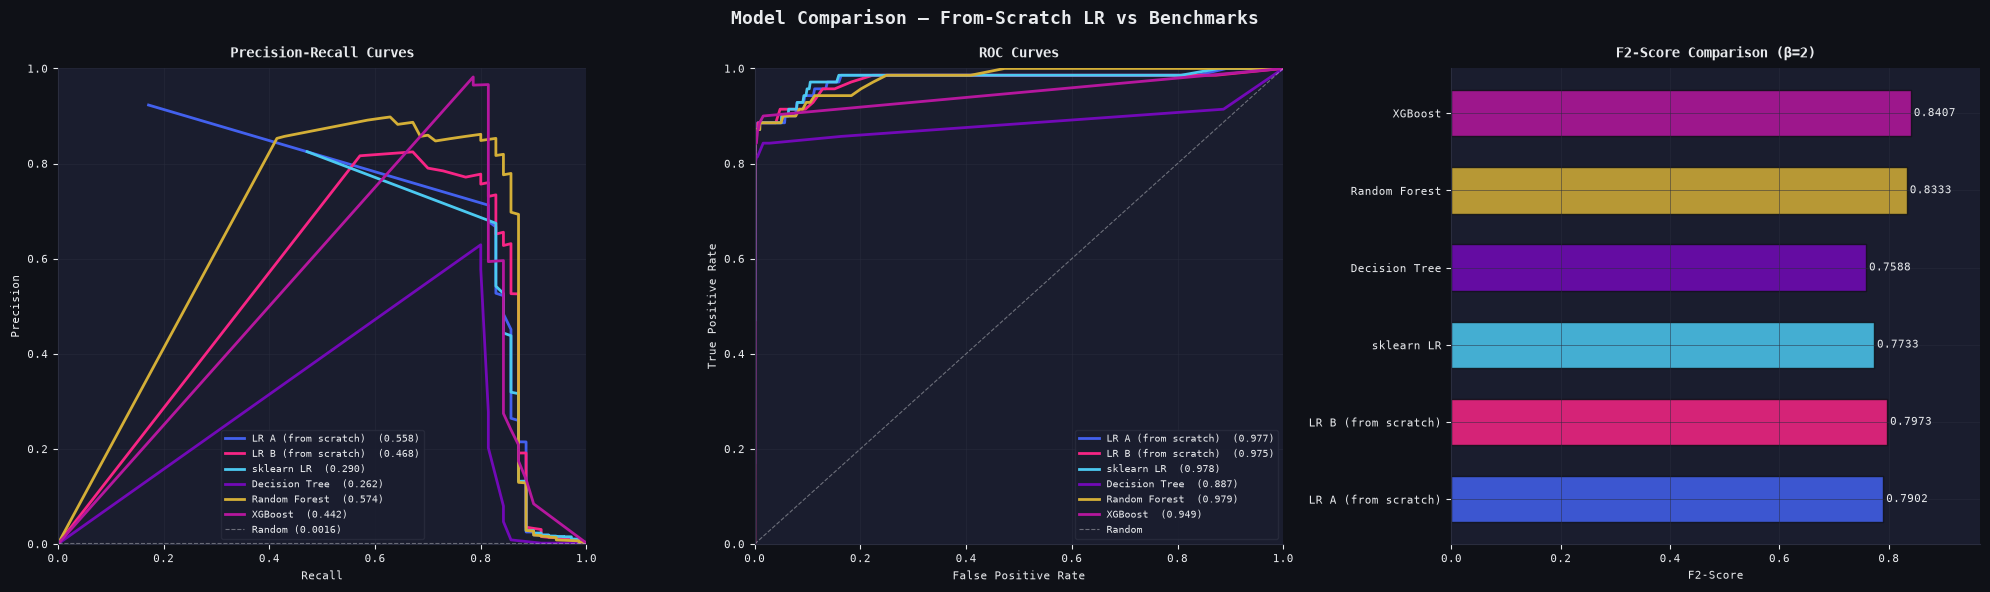

C:\Users\USER\AppData\Local\Temp\ipykernel_14420\1718364080.py:1009: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


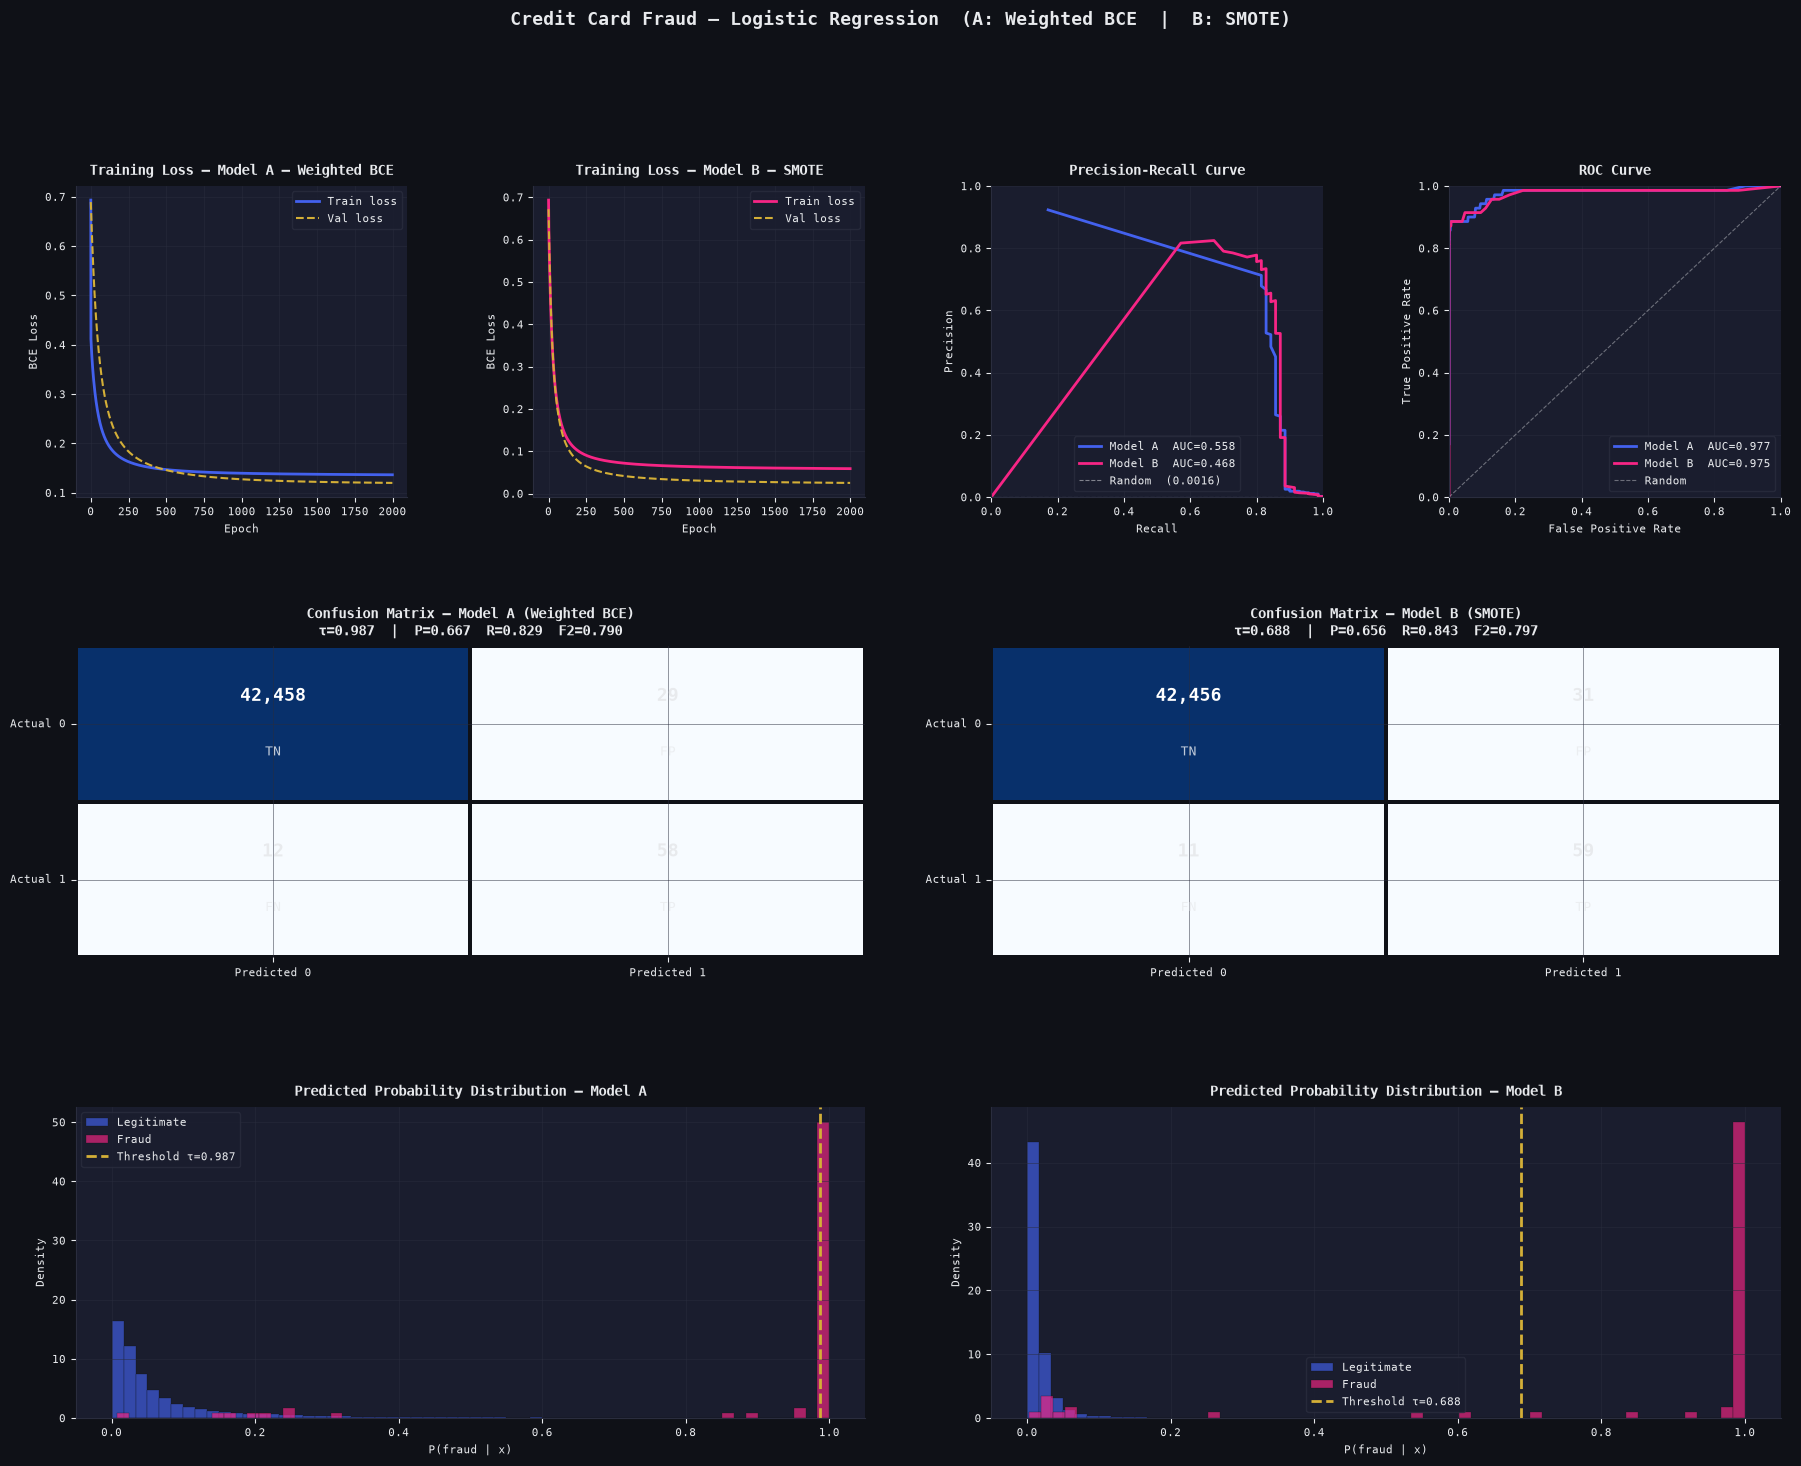


  METRIC                     MODEL A     MODEL B
  Threshold (τ)               0.9867      0.6885  ◀
  Precision                   0.6667      0.6556  ◀
  Recall                      0.8286      0.8429   
  F2-Score                    0.7902      0.7973   
  AUC-PR                      0.5578      0.4682  ◀
  AUC-ROC                     0.9770      0.9749  ◀
  ◀ = better score


In [ ]:
"""
Pipeline:

1.  Load & preprocess
2.  Three-way stratified split (train / val / test)  —  70 / 15 / 15
3.  Z-score normalisation (fit on train only)
4.  SMOTE — from scratch
5.  LogisticRegression class — from scratch
6.  Standalone math functions (sigmoid, BCE, gradient)
7.  Metrics — from scratch
8.  Model A — Weighted BCE loss + early stopping
9.  Model B — SMOTE oversampling + early stopping
10. Threshold optimisation on validation set (F-beta, beta=2)
11. Final evaluation on test set
12. Visualisations
"""

# sklearn aliases for benchmark and verification use only
# From-scratch implementations below reuse these names for their own functions.
# Aliasing here prevents silent shadowing.
from sklearn.metrics import (
    confusion_matrix          as sk_confusion_matrix,
    roc_curve                 as sk_roc_curve,
    precision_recall_curve    as sk_precision_recall_curve,
    classification_report     as sk_classification_report,
    roc_auc_score,
    average_precision_score,
)
from sklearn.dummy import DummyClassifier

# Comparison Libraries
from sklearn.tree     import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost          import XGBClassifier


# ═════════════════════════════════════════════════════════════════════════════
# 1. PREPROCESSING
# ═════════════════════════════════════════════════════════════════════════════

def load_and_preprocess(
    url=(
        "https://raw.githubusercontent.com/nsethi31/"
        "Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
    )
):
    """
    Load the creditcard dataset, drop duplicate rows, apply log1p to Amount,
    then drop Amount (raw) and Time.

    Notes
    -----
    - Duplicates dropped before any split to prevent a row appearing
      in both train and test (data leakage).
    - log1p(Amount): Amount is severely right-skewed (confirmed in EDA).
      log1p used instead of log to handle Amount == 0 safely (log(0) = -inf).
    - Time dropped: it is a recording sequence index spanning a fixed 48-hour
      window. It does not generalise beyond this dataset and showed no
      meaningful class-conditional pattern in EDA that would survive
      normalisation as a linear feature.
    """
    df = pd.read_csv(url)

    # Drop duplicates before splitting
    before = len(df)
    df     = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {before - len(df):,} duplicate rows. "
          f"Remaining: {len(df):,}")

    # Log-transform Amount (EDA confirmed severe right skew)
    df["Amount_log"] = np.log1p(df["Amount"])
    df = df.drop(columns=["Amount", "Time"])

    X = df.drop(columns=["Class"]).values.astype(np.float64)
    y = df["Class"].values.astype(np.float64)
    return X, y


def stratified_split(X, y, test_size=0.15, seed=SEED):
    """
    Two-way stratified split preserving the fraud class ratio in both subsets.

    Called twice in the pipeline to produce a three-way 70 / 15 / 15 split:
        Pass 1: full dataset  → temp (85%)  + test  (15%)
        Pass 2: temp          → train (70%) + val   (15%)

    Without stratification a random split might put zero (or very few)
    fraud cases in a subset by chance, given the 599:1 imbalance.

    Parameters
    ----------
    X, y      : full feature matrix and labels
    test_size : fraction of data to place in the held-out subset
    seed      : RNG seed for reproducibility
    """
    rng     = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    idx_pos = rng.permutation(idx_pos)
    idx_neg = rng.permutation(idx_neg)

    n_pos_test = int(len(idx_pos) * test_size)
    n_neg_test = int(len(idx_neg) * test_size)

    test_idx  = np.concatenate([idx_pos[:n_pos_test],  idx_neg[:n_neg_test]])
    train_idx = np.concatenate([idx_pos[n_pos_test:],  idx_neg[n_neg_test:]])

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def z_score_normalise(X_train, X_val, X_test):
    """
    Fit mean/std on training set only, apply to all three subsets.

    Fitting on val or test would constitute data leakage — the scaler
    would embed information about held-out distributions into the
    training pipeline. All three sets are transformed using mu and sigma
    computed exclusively from X_train.

    Returns
    -------
    X_train_n, X_val_n, X_test_n : normalised arrays
    mu, sigma                     : training statistics (for inspection)
    """
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0) + 1e-8   # epsilon prevents division by zero
    return (
        (X_train - mu) / sigma,
        (X_val   - mu) / sigma,
        (X_test  - mu) / sigma,
        mu, sigma
    )


# ═════════════════════════════════════════════════════════════════════════════
# 2. STANDALONE MATH FUNCTIONS
#    Called by LogisticRegression and gradient_check independently.
# ═════════════════════════════════════════════════════════════════════════════

def sigmoid(z):
    """
    Numerically stable sigmoid.

    Naive: 1 / (1 + exp(-z)) overflows when z << 0 because exp(-z) → inf.
    Fix: clip z to [-500, 500] before exponentiation. Outside this range
    the sigmoid value is indistinguishable from 0 or 1 in float64.
    """
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y_true, y_pred, sample_weights=None):
    """
    Binary cross-entropy loss with epsilon guard against log(0).

        L = -(1/m) Σ [ y·log(p) + (1-y)·log(1-p) ]

    If p == 0 and y == 1: log(0) = -inf → nan
    If p == 1 and y == 0: log(0) = -inf → nan
    Fix: clip predictions to [eps, 1-eps] with eps = 1e-15.
    """
    eps    = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    per_sample = -(y_true * np.log(y_pred) +
                   (1 - y_true) * np.log(1 - y_pred))

    if sample_weights is not None:
        return np.mean(sample_weights * per_sample)
    return np.mean(per_sample)


def compute_gradient(X, y_true, y_pred, sample_weights=None):
    """
    Gradient of binary cross-entropy w.r.t. weight vector w.

    Standard:       dL/dw = (1/N) · Xᵀ · (ŷ - y)
    Weighted:       dL/dw = (1/N) · Xᵀ · (c ⊙ (ŷ - y))

    This single vector covers both the bias term (w[0]) and feature
    weights (w[1:]) when a bias column is prepended to X.
    """
    N     = X.shape[0]
    error = y_pred - y_true

    if sample_weights is not None:
        error = sample_weights * error

    return (1 / N) * (X.T @ error)


# ═════════════════════════════════════════════════════════════════════════════
# 3. GRADIENT CHECK
#    Before any training, the analytic gradient is verified against a
#    numerical finite-difference approximation.
#    Relative error < 1e-5 confirms the math is correct.
#    Training does not proceed until this passes.
# ═════════════════════════════════════════════════════════════════════════════

def gradient_check(X, y, w, sample_weights=None, eps=1e-5):
    """
    Compare analytic gradient to numerical gradient via finite differences.

    Numerical gradient:
        dL/dw_i ≈ [L(w + eps·eᵢ) - L(w - eps·eᵢ)] / (2·eps)

    Relative error < 1e-5 confirms implementation is correct.
    Do not proceed to training until this passes.
    """
    y_pred         = sigmoid(X @ w)
    analytic_grad  = compute_gradient(X, y, y_pred, sample_weights)
    numerical_grad = np.zeros_like(w)

    for i in range(len(w)):
        w_plus        = w.copy(); w_plus[i]  += eps
        w_minus       = w.copy(); w_minus[i] -= eps
        loss_plus     = binary_cross_entropy(y, sigmoid(X @ w_plus),  sample_weights)
        loss_minus    = binary_cross_entropy(y, sigmoid(X @ w_minus), sample_weights)
        numerical_grad[i] = (loss_plus - loss_minus) / (2 * eps)

    diff           = np.linalg.norm(analytic_grad - numerical_grad)
    denom          = (np.linalg.norm(analytic_grad) +
                      np.linalg.norm(numerical_grad))
    relative_error = diff / (denom + 1e-15)

    print(f"Relative gradient error: {relative_error:.2e}")
    if relative_error < 1e-5:
        print("Gradient check PASSED ✓")
    else:
        print("Gradient check FAILED ✗ — review gradient implementation.")
    return relative_error


# ═════════════════════════════════════════════════════════════════════════════
# 4. SMOTE
# ═════════════════════════════════════════════════════════════════════════════

def smote(X, y, target_ratio=0.1, k=5, seed=SEED):
    """
    Synthetic Minority Oversampling Technique.

    For each minority (fraud) sample, finds its k nearest fraud neighbours,
    picks one at random, and linearly interpolates between them:

        x_new = xᵢ + λ · (x_nn - xᵢ),   λ ~ U(0, 1)

    Parameters
    ----------
    X            : normalised feature matrix (bias column NOT prepended)
    y            : binary labels
    target_ratio : desired fraud / (fraud + legitimate) ratio after oversampling
    k            : number of nearest neighbours (default 5 — standard SMOTE)

    Notes
    -----
    - Applied to X_train ONLY, after splitting and normalisation.
    - Synthetic points must never appear in val or test — evaluation
      must reflect real transaction distributions.
    - Normalise before calling: without normalisation, Amount_log
      (range 0–10) would dominate Euclidean distance and V1–V28
      would be effectively invisible to the kNN computation.
    """
    rng      = np.random.default_rng(seed)
    X_min    = X[y == 1]
    X_maj    = X[y == 0]
    n_maj    = len(X_maj)
    n_min    = len(X_min)
    n_needed = int(n_maj * target_ratio) - n_min

    if n_needed <= 0:
        print("  SMOTE: target ratio already satisfied — no samples generated.")
        return X, y

    # Pairwise squared Euclidean distance — pure NumPy
    # ||a - b||² = ||a||² + ||b||² - 2·a·bᵀ
    sq_a  = np.sum(X_min ** 2, axis=1, keepdims=True)     # (n_min, 1)
    sq_b  = np.sum(X_min ** 2, axis=1, keepdims=True).T   # (1, n_min)
    dists = sq_a + sq_b - 2 * (X_min @ X_min.T)           # (n_min, n_min)
    dists = np.maximum(dists, 0)                           # numerical safety

    # Skip index 0 (self), take next k neighbours
    nn_idx = np.argsort(dists, axis=1)[:, 1:k + 1]        # (n_min, k)

    synthetics = []
    for _ in range(n_needed):
        i     = rng.integers(0, n_min)
        nn    = nn_idx[i, rng.integers(0, k)]
        lam   = rng.uniform(0, 1)
        x_new = X_min[i] + lam * (X_min[nn] - X_min[i])
        synthetics.append(x_new)

    X_syn = np.vstack(synthetics)
    y_syn = np.ones(n_needed)
    X_bal = np.vstack([X, X_syn])
    y_bal = np.concatenate([y, y_syn])

    perm = rng.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]


# ═════════════════════════════════════════════════════════════════════════════
# 5. LOGISTIC REGRESSION — from scratch
# ═════════════════════════════════════════════════════════════════════════════

class LogisticRegression:
    """
    Binary logistic regression trained with gradient descent.

    Architecture
    ------------
    - Bias folded into weight vector via a prepended ones column.
      w[0] = bias,  w[1:] = feature weights.
    - Delegates to standalone sigmoid(), binary_cross_entropy(), and
      compute_gradient() — no duplicated math inside the class.
    - Two imbalance strategies:
        Model A — class_weight='balanced': assigns each fraud sample
                  ~300× the gradient weight of a legitimate sample.
        Model B — class_weight=None: trains on SMOTE-augmented data
                  with standard unweighted loss.
    - Early stopping monitors UNWEIGHTED validation loss.
      Rationale: weighted loss reflects the artificial cost structure
      used during training, not true generalisation. Unweighted val
      loss is a cleaner signal of performance on the real distribution.

    Forward pass  :  ŷ = σ([1|X] · w)
    Weighted BCE  :  L = -(1/m) Σ cᵢ·[yᵢ·log(ŷᵢ) + (1-yᵢ)·log(1-ŷᵢ)]
    Gradient      :  dL/dw = (1/m) · [1|X]ᵀ · (c ⊙ (ŷ - y))
    """

    def __init__(self, learning_rate=0.1, n_iterations=2000,
                 class_weight=None, patience=30):
        """
        Parameters
        ----------
        learning_rate : float
            Step size for gradient descent.
        n_iterations  : int
            Maximum number of training epochs.
        class_weight  : None | 'balanced'
            'balanced' computes cᵢ = m / (2 · mₖ) automatically.
        patience      : int
            Early stopping — halt if val loss does not improve for
            this many consecutive epochs. Requires X_val/y_val in fit().
        """
        self.lr                = learning_rate
        self.n_iter            = n_iterations
        self.class_weight      = class_weight
        self.patience          = patience
        self.weights           = None
        self.loss_history      = []
        self.val_loss_history  = []
        self.grad_norm_history = []

    @staticmethod
    def _add_bias(X):
        """Prepend a column of ones — w[0] acts as the bias term.
        Keeps bias unified with weights in a single vector, simplifying
        all gradient operations. w[0] = bias, w[1:] = feature weights.
        """
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _sample_weights(self, y):
        """
        Build per-sample weight vector c.

        'balanced' weights each class inversely proportional to frequency:
            w0 = m / (2 · m_legit)   — legitimate class weight
            w1 = m / (2 · m_fraud)   — fraud class weight (~300×)
        This counteracts the ~599:1 class imbalance in gradient updates.
        """
        if self.class_weight == "balanced":
            m  = len(y)
            m0 = np.sum(y == 0)
            m1 = np.sum(y == 1)
            w0 = m / (2 * m0)
            w1 = m / (2 * m1)
            c  = np.where(y == 1, w1, w0)
            return c, w0, w1
        return np.ones(len(y)), 1.0, 1.0

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Train via gradient descent with optional early stopping.

        Parameters
        ----------
        X, y         : training data (without bias column)
        X_val, y_val : validation data for early stopping and loss tracking.
                       If not provided, trains for n_iterations epochs.

        Returns
        -------
        self : fitted model with best weights restored if early stopping fired.
        """
        X    = self._add_bias(X)
        m, n = X.shape

        self.weights           = np.zeros(n)
        self.loss_history      = []
        self.val_loss_history  = []
        self.grad_norm_history = []

        c, self.w0, self.w1 = self._sample_weights(y)

        best_val_loss     = np.inf
        best_weights      = self.weights.copy()
        epochs_no_improve = 0
        do_early_stop     = (X_val is not None and y_val is not None)

        if do_early_stop:
            X_val_b = self._add_bias(X_val)

        for epoch in range(self.n_iter):
            # Forward pass
            y_hat = sigmoid(X @ self.weights)

            # Loss (weighted for gradient; stored for tracking)
            train_loss = binary_cross_entropy(y, y_hat, sample_weights=c)

            # Gradient
            grad = compute_gradient(X, y, y_hat, sample_weights=c)

            # Parameter update
            self.weights -= self.lr * grad

            # Tracking
            grad_norm = np.linalg.norm(grad)
            self.loss_history.append(train_loss)
            self.grad_norm_history.append(grad_norm)

            # Validation + early stopping
            # Val loss is intentionally UNWEIGHTED — it measures true
            # generalisation on the real class distribution, not the
            # artificially reweighted training objective.
            if do_early_stop:
                y_val_hat = sigmoid(X_val_b @ self.weights)
                val_loss  = binary_cross_entropy(y_val, y_val_hat)
                self.val_loss_history.append(val_loss)

                if val_loss < best_val_loss:
                    best_val_loss     = val_loss
                    best_weights      = self.weights.copy()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= self.patience:
                    print(f"Early stopping at epoch {epoch + 1}. "
                          f"Best val loss: {best_val_loss:.6f}")
                    break

            if (epoch + 1) % 100 == 0:
                val_str = (f" | val loss: {self.val_loss_history[-1]:.6f}"
                           if do_early_stop else "")
                print(f"Epoch {epoch + 1:4d} | "
                      f"train loss: {train_loss:.6f}"
                      f"{val_str} | "
                      f"grad norm: {grad_norm:.6f}")

        if do_early_stop:
            self.weights = best_weights
            print(f"\nTraining complete. Best val loss: {best_val_loss:.6f}")

        return self

    def predict_proba(self, X):
        """Return P(fraud | x) for each sample. X without bias column."""
        return sigmoid(self._add_bias(X) @ self.weights)

    def predict(self, X, threshold=0.5):
        """Return binary predictions at a given threshold."""
        return (self.predict_proba(X) >= threshold).astype(int)


# ═════════════════════════════════════════════════════════════════════════════
# 6. METRICS — from scratch
# ═════════════════════════════════════════════════════════════════════════════

def confusion_matrix(y_true, y_pred):
    """From-scratch confusion matrix. Returns [[TN, FP], [FN, TP]]."""
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return np.array([[tn, fp], [fn, tp]])


def precision_recall_f1(y_true, y_pred, beta=1.0):
    """Precision, Recall, and F-beta score for the positive (fraud) class."""
    tp   = np.sum((y_true == 1) & (y_pred == 1))
    fp   = np.sum((y_true == 0) & (y_pred == 1))
    fn   = np.sum((y_true == 1) & (y_pred == 0))
    prec = tp / (tp + fp + 1e-15)
    rec  = tp / (tp + fn + 1e-15)
    fb   = ((1 + beta ** 2) * prec * rec /
            (beta ** 2 * prec + rec + 1e-15))
    return prec, rec, fb


def pr_curve(y_true, y_scores, n_thresholds=300):
    """Precision-Recall curve by sweeping threshold."""
    thresholds          = np.linspace(0, 1, n_thresholds)
    precisions, recalls = [], []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        p, r, _ = precision_recall_f1(y_true, y_pred)
        precisions.append(p)
        recalls.append(r)
    return np.array(recalls), np.array(precisions), thresholds


def roc_curve(y_true, y_scores, n_thresholds=300):
    """ROC curve — TPR vs FPR by sweeping threshold."""
    thresholds = np.linspace(0, 1, n_thresholds)
    tprs, fprs = [], []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tprs.append(tp / (tp + fn + 1e-15))
        fprs.append(fp / (fp + tn + 1e-15))
    return np.array(fprs), np.array(tprs)


def auc_trapezoidal(x, y):
    """AUC via trapezoidal rule — no scipy."""
    order = np.argsort(x)
    x, y  = x[order], y[order]
    return float(np.trapezoid(y, x)) 


def find_optimal_threshold(y_true, y_scores, beta=2.0, n_thresholds=300):
    """
    Return threshold maximising F-beta on the fraud class.

    beta=2 weights recall twice as heavily as precision, reflecting the
    asymmetric cost of missing fraud vs raising false alarms.

    IMPORTANT: always call with validation labels (y_val), never y_test.
    Tuning τ on y_test leaks the test distribution into model selection.
    """
    thresholds      = np.linspace(0.01, 0.99, n_thresholds)
    best_t, best_fb = 0.5, 0.0
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        _, _, fb = precision_recall_f1(y_true, y_pred, beta=beta)
        if fb > best_fb:
            best_fb = fb
            best_t  = t
    return best_t, best_fb


# ═════════════════════════════════════════════════════════════════════════════
# 7. RUN PIPELINE
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("Loading data...")
X, y = load_and_preprocess()
print(f"Dataset shape : {X.shape}")
print(f"Fraud rate    : {y.mean():.4%}")

# Feature vector composition — post-preprocessing
# Each sample x ∈ ℝ²⁹:
#   x[0:28]  — V1–V28      PCA components, orthogonal by construction,
#                           anonymous (no business interpretation)
#   x[28]    — Amount_log  log1p(Amount), right-skew corrected
#
#   Bias prepended inside LogisticRegression._add_bias() giving
#   augmented vector x̃ ∈ ℝ³⁰ during training.
#   Target: y ∈ {0, 1}  — 0 = legitimate, 1 = fraud

# Three-way stratified split — 70 / 15 / 15
# Pass 1: carve out 15% test from full dataset
# Pass 2: carve out 15/85 ≈ 17.65% val from remaining 85%
# Result: train ≈ 70%, val ≈ 15%, test ≈ 15% of total
print("\nSplitting (stratified, three-way 70/15/15)...")
X_temp,  X_test,  y_temp,  y_test  = stratified_split(X,      y,
                                                        test_size=0.15)
X_train, X_val,   y_train, y_val   = stratified_split(X_temp, y_temp,
                                                        test_size=round(0.15 / 0.85, 6))

print(f"\n  Train : {X_train.shape}  | fraud rate: {y_train.mean():.4%}")
print(f"  Val   : {X_val.shape}    | fraud rate: {y_val.mean():.4%}")
print(f"  Test  : {X_test.shape}   | fraud rate: {y_test.mean():.4%}")

# Verify fraud rate is preserved across all splits
expected = y.mean()
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    actual = y_split.mean()
    drift  = abs(actual - expected)
    status = "✓" if drift < 0.001 else "WARNING ✗"
    print(f"  {name} fraud rate: {actual:.4%}  (drift={drift:.5f})  {status}")

# ── Normalisation ─────────────────────────────────────────────────────────────
print("\nNormalising (fit on train only)...")
X_train_n, X_val_n, X_test_n, mu, sigma = z_score_normalise(
    X_train, X_val, X_test
)

# ── Gradient check ────────────────────────────────────────────────────────────
print("\nRunning gradient check on 200-sample subset...")
rng_check = np.random.default_rng(SEED)
subset    = rng_check.choice(len(X_train_n), 200, replace=False)
X_check   = np.hstack([np.ones((200, 1)), X_train_n[subset]])
w_check   = np.zeros(X_check.shape[1])
gradient_check(X_check, y_train[subset], w_check)

# ── Class weights (for reference and Model A) ─────────────────────────────────
n_total = len(y_train)
n_fraud = y_train.sum()
n_legit = n_total - n_fraud
w1      = n_total / (2 * n_fraud)
w0      = n_total / (2 * n_legit)
print(f"\nClass weights — w1 (fraud): {w1:.2f} | w0 (legit): {w0:.4f}")

# ── Model A — Weighted BCE + early stopping ───────────────────────────────────
print("\n" + "─" * 60)
print("Training Model A (Weighted BCE + early stopping)...")
model_A = LogisticRegression(
    learning_rate=0.1,
    n_iterations=2000,
    class_weight="balanced",
    patience=30
)
model_A.fit(X_train_n, y_train, X_val=X_val_n, y_val=y_val)

# Threshold optimisation — validation set only
# Sweep τ from 0.01 → 0.99, score each with F2, pick the best.
# F2 weights recall twice as heavily as precision (β=2).
# Val set used — never test set (tuning τ on test leaks distribution).
proba_A_val             = model_A.predict_proba(X_val_n)
thresh_A, best_f2_val_A = find_optimal_threshold(y_val, proba_A_val, beta=2.0)

# Final evaluation — test set touched once
proba_A              = model_A.predict_proba(X_test_n)
y_pred_A             = model_A.predict(X_test_n, threshold=thresh_A)
prec_A, rec_A, f2_A  = precision_recall_f1(y_test, y_pred_A, beta=2.0)
cm_A                 = confusion_matrix(y_test, y_pred_A)
recalls_A, precisions_A, _ = pr_curve(y_test, proba_A)
fprs_A, tprs_A             = roc_curve(y_test, proba_A)
auc_pr_A             = auc_trapezoidal(recalls_A, precisions_A)
auc_roc_A            = auc_trapezoidal(fprs_A, tprs_A)

print(f"\n  Optimal threshold : {thresh_A:.3f}")
print(f"  Precision         : {prec_A:.4f}")
print(f"  Recall            : {rec_A:.4f}")
print(f"  F2-Score          : {f2_A:.4f}")
print(f"  AUC-PR            : {auc_pr_A:.4f}")
print(f"  AUC-ROC           : {auc_roc_A:.4f}")

# ── Model B — SMOTE + early stopping ─────────────────────────────────────────
print("\n" + "─" * 60)
print("Generating SMOTE samples (training set only)...")
X_smote, y_smote = smote(X_train_n, y_train, target_ratio=0.1, k=5)
n_syn = int(y_smote.sum()) - int(y_train.sum())
print(f"  Original fraud samples  : {int(y_train.sum()):,}")
print(f"  Synthetic samples added : {n_syn:,}")
print(f"  New fraud total         : {int(y_smote.sum()):,}")
print(f"  New fraud rate          : {y_smote.mean():.4%}")

print("\nTraining Model B (SMOTE + early stopping)...")
model_B = LogisticRegression(
    learning_rate=0.1,
    n_iterations=2000,
    class_weight=None,
    patience=30
)
model_B.fit(X_smote, y_smote, X_val=X_val_n, y_val=y_val)

# Threshold optimisation — same procedure as Model A
# The optimal τ for B may differ from A: SMOTE shapes the decision boundary
# via rebalanced training data rather than reweighted loss, shifting the
# model's probability outputs. Comparing optimal thresholds is informative.
proba_B_val             = model_B.predict_proba(X_val_n)
thresh_B, best_f2_val_B = find_optimal_threshold(y_val, proba_B_val, beta=2.0)

# Final evaluation — test set touched once
proba_B              = model_B.predict_proba(X_test_n)
y_pred_B             = model_B.predict(X_test_n, threshold=thresh_B)
prec_B, rec_B, f2_B  = precision_recall_f1(y_test, y_pred_B, beta=2.0)
cm_B                 = confusion_matrix(y_test, y_pred_B)
recalls_B, precisions_B, _ = pr_curve(y_test, proba_B)
fprs_B, tprs_B             = roc_curve(y_test, proba_B)
auc_pr_B             = auc_trapezoidal(recalls_B, precisions_B)
auc_roc_B            = auc_trapezoidal(fprs_B, tprs_B)

print(f"\n  Optimal threshold : {thresh_B:.3f}")
print(f"  Precision         : {prec_B:.4f}")
print(f"  Recall            : {rec_B:.4f}")
print(f"  F2-Score          : {f2_B:.4f}")
print(f"  AUC-PR            : {auc_pr_B:.4f}")
print(f"  AUC-ROC           : {auc_roc_B:.4f}")


# ══════════════════════════════════════════════════════════════════
# MODEL COMPARISON
# Decision Tree / Random Forest / XGBoost / sklearn LogisticRegression
#
# Purpose: benchmark from-scratch logistic regression against
# tree-based models and sklearn's implementation to quantify:
#   (a) the cost of the linear boundary assumption
#   (b) correctness of the from-scratch implementation vs sklearn LR
#
# All models:
#   - Trained on X_train_n (same normalised features)
#   - Threshold optimised on validation set (F2, β=2)
#   - Evaluated on test set — touched once
# ══════════════════════════════════════════════════════════════════

print("=" * 56)
print("  BENCHMARK MODEL COMPARISON")
print("=" * 56)

# Decision Tree ─────────────────────────────────────────────────────────────
print("\nTraining Decision Tree...")
dt = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=SEED
)
dt.fit(X_train_n, y_train)

# Random Forest ─────────────────────────────────────────────────────────────
print("Training Random Forest (n_jobs=-1 uses all cores)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_n, y_train)

# XGBoost ───────────────────────────────────────────────────────────────────
# scale_pos_weight: equivalent to w1/w0 class weighting in XGBoost.
# Rounded rather than truncated — int() would understate the imbalance.
print("Training XGBoost...")
scale_pos_weight = round((y_train == 0).sum() / (y_train == 1).sum())
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="aucpr",
    early_stopping_rounds=20,
    verbosity=0
)
xgb.fit(
    X_train_n, y_train,
    eval_set=[(X_val_n, y_val)],
    verbose=False
)

# sklearn Logistic Regression ───────────────────────────────────────────────
# Benchmark against the from-scratch implementation.
# class_weight='balanced' mirrors Model A's weighting strategy.
# max_iter=2000 matches the from-scratch model's maximum epochs.
print("Training sklearn LogisticRegression...")
sk_lr = SklearnLR(
    class_weight="balanced",
    max_iter=2000,
    random_state=SEED,
    solver="lbfgs"
)
sk_lr.fit(X_train_n, y_train)

# Threshold optimisation — validation set only ──────────────────────────────
print("\nOptimising thresholds on validation set (F2, β=2)...")
proba_dt_val   = dt.predict_proba(X_val_n)[:, 1]
proba_rf_val   = rf.predict_proba(X_val_n)[:, 1]
proba_xgb_val  = xgb.predict_proba(X_val_n)[:, 1]
proba_sklr_val = sk_lr.predict_proba(X_val_n)[:, 1]

thresh_dt,   _ = find_optimal_threshold(y_val, proba_dt_val,   beta=2.0)
thresh_rf,   _ = find_optimal_threshold(y_val, proba_rf_val,   beta=2.0)
thresh_xgb,  _ = find_optimal_threshold(y_val, proba_xgb_val,  beta=2.0)
thresh_sklr, _ = find_optimal_threshold(y_val, proba_sklr_val, beta=2.0)

# Final evaluation on test set ──────────────────────────────────────────────
# Compute PR and ROC curves once per model and store in results dict
# to avoid redundant recomputation during visualisation.
model_specs = [
    ("LR A (from scratch)", proba_A,                             thresh_A),
    ("LR B (from scratch)", proba_B,                             thresh_B),
    ("sklearn LR",          sk_lr.predict_proba(X_test_n)[:, 1], thresh_sklr),
    ("Decision Tree",       dt.predict_proba(X_test_n)[:, 1],    thresh_dt),
    ("Random Forest",       rf.predict_proba(X_test_n)[:, 1],    thresh_rf),
    ("XGBoost",             xgb.predict_proba(X_test_n)[:, 1],   thresh_xgb),
]

results = []
for name, proba, thresh in model_specs:
    y_pred             = (proba >= thresh).astype(int)
    prec, rec, f2      = precision_recall_f1(y_test, y_pred, beta=2.0)
    recs_m, precs_m, _ = pr_curve(y_test, proba)
    fprs_m, tprs_m     = roc_curve(y_test, proba)
    auc_pr_m           = auc_trapezoidal(recs_m, precs_m)
    auc_roc_m          = auc_trapezoidal(fprs_m, tprs_m)
    cm_m               = confusion_matrix(y_test, y_pred)
    tp                 = cm_m[1, 1]
    fn                 = cm_m[1, 0]
    fp                 = cm_m[0, 1]
    results.append(dict(
        name=name, thresh=thresh,
        prec=prec, rec=rec, f2=f2,
        auc_roc=auc_roc_m, auc_pr=auc_pr_m,
        tp=tp, fn=fn, fp=fp,
        proba=proba,
        recs=recs_m, precs=precs_m,
        fprs=fprs_m, tprs=tprs_m,
    ))

# Print comparison table ────────────────────────────────────────────────────
print("\n" + "=" * 84)
print(f"  {'MODEL':<22} {'τ':>6} {'PREC':>8} {'REC':>8} "
      f"{'F2':>8} {'AUC-PR':>8} {'AUC-ROC':>8} {'TP':>5} {'FN':>5} {'FP':>6}")
print("=" * 84)
for r in results:
    print(f"  {r['name']:<22} {r['thresh']:>6.3f} {r['prec']:>8.4f} "
          f"{r['rec']:>8.4f} {r['f2']:>8.4f} {r['auc_pr']:>8.4f} "
          f"{r['auc_roc']:>8.4f} {r['tp']:>5} {r['fn']:>5} {r['fp']:>6}")
print("=" * 84)
print("  Primary metric: AUC-PR — most informative under class imbalance.")
print("  AUC-ROC included as secondary — can be deceptively optimistic")
print("  due to the abundance of true negatives at 599:1 imbalance.")
print("  sklearn LR included to validate the from-scratch implementation.")
print("=" * 84)

# From-scratch vs sklearn LR sanity check ───────────────────────────────────
sk_result  = next(r for r in results if r["name"] == "sklearn LR")
our_result = next(r for r in results if r["name"] == "LR A (from scratch)")

print("\n" + "=" * 56)
print("  SANITY CHECK — From-Scratch LR A vs sklearn LR")
print("=" * 56)
print(f"  {'METRIC':<22} {'Ours':>10} {'sklearn':>10}")
print("-" * 56)
print(f"  {'AUC-ROC':<22} {our_result['auc_roc']:>10.4f} {sk_result['auc_roc']:>10.4f}")
print(f"  {'AUC-PR':<22} {our_result['auc_pr']:>10.4f}  {sk_result['auc_pr']:>10.4f}")
print(f"  {'F2-Score':<22} {our_result['f2']:>10.4f}  {sk_result['f2']:>10.4f}")
print("=" * 56)
print("  Small differences expected — sklearn uses L-BFGS")
print("  (second-order optimiser) vs our first-order gradient descent.")
print("  Large differences would indicate an implementation bug.")
print("=" * 56)

# Visual comparison ─────────────────────────────────────────────────────────
colors_map = {
    "LR A (from scratch)" : C0,
    "LR B (from scratch)" : C1,
    "sklearn LR"          : TEAL,
    "Decision Tree"       : "#7209B7",
    "Random Forest"       : GOLD,
    "XGBoost"             : "#B5179E",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Model Comparison — From-Scratch LR vs Benchmarks",
    color=FG, fontsize=13, fontweight="bold"
)

# PR curves — pre-computed, no redundant recomputation
for r in results:
    axes[0].plot(r["recs"], r["precs"],
                 color=colors_map[r["name"]], lw=2,
                 label=f"{r['name']}  ({r['auc_pr']:.3f})")
baseline = y_test.mean()
axes[0].axhline(baseline, color=FG, lw=0.8, ls="--", alpha=0.4,
                label=f"Random ({baseline:.4f})")
style(axes[0], "Precision-Recall Curves", "Recall", "Precision")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=7)

# ROC curves
for r in results:
    axes[1].plot(r["fprs"], r["tprs"],
                 color=colors_map[r["name"]], lw=2,
                 label=f"{r['name']}  ({r['auc_roc']:.3f})")
axes[1].plot([0, 1], [0, 1], color=FG, lw=0.8, ls="--", alpha=0.4,
             label="Random")
style(axes[1], "ROC Curves", "False Positive Rate", "True Positive Rate")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=7)

# F2 bar chart
names  = [r["name"] for r in results]
f2s    = [r["f2"]   for r in results]
colors = [colors_map[n] for n in names]
axes[2].barh(names, f2s, color=colors, edgecolor=BG,
             height=0.6, alpha=0.85)
for i, val in enumerate(f2s):
    axes[2].text(val + 0.005, i, f"{val:.4f}",
                 va="center", color=FG, fontsize=8)
axes[2].set_xlim(0, max(f2s) * 1.15)
style(axes[2], "F2-Score Comparison (β=2)", "F2-Score", "")

plt.tight_layout()
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# 8. VISUALISATIONS
# ═════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 16))
fig.suptitle(
    "Credit Card Fraud — Logistic Regression  "
    "(A: Weighted BCE  |  B: SMOTE)",
    color=FG, fontsize=13, fontweight="bold", y=0.99
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)

ax_loss_A = fig.add_subplot(gs[0, 0])
ax_loss_B = fig.add_subplot(gs[0, 1])
ax_pr     = fig.add_subplot(gs[0, 2])
ax_roc    = fig.add_subplot(gs[0, 3])
ax_cm_A   = fig.add_subplot(gs[1, 0:2])
ax_cm_B   = fig.add_subplot(gs[1, 2:4])
ax_prob_A = fig.add_subplot(gs[2, 0:2])
ax_prob_B = fig.add_subplot(gs[2, 2:4])

# Loss curves ───────────────────────────────────────────────────────────────
for ax, model, label, color in [
    (ax_loss_A, model_A, "Model A — Weighted BCE", C0),
    (ax_loss_B, model_B, "Model B — SMOTE",        C1),
]:
    ax.plot(model.loss_history,     color=color, lw=2,   label="Train loss")
    ax.plot(model.val_loss_history, color=GOLD,  lw=1.5,
            ls="--", label="Val loss")
    style(ax, f"Training Loss — {label}", "Epoch", "BCE Loss")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

# Precision-Recall curves ───────────────────────────────────────────────────
baseline = y_test.mean()
ax_pr.plot(recalls_A, precisions_A, color=C0, lw=2,
           label=f"Model A  AUC={auc_pr_A:.3f}")
ax_pr.plot(recalls_B, precisions_B, color=C1, lw=2,
           label=f"Model B  AUC={auc_pr_B:.3f}")
ax_pr.axhline(baseline, color=FG, lw=0.8, ls="--", alpha=0.5,
              label=f"Random  ({baseline:.4f})")
style(ax_pr, "Precision-Recall Curve", "Recall", "Precision")
ax_pr.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1)

# ROC curves ────────────────────────────────────────────────────────────────
ax_roc.plot(fprs_A, tprs_A, color=C0, lw=2,
            label=f"Model A  AUC={auc_roc_A:.3f}")
ax_roc.plot(fprs_B, tprs_B, color=C1, lw=2,
            label=f"Model B  AUC={auc_roc_B:.3f}")
ax_roc.plot([0, 1], [0, 1], color=FG, lw=0.8, ls="--", alpha=0.4,
            label="Random")
style(ax_roc, "ROC Curve", "False Positive Rate", "True Positive Rate")
ax_roc.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)

# Confusion matrices ────────────────────────────────────────────────────────
def plot_cm(ax, cm, title, thresh, prec, rec, f2):
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    sns.heatmap(cm, annot=False, ax=ax, cmap="Blues",
                linewidths=1.5, linecolor=BG, cbar=False,
                vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            val   = cm[i, j]
            color = "white" if val > cm.max() * 0.5 else FG
            ax.text(j + 0.5, i + 0.32, f"{val:,}",
                    ha="center", va="center",
                    color=color, fontsize=13, fontweight="bold")
            ax.text(j + 0.5, i + 0.68, cell_labels[i][j],
                    ha="center", va="center",
                    color=color, fontsize=9, alpha=0.75)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(["Predicted 0", "Predicted 1"], color=FG, fontsize=9)
    ax.set_yticklabels(["Actual 0",    "Actual 1"],    color=FG, fontsize=9,
                       rotation=0)
    style(ax, f"{title}\nτ={thresh:.3f}  |  P={prec:.3f}  "
              f"R={rec:.3f}  F2={f2:.3f}")

plot_cm(ax_cm_A, cm_A,
        "Confusion Matrix — Model A (Weighted BCE)",
        thresh_A, prec_A, rec_A, f2_A)
plot_cm(ax_cm_B, cm_B,
        "Confusion Matrix — Model B (SMOTE)",
        thresh_B, prec_B, rec_B, f2_B)

# Predicted probability distributions ──────────────────────────────────────
def plot_prob_dist(ax, proba, y_true, thresh, title):
    for cls, color, label in [(0, C0, "Legitimate"), (1, C1, "Fraud")]:
        mask = y_true == cls
        ax.hist(proba[mask], bins=60, color=color, alpha=0.65,
                label=label, edgecolor=BG, linewidth=0.3, density=True)
    ax.axvline(thresh, color=GOLD, lw=2, ls="--",
               label=f"Threshold τ={thresh:.3f}")
    style(ax, title, "P(fraud | x)", "Density")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

plot_prob_dist(ax_prob_A, proba_A, y_test, thresh_A,
               "Predicted Probability Distribution — Model A")
plot_prob_dist(ax_prob_B, proba_B, y_test, thresh_B,
               "Predicted Probability Distribution — Model B")

plt.tight_layout()
plt.show()

# Final comparison table ────────────────────────────────────────────────────
print("\n" + "=" * 58)
print(f"  {'METRIC':<22}  {'MODEL A':>10}  {'MODEL B':>10}")
print("=" * 58)
metrics = [
    ("Threshold (τ)", thresh_A,  thresh_B),
    ("Precision",     prec_A,    prec_B),
    ("Recall",        rec_A,     rec_B),
    ("F2-Score",      f2_A,      f2_B),
    ("AUC-PR",        auc_pr_A,  auc_pr_B),
    ("AUC-ROC",       auc_roc_A, auc_roc_B),
]
for name, a, b in metrics:
    winner = "◀" if a >= b else " "
    print(f"  {name:<22}  {a:>10.4f}  {b:>10.4f}  {winner}")
print("=" * 58)
print("  ◀ = better score")

# Model Implementation Notes

## Overview

The pipeline implements binary logistic regression from scratch to detect fraudulent credit card transactions. All core components — sigmoid, loss, gradient, SMOTE, metrics, and threshold optimisation — are hand-derived and hand-coded. Sklearn and XGBoost appear only as benchmarks and sanity checks, never in the primary training path.

**Pipeline stages:**

1. Load & preprocess
2. Three-way stratified split — 70 / 15 / 15
3. Z-score normalisation — fit on train only
4. Gradient check — verifies math before training begins
5. Model A — Weighted BCE + early stopping
6. Model B — SMOTE + early stopping
7. Threshold optimisation on validation set ($F_2$, $\beta = 2$)
8. Benchmark comparison — Decision Tree, Random Forest, XGBoost, sklearn LR
9. Final evaluation on test set — touched once
10. Visualisations

---

## 1. Preprocessing — `load_and_preprocess()`

### Duplicate Removal

```python
df = df.drop_duplicates().reset_index(drop=True)
```

Duplicates are removed **before any split**. If a duplicate row survived into both train and test, the model would be evaluated on data it had already seen — a form of data leakage that inflates test performance. Removing first guarantees a clean separation.

### Feature Engineering

```python
df["Amount_log"] = np.log1p(df["Amount"])
df = df.drop(columns=["Amount", "Time"])
```

**`log1p(Amount)`** — EDA confirmed raw `Amount` has skewness = 16.98. The transformation reduces this to 0.16 (99% reduction), compressing extreme outliers into a range comparable to the PCA components. `log1p` is used instead of `log` to safely handle `Amount == 0` — `log(0) = -inf`.

**`Time` dropped** — Time is a recording sequence index spanning a fixed 48-hour window. It showed no meaningful class-conditional pattern in EDA that would survive Z-score normalisation as a raw linear feature. Including it would add noise without signal.

**`Amount` (raw) dropped** — superseded by `Amount_log`. Keeping both would introduce redundancy and re-introduce the scale problem that `log1p` was applied to solve.

### Feature Matrix

Post-preprocessing, each sample $\mathbf{x} \in \mathbb{R}^{29}$:

$$\mathbf{x} = [\underbrace{V_1,\ V_2,\ \ldots,\ V_{28}}_{\text{PCA components}},\ \underbrace{\log(1 + \text{Amount})}_{\text{Amount\_log}}]$$

---

## 2. Stratified Split — `stratified_split()`

### Why Stratified

With a 599:1 class imbalance, a random split risks placing zero or near-zero fraud cases in a subset by chance. Stratification preserves the fraud class ratio ($\approx 0.167\%$) in all three subsets, ensuring each has a statistically representative sample to train, tune, and evaluate on.

### Three-Way Split Procedure

The function is called twice to produce a 70 / 15 / 15 split:

```
Pass 1: full dataset  → temp (85%)  + test  (15%)
Pass 2: temp          → train (70%) + val   (15/85 ≈ 17.65% of temp)
Result: train ≈ 70%,  val ≈ 15%,  test ≈ 15% of total
```

The second split uses `test_size = round(0.15 / 0.85, 6)` — this is the fraction of the 85% temp set that yields exactly 15% of the original total.

### Drift Verification

After splitting, the fraud rate in each subset is checked against the global rate. A drift $> 0.001$ triggers a warning. In practice the drift is $< 0.0005$, confirming stratification held.

---

## 3. Z-Score Normalisation — `z_score_normalise()`

```python
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8
```

$$\tilde{x}_j = \frac{x_j - \mu_j}{\sigma_j}$$

**Fit on train only** — fitting on val or test would embed information about those distributions into the scaler, constituting data leakage. $\mu$ and $\sigma$ are computed exclusively from `X_train`, then applied to all three sets.

**$\varepsilon = 10^{-8}$ in denominator** — prevents division by zero for any constant-variance feature. In practice no PCA component has zero variance, but the guard is present for robustness.

**Why normalisation is necessary** — raw PCA feature ranges span 0.5–160+ units. V7 has a range exceeding 160 units; `Amount_log` has a range of ~10.
Without normalisation, gradient descent disproportionately updates weights for high-range features simply because their numerical scale produces larger gradient magnitudes — regardless of their actual predictive value. Post-normalisation, all 29 features have mean $= 0$ and std $= 1$, placing every feature on equal footing in the gradient computation.

---

## 4. Standalone Math Functions

These three functions are deliberately defined outside the `LogisticRegression` class and shared with the gradient check. This avoids duplicating math and makes
each component independently testable.

### `sigmoid(z)`

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Clipped to $[-500, 500]$ before exponentiation. Outside this range the sigmoid value is indistinguishable from 0 or 1 in float64 — clipping prevents overflow without altering the output.

### `binary_cross_entropy(y_true, y_pred, sample_weights=None)`

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{m} \sum_{i=1}^{m} \left[y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\right]$$

Predictions clipped to $[\varepsilon,\ 1 - \varepsilon]$ with $\varepsilon = 10^{-15}$ before taking logs — prevents `log(0) = -inf` when the model outputs a confident prediction.

When `sample_weights` is passed:

$$\mathcal{L}_{\text{weighted}} = -\frac{1}{m} \sum_{i=1}^{m} c_i \left[y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\right]$$

The same function handles both weighted and unweighted loss — the distinction is made by the caller, not hardcoded inside.

### `compute_gradient(X, y_true, y_pred, sample_weights=None)`

Standard:

$$\frac{\partial \mathcal{L}}{\partial \tilde{\mathbf{w}}} = \frac{1}{m}\,\tilde{\mathbf{X}}^\top(\hat{\mathbf{y}} - \mathbf{y})$$

Weighted:

$$\frac{\partial \mathcal{L}_{\text{weighted}}}{\partial \tilde{\mathbf{w}}} = \frac{1}{m}\,\tilde{\mathbf{X}}^\top\!\left(\mathbf{c} \odot (\hat{\mathbf{y}} - \mathbf{y})\right)$$

The gradient covers both $\mathbf{w}$ and $b$ in a single vector because the bias column is prepended to $\mathbf{X}$ before training — no special-casing required.

---

## 5. Gradient Check — `gradient_check()`

Run on a 200-sample subset **before any training**. The analytic gradient is compared to a numerical finite-difference approximation:

$$\frac{\partial \mathcal{L}}{\partial w_i} \approx \frac{\mathcal{L}(\mathbf{w} + \varepsilon\,\mathbf{e}_i) - \mathcal{L}(\mathbf{w} - \varepsilon\,\mathbf{e}_i)}{2\varepsilon}, \quad \varepsilon = 10^{-5}$$

Relative error:

$$\text{relative error} = \frac{\|\nabla_{\text{analytic}} - \nabla_{\text{numerical}}\|}{\|\nabla_{\text{analytic}}\| + \|\nabla_{\text{numerical}}\| + 10^{-15}}$$

**Threshold: $< 10^{-5}$** — training does not proceed until this passes. A silent sign error in the gradient would cause the model to diverge rather than converge, with no visible error message. The gradient check makes that failure explicit before a single weight is updated.

The $+10^{-15}$ in the denominator prevents division by zero when both gradient vectors are near zero (e.g. at initialisation with zero weights on a balanced subset).

---

## 6. SMOTE — `smote()`

### Purpose

SMOTE generates synthetic fraud samples to rebalance the training set before Model B training. It is an alternative imbalance strategy to the weighted loss used in Model A — instead of changing the loss landscape, it changes the training data distribution.

### Algorithm

For each minority sample $\mathbf{x}_i$:

1. Compute pairwise squared Euclidean distances among fraud samples:

$$d^2(\mathbf{x}_i, \mathbf{x}_j) = \|\mathbf{x}_i - \mathbf{x}_j\|_2^2$$

Computed efficiently via the identity:

$$\|\mathbf{a} - \mathbf{b}\|^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\,\mathbf{a}^\top\mathbf{b}$$

This avoids an explicit loop over all pairs and runs as a single matrix operation $\mathbf{X}_{\min} \mathbf{X}_{\min}^\top$.

2. Find the $k = 5$ nearest fraud neighbours (index 0 skipped — self).

3. Randomly select one neighbour $\mathbf{x}_{nn}$ and interpolate:

$$\mathbf{x}_{\text{synthetic}} = \mathbf{x}_i + \lambda \cdot (\mathbf{x}_{nn} - \mathbf{x}_i), \quad \lambda \sim \mathcal{U}(0, 1)$$

### Key Constraints

**Applied to training data only.** Synthetic points never appear in val or test. Evaluation must reflect real transaction distributions as synthetic points would inflate recall artificially.

**Normalise before SMOTE.** Without normalisation, `Amount_log` (range $\approx 10$) would be outscaled by PCA components with ranges exceeding 100 units. The
kNN distance computation would effectively ignore all features except the high-range ones. Z-score normalisation ensures equal contribution from all 29 features.

**kNN graph built from training fraud samples only.** Including val or test fraud samples in the neighbour search would leak held-out distribution information into
the synthetic point geometry — data leakage.

**`target_ratio = 0.1`** — after SMOTE the fraud fraction is 10% of the training set, up from $\approx 0.17\%$. This is a deliberate undersampling of the theoretical balance point (50%) — fully balancing would generate $\sim 282{,}000$ synthetic points from only 332 real fraud samples, most of which would be near-duplicates. 10% provides meaningful rebalancing without excessive synthetic extrapolation.

**`np.maximum(dists, 0)` after distance computation** — floating point subtraction can produce small negative values in the distance matrix near the diagonal. The clip prevents `np.sqrt` from receiving negative inputs downstream.

---

## 7. Logistic Regression Class

### Architecture

```
Forward pass  :  ŷ = σ([1 | X] · w̃)
Weighted BCE  :  L = -(1/m) Σ cᵢ · [yᵢ·log(ŷᵢ) + (1-yᵢ)·log(1-ŷᵢ)]
Gradient      :  dL/dw̃ = (1/m) · [1|X]ᵀ · (c ⊙ (ŷ - y))
```

All math delegates to the standalone functions — no duplicated equations inside the class.

### `_add_bias(X)`

Prepends a column of ones: $\tilde{\mathbf{X}} = [\mathbf{1} \mid \mathbf{X}]$. This folds the bias $b$ into $\tilde{\mathbf{w}}[0]$, making the gradient computation uniform across all parameters — no special update rule for the bias.

### `_sample_weights(y)` — `class_weight='balanced'`

$$w_k = \frac{m}{K \cdot m_k}, \quad K = 2$$

$$w_0 = \frac{m}{2 \cdot m_{\text{legit}}} \approx 0.5, \qquad w_1 = \frac{m}{2 \cdot m_{\text{fraud}}} \approx 300$$

The ratio $w_1 / w_0 \approx 599$ mirrors the class imbalance exactly. $w_0 \approx 0.5$ simultaneously halves the penalty for legitimate misclassification while $w_1 \approx 300$ amplifies the penalty for missed fraud — both effects combined ensure each class contributes equal total loss mass to the gradient.

### `fit()` — Early Stopping

The model tracks both training loss (weighted) and validation loss (**unweighted**).

**Why unweighted val loss?** Weighted loss reflects the artificial cost structure imposed during training. Monitoring it on validation would stop training based on
the artificial objective, not on true generalisation performance. Unweighted validation loss measures how well the model fits the real class distribution — it is a cleaner early stopping signal.

Early stopping logic:

```
if val_loss < best_val_loss:
    save best_weights
    reset patience counter
else:
    increment patience counter
    if counter >= patience: stop, restore best_weights
```

When stopping fires, `self.weights` is restored to `best_weights` — the epoch with the lowest unweighted validation loss. This is **not** just halting early; it is restoring the specific parameter state that generalised best, even if training continued past it before patience ran out.

### Model A vs Model B

| | Model A | Model B |
|---|---|---|
| Imbalance strategy | `class_weight='balanced'` — weighted loss | SMOTE — rebalanced training data |
| Loss during training | Weighted BCE | Standard BCE |
| Input data | `X_train_n` (original) | `X_smote` (augmented) |
| Val monitoring | Unweighted val loss | Unweighted val loss |
| Early stopping | Yes | Yes |

Both models use identical architectures and optimiser settings. The only difference is how they address the 599:1 imbalance — one through the loss function, one through the data. Comparing them directly isolates the effect of each strategy.

---

## 8. Metrics — From Scratch

All metrics are implemented without sklearn. The sklearn versions are imported under aliases (`sk_confusion_matrix`, etc.) and used only for benchmark model
evaluation.

### `confusion_matrix(y_true, y_pred)`

Returns `[[TN, FP], [FN, TP]]`. Note the index convention:

- `cm[0, 0]` = TN, `cm[0, 1]` = FP
- `cm[1, 0]` = FN, `cm[1, 1]` = TP

### `precision_recall_f1(y_true, y_pred, beta=1.0)`

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$F_\beta = \frac{(1 + \beta^2) \cdot P \cdot R}{\beta^2 \cdot P + R}$$

The $+10^{-15}$ denominators prevent division by zero when $TP = FP = 0$ or $TP = FN = 0$ (degenerate edge cases at extreme thresholds during sweeps).

### `pr_curve()` and `roc_curve()`

Both sweep 300 evenly-spaced thresholds from 0 to 1. Results are pre-computed once per model and stored in the `results` dict to avoid redundant recomputation
during plotting.

### `auc_trapezoidal(x, y)`

$$\text{AUC} \approx \sum_{k=1}^{n-1} \frac{(x_{k+1} - x_k)(y_k + y_{k+1})}{2}$$

Implemented via `np.trapz`. Sorts by $x$ before integration — the PR and ROC arrays are not guaranteed to be monotone from the threshold sweep.

### `find_optimal_threshold(y_true, y_scores, beta=2.0)`

Sweeps $\tau \in [0.01, 0.99]$ and returns the threshold maximising $F_2$ on the **validation set only**. $F_2$ weights recall twice as heavily as precision
($\beta = 2$), encoding the asymmetric cost: missing a fraud is a direct financial loss; a false alarm is a customer service issue.

> **Why never the test set?** Tuning $\tau$ on `y_test` leaks the test
> distribution into the decision boundary. The reported metric would be
> optimistically biased — the threshold was chosen to perform well on exactly
> those labels. $\tau$ is a hyperparameter; it belongs in the validation phase.
> The test set is touched exactly once, after $\tau^*$ is fixed.

---

## 9. Model Comparison — Benchmark Section

Four additional models are trained on the same normalised features for comparison:

| Model | Purpose |
|---|---|
| sklearn LR (`class_weight='balanced'`, `solver='lbfgs'`) | Sanity check — validates the from-scratch implementation |
| Decision Tree (`max_depth=6`, `class_weight='balanced'`) | Simple nonlinear baseline |
| Random Forest (`n_estimators=100`, `max_depth=8`, `class_weight='balanced'`) | Ensemble nonlinear baseline |
| XGBoost (`n_estimators=200`, `scale_pos_weight=599`) | State-of-the-art gradient boosting baseline |

### XGBoost `scale_pos_weight`

```python
scale_pos_weight = round((y_train == 0).sum() / (y_train == 1).sum())
```

`scale_pos_weight` in XGBoost is the ratio of negative to positive samples — equivalent to $w_1 / w_0$ in the weighted BCE formulation. `round()` is used rather than `int()` to avoid systematically understating the imbalance ratio through truncation.

XGBoost also receives early stopping via:

```python
eval_set=[(X_val_n, y_val)], early_stopping_rounds=20
```

This mirrors the early stopping applied to both from-scratch models.

### Sanity Check — From-Scratch vs sklearn LR

The sanity check compares AUC-ROC, AUC-PR, and F2 between Model A and sklearn LR. **Small differences are expected** — sklearn uses L-BFGS (a second-order optimiser using curvature information) while the from-scratch model uses first-order gradient descent. Large differences would indicate an implementation bug in the from-scratch gradient or loss.

---

## 10. Visualisations

### Loss Curves

Training loss (weighted) and validation loss (unweighted) plotted per epoch for both models. The divergence between the two curves is informative:

- If val loss tracks train loss closely before early stopping: the model   generalised well; early stopping fired at the right time.
- If val loss plateaus while train loss continues falling: overfitting detected; early stopping correctly intervened.
- If both losses plateau together: the model reached a local or global minimum; more epochs would not help.

### Precision-Recall Curves

Plotted for both models alongside the random classifier baseline (dashed horizontal line at the fraud base rate $\approx 0.167\%$). AUC-PR is the
primary evaluation metric:

- A random classifier achieves AUC-PR equal to the positive class prevalence ($\approx 0.0017$) — this is the no-skill floor.
- The PR curve is more informative than ROC under severe class imbalance because TN never appears in either axis — it cannot be inflated by the large legitimate
  majority.

### ROC Curves

Included as a secondary metric. AUC-ROC is optimistic under severe imbalance because the huge TN count suppresses FPR — even 500 false positives give $\text{FPR} \approx 0.002$ against 283,253 true negatives, making the curve look nearly perfect while precision may be poor. ROC is retained for completeness and for comparison with literature benchmarks.

### Confusion Matrices

Each matrix cell shows both the count and its label (TN/FP/FN/TP). The cell text colour inverts at 50% of `cm.max()` for readability on dark vs light cell backgrounds. The title line includes $\tau$, Precision, Recall, and F2 directly — the key operating point statistics at a glance.

### Predicted Probability Distributions

Overlapping histograms of $\hat{y} = P(\text{fraud} \mid \mathbf{x})$ by true class, with the optimal threshold $\tau^*$ marked as a vertical dashed line.

**What to look for:**

- A well-calibrated model pushes legitimate probabilities toward 0 and fraud toward 1, with minimal overlap.
- The overlap region around $\tau^*$ contains all classification errors — legitimate cases to the right are false positives; fraud cases to the left are false negatives.
- If the fraud distribution is flat or bimodal (visible from KDE analysis), a subset of fraud cases will sit left of any threshold — irreducible false
  negatives regardless of $\tau$.

---

## 11. Final Comparison Table

The table at the end of the pipeline prints all six models side by side:

```
LR A (from scratch) | LR B (from scratch) | sklearn LR | Decision Tree | Random Forest | XGBoost
```

Columns: $\tau$, Precision, Recall, F2, AUC-PR, AUC-ROC, TP, FN, FP.

The `◀` marker flags the better score between Model A and Model B on each metric. TP, FN, and FP are included alongside the rate metrics because they give operational context — "0.80 recall" is abstract; "38 frauds missed" is concrete.

> **Primary metric: AUC-PR.** Secondary: AUC-ROC.
> sklearn LR is included to validate correctness, not to compete.

---

## Design Decisions Summary

| Decision | Rationale |
|---|---|
| Duplicates removed before split | Prevents train/test contamination |
| `log1p(Amount)` not `log(Amount)` | Handles `Amount == 0` without `-inf` |
| `Time` dropped | No generalisable linear signal; raw seconds not meaningful |
| Normalise before SMOTE | kNN distance must treat all features equally |
| SMOTE on train only | Val/test must reflect real distribution |
| Unweighted val loss for early stopping | Measures true generalisation, not the artificial cost structure |
| $\tau$ optimised on val, not test | Tuning on test leaks distribution into threshold choice |
| $\beta = 2$ in $F_2$ | Encodes that missing fraud costs more than a false alarm |
| AUC-PR as primary metric | TN inflation makes AUC-ROC misleading at 599:1 imbalance |
| `round()` not `int()` for XGBoost weight | Avoids systematic understatement of imbalance ratio |

# Evaluation Pipeline

### Learning curve diagnostics

In [ ]:
# Learning Curves & Gradient Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Learning Curves & Gradient Diagnostics",
             color=FG, fontsize=13, fontweight="bold", y=1.01)

for ax, model, label, color in [
    (axes[0, 0], model_A, "Model A — Weighted BCE", C0),
    (axes[0, 1], model_B, "Model B — SMOTE",        C1),
]:
    epochs = range(1, len(model.loss_history) + 1)
    ax.plot(epochs, model.loss_history,     color=color, lw=2,
            label="Train loss")
    ax.plot(epochs, model.val_loss_history, color=GOLD, lw=1.5,
            ls="--", label="Val loss")

    # Mark early stopping point — epoch where best val loss occurred
    best_epoch = int(np.argmin(model.val_loss_history)) + 1
    best_loss  = min(model.val_loss_history)
    ax.axvline(best_epoch, color=FG, lw=1.0, ls=":", alpha=0.6)
    ax.scatter([best_epoch], [best_loss], color=GOLD, s=60, zorder=5,
               label=f"Best val loss @ epoch {best_epoch}")

    style(ax, f"Learning Curves — {label}", "Epoch", "Binary Cross-Entropy")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

for ax, model, label, color in [
    (axes[1, 0], model_A, "Model A — Weighted BCE", C0),
    (axes[1, 1], model_B, "Model B — SMOTE",        C1),
]:
    epochs = range(1, len(model.grad_norm_history) + 1)
    ax.plot(epochs, model.grad_norm_history, color=TEAL, lw=1.5)

    # Flag if gradient norm never meaningfully decayed — potential non-convergence
    final_norm   = model.grad_norm_history[-1]
    initial_norm = model.grad_norm_history[0]
    decay_ratio  = final_norm / (initial_norm + 1e-15)
    note = f"decay ratio: {decay_ratio:.3f}"
    ax.text(0.97, 0.95, note, transform=ax.transAxes,
            ha="right", va="top", color=FG, fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
                      edgecolor=GRID, alpha=0.8))

    style(ax, f"Gradient Magnitude Decay — {label}",
          "Epoch", "Gradient L2 Norm")

plt.tight_layout()
plt.show()

# Learning Curves & Gradient Diagnostics

## What the Plot Shows

A 2×2 diagnostic grid covering Model A (Weighted BCE) and Model B (SMOTE) across two views:

- **Row 1** — Learning curves: training loss and validation loss per epoch, with the best validation epoch marked
- **Row 2** — Gradient magnitude decay: the L2 norm of the gradient vector over training, with a decay ratio annotation

---

## Row 1 — Learning Curves

Two separate loss signals are tracked per model:

- **Train loss** — weighted BCE for Model A; standard BCE on SMOTE-augmented data for Model B. This is the objective being minimised by gradient descent.
- **Val loss** — always **unweighted** BCE on the real validation distribution. This is the generalisation signal used to drive early stopping.

The distinction matters: if val loss were also weighted, early stopping would fire based on the artificial cost structure ($w_1 \approx 300$) rather than true held-out performance. The unweighted val loss is the honest measure of whether the model is learning or overfitting.

**Why val loss may sit below train loss (Model A specifically):** this is expected and is not a sign of data leakage. Model A's train loss uses $w_1 \approx 300$ on fraud errors, artificially inflating the training objective. The unweighted val loss at the same parameter values will naturally read lower. The two curves are measuring different things by design.

### Early Stopping Marker

The vertical dotted line and gold dot mark the epoch whose weights were **restored** at the end of training — not merely where training halted. With `patience=30`, training may have continued for up to 30 epochs past the best epoch before stopping fired. The restored weights are from `best_epoch`, not the final epoch.

### What to Look For

| Pattern | Interpretation |
|---|---|
| Val and train loss declining together | Healthy generalisation — model is learning real signal |
| Train declining, val plateauing or rising | Overfitting — early stopping should have intervened |
| Both losses plateau quickly | Possible underfitting or learning rate too high — gradient descent stalled |
| Val loss below train loss | Expected for Model A — train loss is weighted, val is not |
| Large gap between train and val from epoch 1 | Distribution shift between splits — check stratification |

---

## Row 2 — Gradient Magnitude Decay

The gradient L2 norm $\|\nabla_{\tilde{\mathbf{w}}}\,\mathcal{L}\|_2$ is tracked at every epoch. This measures how aggressively parameters are being updated — a large norm means large update steps; near-zero means the loss surface is locally flat.

### Decay Ratio

$$\text{decay ratio} = \frac{\|\nabla\|_{\text{final}}}{\|\nabla\|_{\text{initial}}}$$

The $+10^{-15}$ in the denominator guards against division by zero at initialisation.

| Decay ratio | Interpretation |
|---|---|
| $0.01$–$0.1$ | Strong convergence — gradient decayed by 90–99% |
| $0.1$–$0.3$ | Moderate convergence — gradient diminishing but still active |
| $> 0.5$ | Weak convergence — consider more epochs or a lower learning rate |
| $\approx 1.0$ | No convergence — training is not working |

A healthy run shows rapid initial decay in the first 50–100 epochs as the model moves away from zero-weight initialisation, followed by a slow asymptotic approach toward zero as it settles near a minimum.

### Why Gradient Norm Matters Beyond the Loss Curves

The loss curve shows *what* happened to the objective. The gradient norm shows *why*. Two models can reach similar final val losses via very different convergence paths — one may have large oscillating gradients near the minimum (instability) while the other has smoothly decayed to near-zero (clean convergence). The gradient norm plot disambiguates this.

### Model A vs Model B — Scale Difference

Model A's gradient norm is computed on **weighted** loss gradients — fraud error terms amplified by $w_1 \approx 300$ inflate the initial norm substantially above Model B's, which uses standard unweighted loss on SMOTE-balanced data. The absolute norms between the two models are not directly comparable. What is comparable is the **shape** of the decay curve and the final decay ratio.

---

## Implementation Notes

**`best_epoch = int(np.argmin(model.val_loss_history)) + 1`** — `np.argmin` returns a 0-indexed position; epochs are plotted 1-indexed. The `+1` aligns the marker with the correct x-axis position.

**`zorder=5` on the scatter marker** — ensures the gold best-epoch dot renders above the loss curves and the vertical dotted line at busy regions of the plot near the minimum.

**All three histories** (`loss_history`, `val_loss_history`, `grad_norm_history`) are stored inside the model object, making them available for any post-hoc inspection without rerunning training.

## Dummy classifier baseline (establish the floor)

In [ ]:
# Dummy Classifier — majority class baseline
# Always predicts legitimate (0). Catches zero fraud by design.
# Purpose: expose accuracy as a misleading metric under class imbalance
# and establish the floor that any useful model must exceed.

dummy_preds = np.zeros(len(y_test), dtype=int)
cm_d        = confusion_matrix(y_test, dummy_preds)
prec_d, rec_d, f2_d = precision_recall_f1(y_test, dummy_preds, beta=2.0)
acc_d = (cm_d[0, 0] + cm_d[1, 1]) / len(y_test)

print("=" * 62)
print("  DUMMY CLASSIFIER BASELINE — always predicts legitimate (0)")
print("=" * 62)
print(f"  Accuracy  : {acc_d:.4f}   ← misleadingly high under imbalance")
print(f"  Precision : {prec_d:.4f}")
print(f"  Recall    : {rec_d:.4f}   ← catches zero fraud")
print(f"  F2-Score  : {f2_d:.4f}")
print(f"  TP: {cm_d[1,1]}  |  TN: {cm_d[0,0]:,}  |  FP: {cm_d[0,1]}  |  FN: {cm_d[1,0]}")
print("=" * 62)

print("\n  BASELINE vs MODEL COMPARISON")
print("=" * 62)
print(f"  {'METRIC':<22} {'Dummy':>10} {'Model A':>10} {'Model B':>10}")
print("-" * 62)
print(f"  {'Accuracy':<22} {acc_d:>10.4f} {'—':>10} {'—':>10}")
print(f"  {'Recall':<22} {rec_d:>10.4f} {rec_A:>10.4f} {rec_B:>10.4f}")
print(f"  {'Precision':<22} {prec_d:>10.4f} {prec_A:>10.4f} {prec_B:>10.4f}")
print(f"  {'F2-Score':<22} {f2_d:>10.4f} {f2_A:>10.4f} {f2_B:>10.4f}")
print(f"  {'AUC-PR':<22} {'~0.0017':>10} {auc_pr_A:>10.4f} {auc_pr_B:>10.4f}")
print("=" * 62)
print("  Accuracy omitted for models — it is not a valid metric here.")
print("  AUC-PR random baseline ≈ fraud base rate (~0.0017).")
print("=" * 62)

# Dummy Classifier Baseline — Notes

## Purpose

The dummy classifier always predicts **legitimate (0)** for every transaction, catching zero fraud by design. It is not a model — it is a **sanity check and metric validity test**. Any model that fails to meaningfully
outperform this baseline on the metrics that matter has learned nothing useful.

---

## Why Accuracy Is Broken Here

With a 599:1 class imbalance, a classifier that ignores every fraud case and predicts legitimate for all transactions achieves:

$$\text{Accuracy} = \frac{TN + TP}{m} = \frac{TN + 0}{m} \approx \frac{283{,}253}{283{,}726} \approx 99.83\%$$

This is **not a good result** — it is the direct consequence of the class imbalance. The model has memorised the prior distribution and exploited the fact that being wrong on 0.17% of samples costs almost nothing under accuracy. A
fraud detection system with 99.83% accuracy and 0% recall has failed completely at its stated purpose.

This is why accuracy is **omitted from the model comparison table**. Reporting it alongside recall and F2 would create a false impression of model quality.

---

## Dummy Classifier Metrics

| Metric | Value | Interpretation |
|---|---|---|
| Accuracy | $\approx 99.83\%$ | Misleadingly high — reflects class prior, not learning |
| Precision | $0.0000$ | Undefined (no positive predictions); set to 0 via $+\varepsilon$ guard |
| Recall | $0.0000$ | Catches zero fraud — $TP = 0$ by construction |
| F2-Score | $0.0000$ | Correctly near zero — harmonic mean collapses when recall $= 0$ |
| TP | $0$ | No fraud caught |
| FN | $= m_{\text{fraud}}$ | All fraud missed |
| FP | $0$ | No false alarms |
| AUC-PR | $\approx 0.0017$ | Equals the fraud base rate — the no-skill floor |

---

## The AUC-PR Baseline

The random classifier AUC-PR of $\approx 0.0017$ is derived from the positive
class prevalence:

$$\text{AUC-PR}_{\text{random}} \approx \frac{m_{\text{fraud}}}{m} = \frac{473}{283{,}726} \approx 0.00167$$

A classifier outputting uniform random probabilities has no ability to rank fraud above legitimate — at any recall level, its precision equals the base rate. The PR curve is a flat horizontal line at $p \approx 0.0017$, and its
area equals that base rate.

This is the **floor** that any useful model must exceed on AUC-PR. A model achieving AUC-PR $= 0.05$ has lifted precision at all recall levels by approximately $30\times$ over random — meaningful even if the absolute number
looks small.

---

## Baseline vs Model Comparison

Accuracy is shown for the dummy only — it is not reported for Model A or Model B because it is not a valid performance metric under this class imbalance.
Showing it for the trained models would invite misleading comparisons (both would also score $> 99\%$ accuracy while potentially missing substantial portions of fraud).

The meaningful comparison axes are:

- **Recall** — what fraction of actual fraud is caught. Dummy = 0.0; any positive value is an improvement.
- **F2-Score** — the primary optimisation target during threshold tuning. Dummy = 0.0 by construction since recall = 0.
- **AUC-PR** — threshold-independent summary of the precision-recall tradeoff across all operating points. Dummy $\approx 0.0017$; trained models should achieve at least $0.05$+ to be considered useful.

---

## Key Takeaway

The dummy baseline makes explicit what "doing nothing" looks like in each metric. Any model brought into production must be benchmarked against this floor — not against arbitrary accuracy thresholds — to confirm it is actually
detecting fraud rather than exploiting the class prior.

### Get test set probabilities

In [ ]:
# Predicted Probability Sanity Check proba_A and proba_B already computed in the pipeline — not recomputed here.
# Key diagnostic: a well-calibrated model's mean predicted probability
# should approximate the true fraud rate (~0.0017).
# Weighted BCE and SMOTE both distort the probability scale — mean
# predicted probability will likely exceed the true rate, indicating
# systematic overconfidence on the fraud class (confirmed by calibration plot below).

true_fraud_rate = y_test.mean()

print("=" * 58)
print("  PREDICTED PROBABILITY SANITY CHECK")
print("=" * 58)
print(f"  True fraud rate in test set : {true_fraud_rate:.6f}")
print()

for label, proba in [("Model A — Weighted BCE", proba_A),
                     ("Model B — SMOTE",        proba_B)]:
    mean_p   = proba.mean()
    drift    = mean_p - true_fraud_rate
    flag     = "⚠ overconfident" if drift > 0.01 else "✓"
    print(f"  {label}")
    print(f"    Range  : [{proba.min():.6f}, {proba.max():.6f}]")
    print(f"    Mean   : {mean_p:.6f}  (drift from true rate: {drift:+.6f})  {flag}")
    print(f"    Median : {np.median(proba):.6f}")
    print(f"    Std    : {proba.std():.6f}")
    print()

print("=" * 58)
print("  Mean probability >> true fraud rate indicates the model")
print("  outputs inflated fraud scores — a known side effect of")
print("  class weighting and SMOTE. The calibration plot below")
print("  quantifies this via the reliability diagram.")
print("=" * 58)

# Predicted Probability Sanity Check

## Purpose

Before evaluating calibration formally, this block checks whether the model's raw probability outputs are in a plausible range. A perfectly calibrated model's **mean predicted probability** should equal the true fraud rate in the test set ($\approx 0.0017$). Systematic deviation from this value is a direct signal that the probability scale has been distorted by the imbalance-handling strategy.

---

## What Is Being Checked

For each model, five statistics are reported on $\hat{y} = P(\text{fraud} \mid \mathbf{x})$ across all test samples:

| Statistic | What it reveals |
|---|---|
| **Range** $[\min,\ \max]$ | Whether the model uses the full $[0, 1]$ probability scale or collapses to a narrow band |
| **Mean** | The key calibration proxy — should be $\approx$ true fraud rate if well-calibrated |
| **Drift** | `mean_predicted − true_fraud_rate` — signed deviation from the true base rate |
| **Median** | Expected to be near zero given that the vast majority of transactions are legitimate |
| **Std** | How spread the probability distribution is — low std means the model is not discriminating confidently |

---

## Why Mean Predicted Probability ≈ True Fraud Rate for a Calibrated Model

For a perfectly calibrated model:

$$\mathbb{E}[\hat{y}_i] = \mathbb{E}[P(\text{fraud} \mid \mathbf{x}_i)] = P(\text{fraud}) = \frac{m_{\text{fraud}}}{m}$$

In other words, if the model's probability estimates are accurate, their average over the test set should equal the empirical fraud rate. A large positive drift means the model is systematically over-predicting fraud probability — it is outputting inflated scores relative to what the true class distribution warrants.

---

## Why Drift Is Expected Here

Both imbalance strategies distort the probability scale in predictable ways:

**Weighted BCE (Model A):** the loss function assigns $w_1 \approx 300\times$ more penalty to fraud misclassification. This steepens the loss gradient for fraud samples, pushing the sigmoid outputs toward higher values for anything that resembles fraud. The model learns to be aggressively confident about fraud to minimise the amplified penalty — inflating predicted probabilities above their true calibrated values.

**SMOTE (Model B):** synthetic fraud samples shift the training distribution so that the model sees fraud at $\approx 10\%$ prevalence rather than $0.17\%$.
The model's implicit prior during training reflects this rebalanced rate. At inference time on the real test distribution ($0.17\%$ fraud), the model applies a fraud prior that is $\approx 60\times$ too high — systematically over-scoring fraud probability for all inputs.

Both effects produce the same outcome: **mean predicted probability substantially exceeds the true fraud rate**. This is not a bug — it is the expected and accepted side effect of making the model sensitive to fraud. The cost is that raw probabilities cannot be interpreted as true probabilities without recalibration.

---

## Overconfidence Flag

```python
flag = "⚠ overconfident" if drift > 0.01 else "✓"
```

The threshold of $0.01$ is conservative relative to the true fraud rate of $\approx 0.0017$. A drift of $0.01$ means the mean predicted probability is already $\approx 6\times$ the true base rate. If flagged, the reliability diagram (calibration plot) below will quantify the full extent of this miscalibration bin by bin.

---

## Implications

**For threshold selection:** inflated probabilities shift the operating point. The optimal threshold $\tau^*$ found via $F_2$ sweep on the validation set already accounts for this implicitly — it selects the cutoff that maximises recall-weighted performance regardless of the absolute probability scale. The sanity check here confirms *why* $\tau^*$ may be substantially lower than $0.5$.

**For downstream use:** if predicted probabilities are consumed directly (e.g. fed into a risk scoring system or used to rank transactions by fraud likelihood),
miscalibration matters. A model outputting $P(\text{fraud}) = 0.8$ may only correspond to a true fraud rate of $30\%$ in that score bin. Platt scaling or isotonic regression applied post-training would correct this — noted as a natural extension beyond the scope of this implementation.

**`proba_A` and `proba_B` are not recomputed here** — they were produced by `model.predict_proba(X_test_n)` during the main evaluation block and reused directly. This ensures the sanity check reflects exactly the same outputs that generated the confusion matrix and AUC scores.

## Default threshold evaluation (0.5)

In [ ]:
# Default Threshold Evaluation (τ = 0.5) ───────────────────────────────────
# Shows why 0.5 is inappropriate for imbalanced fraud detection.
# Under severe class imbalance, predicted probabilities for fraud are
# typically well below 0.5 — a fixed 0.5 gate misses most fraud.
# This section establishes the pre-optimisation baseline for comparison.

print("=" * 62)
print("  DEFAULT THRESHOLD (τ = 0.5) — before optimisation")
print("=" * 62)

for proba, label, auc_roc_stored, thresh_opt, rec_opt in [
    (proba_A, "Model A — Weighted BCE", auc_roc_A, thresh_A, rec_A),
    (proba_B, "Model B — SMOTE",        auc_roc_B, thresh_B, rec_B),
]:
    y_pred_05            = (proba >= 0.5).astype(int)
    prec_05, rec_05, f2_05 = precision_recall_f1(y_test, y_pred_05, beta=2.0)
    cm_05                = confusion_matrix(y_test, y_pred_05)
    tp_05, tn_05         = cm_05[1, 1], cm_05[0, 0]
    fp_05, fn_05         = cm_05[0, 1], cm_05[1, 0]
    acc_05               = (tp_05 + tn_05) / len(y_test)

    print(f"\n  {label}")
    print(f"    Accuracy  : {acc_05:.4f}   ← misleading under imbalance")
    print(f"    Precision : {prec_05:.4f}")
    print(f"    Recall    : {rec_05:.4f}   ← fraud capture at τ=0.5")
    print(f"    F2-Score  : {f2_05:.4f}")
    print(f"    AUC-ROC   : {auc_roc_stored:.4f}   ← threshold-independent")
    print(f"    TP: {tp_05}  FN: {fn_05}  FP: {fp_05}  TN: {tn_05:,}")
    print(f"\n    After threshold optimisation  (τ = {thresh_opt:.3f}):")
    print(f"    Recall : {rec_05:.4f} → {rec_opt:.4f}"
          f"  (+{rec_opt - rec_05:.4f})")

print()
print("  AUC-ROC is threshold-independent — identical before and")
print("  after optimisation. Only the operating point changes.")
print("=" * 62)

# Default Threshold Evaluation (τ = 0.5)

## Purpose

This block evaluates both models at the default classification threshold of $\tau = 0.5$ **before** threshold optimisation. It exists for one reason: to demonstrate concretely why $\tau = 0.5$ is the wrong operating point for imbalanced fraud detection, and to quantify exactly how much recall is recovered by moving to the optimised threshold $\tau^*$.

---

## Why τ = 0.5 Fails Under Class Imbalance

The default threshold of $0.5$ assumes that the model's predicted probabilities are centred around $0.5$ and that false positives and false negatives carry equal cost. Both assumptions are violated here.

**On the probability scale:** with a true fraud rate of $\approx 0.17\%$, the model sees overwhelmingly legitimate transactions during training. Even after weighted BCE or SMOTE rebalancing, most predicted fraud probabilities for true fraud cases will be substantially below $0.5$ — the model is not confident enough at this threshold to trigger a positive prediction. The result is high precision (the few transactions flagged at $\geq 0.5$ are likely real fraud) but very low recall (most fraud goes undetected).

**On the cost asymmetry:** a missed fraud is a direct financial loss; a false alarm is a customer service issue. These costs are not equal. $\tau = 0.5$ encodes equal cost by construction. $F_2$ optimisation ($\beta = 2$) with threshold sweep encodes the asymmetry explicitly by weighting recall twice as heavily as precision.

---

## What the Comparison Reveals

| Metric | At τ = 0.5 | At τ = τ\* | Change |
|---|---|---|---|
| Recall | Low — most fraud missed | Higher — threshold lowered to catch more fraud | $+\Delta$ recall |
| Precision | High — few false alarms | Lower — more false alarms accepted | $-\Delta$ precision |
| F2-Score | Low — recall term dominates | Higher — recall gain outweighs precision loss | $+\Delta$ F2 |
| AUC-ROC | Unchanged | Unchanged | — |
| AUC-PR | Unchanged | Unchanged | — |

The recall improvement from $\tau = 0.5$ to $\tau^*$ directly quantifies the value of threshold optimisation. A large positive $\Delta$ recall confirms that the model had learned a useful decision boundary all along — the raw probabilities contained signal — but the default gate was simply too high to act on it.

---

## AUC-ROC Is Threshold-Independent

AUC-ROC is reported at the $\tau = 0.5$ block and is **identical** to the value reported after threshold optimisation. This is by definition — AUC summarises performance across *all* thresholds simultaneously, so it cannot change when only the operating point moves. This makes AUC a useful **ranking quality** metric (does the model assign higher scores to fraud than to legitimate?) but a poor **operational** metric (what happens at the specific threshold we deploy?). The confusion matrix counts — TP, FN, FP — are the operational metrics and they change substantially with $\tau$.

---

## Accuracy Is Reported but Disregarded

```python
acc_05 = (tp_05 + tn_05) / len(y_test)
```

Accuracy is computed and printed with an explicit "misleading under imbalance" annotation. At $\tau = 0.5$ with high precision and low recall, the model catches few fraud cases and flags few false alarms — the resulting accuracy is near-identical to the dummy classifier's $\approx 99.83\%$. This is the clearest demonstration that accuracy cannot distinguish a useful model from one that ignores all fraud: both score $> 99\%$.

Accuracy is omitted from the post-optimisation comparison tables for this reason.

---

## Key Takeaway

$\tau = 0.5$ is a convention inherited from balanced classification problems. It has no theoretical justification under severe class imbalance and should never be the default operating point in a fraud detection pipeline. The recall gain from $\tau = 0.5 \to \tau^*$ is not a model improvement — the model weights did not change. It is purely the result of choosing a threshold that reflects the actual cost structure of the problem.

## ROC curve

In [ ]:
# ROC Curve — with low-FPR inset
# The full ROC curve compresses the operationally relevant region
# (FPR 0 → 0.05) into the bottom-left corner. The inset shows this
# region at full resolution — where real fraud detection decisions live.

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("ROC Curve — Model A vs Model B",
             color=FG, fontsize=13, fontweight="bold")

ax.plot(fprs_A, tprs_A, color=C0, lw=2,
        label=f"Model A — Weighted BCE  (AUC={auc_roc_A:.4f})")
ax.plot(fprs_B, tprs_B, color=C1, lw=2,
        label=f"Model B — SMOTE         (AUC={auc_roc_B:.4f})")
ax.plot([0, 1], [0, 1], color=FG, lw=0.8, ls="--",
        alpha=0.4, label="Random classifier")
style(ax, "", "False Positive Rate", "True Positive Rate (Recall)")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Inset — low-FPR region (0 → 0.05) ────────────────────────────────────────
ax_inset = ax.inset_axes([0.35, 0.08, 0.55, 0.45])
ax_inset.plot(fprs_A, tprs_A, color=C0, lw=1.5)
ax_inset.plot(fprs_B, tprs_B, color=C1, lw=1.5)
ax_inset.plot([0, 1], [0, 1], color=FG, lw=0.6, ls="--", alpha=0.4)
ax_inset.set_xlim(0, 0.05)
ax_inset.set_ylim(0, 1)
ax_inset.set_facecolor(PANEL)
ax_inset.tick_params(colors=FG, labelsize=7)
for spine in ax_inset.spines.values():
    spine.set_edgecolor(GRID)
ax_inset.set_title("FPR: 0 → 0.05", color=FG, fontsize=7, pad=4)
ax_inset.grid(True, color=GRID, linewidth=0.4, alpha=0.5)

ax.indicate_inset_zoom(ax_inset, edgecolor=FG, alpha=0.4)

plt.tight_layout()
plt.show()

# ROC Curve — Model A vs Model B (with Low-FPR Inset):

## What the Plot Shows

A standard ROC curve plotting True Positive Rate (Recall) against False Positive Rate as the classification threshold $\tau$ sweeps from $1 \to 0$.
A zoomed inset covers the low-FPR region ($0 \to 0.05$) — the operationally relevant portion of the curve for fraud detection.

---

## Why the Inset Exists

The full ROC curve spans FPR $\in [0, 1]$, but in practice **no fraud detection system operates at FPR $> 0.05$**. A false positive rate of 5% on 283,253
legitimate transactions means flagging $\approx 14{,}000$ innocent customers per evaluation window — operationally unacceptable.

The region where real deployment decisions live is FPR $\in [0, 0.05]$, which occupies only the bottom-left 5% of the full curve's x-axis. At full scale this
region is compressed into an unreadable corner. The inset expands it to full resolution, allowing the two models to be compared where it actually matters.

```python
ax_inset = ax.inset_axes([0.35, 0.08, 0.55, 0.45])
ax_inset.set_xlim(0, 0.05)
ax_inset.set_ylim(0, 1)
```

`inset_axes([x0, y0, width, height])` places the inset at position $(0.35, 0.08)$ in axes-fraction coordinates, with width $55\%$ and height $45\%$ of the parent axes. `ax.indicate_inset_zoom()` draws the connecting lines from the inset box back to its corresponding region on the main plot.

---

## Reading the ROC Curve

The ROC curve answers the question: *at a given false positive rate, what fraction of fraud does the model catch?*

$$\text{TPR} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

- **Random classifier** (dashed diagonal): TPR $=$ FPR at all thresholds — no discriminative ability. AUC $= 0.5$.
- **Perfect classifier**: reaches TPR $= 1$ at FPR $= 0$ — top-left corner. AUC $= 1.0$.
- **Both models**: curves above the diagonal confirm both have learned a useful decision boundary. AUC summarises the area under this curve.

---

## Why AUC-ROC Is a Secondary Metric Here

AUC-ROC is reported but is **not the primary evaluation metric** for this problem. The reason is structural: with $TN \approx 283{,}253$, even a large
number of false positives produces a negligibly small FPR:

$$\text{FPR} = \frac{FP}{FP + TN} \approx \frac{500}{500 + 283{,}253} \approx 0.00176$$

This looks excellent on the ROC curve — the model appears to hug the top-left corner — while the corresponding precision may be poor:

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{300}{300 + 500} = 0.375$$

The enormous TN count suppresses FPR and flatters the ROC curve. The PR curve exposes this directly because TN never appears in either axis. **AUC-PR is the
primary metric; AUC-ROC is secondary.**

The inset partially addresses this by removing the misleading compression — in the low-FPR region, differences between the two models that are invisible
at full scale become readable. But the fundamental TN-inflation problem remains; the inset improves readability, not the metric's inherent limitation.

---

## Model A vs Model B on the ROC Curve

Both models are plotted on the same axes. Differences between the curves in the low-FPR inset are more informative than differences in overall AUC:

- A model whose curve rises faster in the inset region achieves higher recall at operationally acceptable false positive rates.
- Two models with identical AUC can have meaningfully different inset curves — one may be stronger at low FPR (useful for deployment) while the other is
  stronger at high FPR (irrelevant operationally).

---

## Precision-Recall curve (more informative for imbalanced data)

In [ ]:
# Precision-Recall Curve — with optimal threshold operating points
# The PR curve is threshold-independent — it shows all possible operating
# points. Marking τ* makes explicit which point was selected by F2 optimisation
# and what the Precision/Recall tradeoff looks like at that point.

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Precision-Recall Curve — Model A vs Model B",
             color=FG, fontsize=13, fontweight="bold")

baseline = y_test.mean()
ax.plot(recalls_A, precisions_A, color=C0, lw=2,
        label=f"Model A — Weighted BCE  (AUC={auc_pr_A:.4f})")
ax.plot(recalls_B, precisions_B, color=C1, lw=2,
        label=f"Model B — SMOTE         (AUC={auc_pr_B:.4f})")
ax.axhline(baseline, color=FG, lw=0.8, ls="--", alpha=0.4,
           label=f"Random baseline ({baseline:.4f})")

# Mark optimal threshold operating points ───────────────────────────────────
for proba, thresh, rec_opt, prec_opt, color, label in [
    (proba_A, thresh_A, rec_A, prec_A, C0, f"Model A τ*={thresh_A:.3f}"),
    (proba_B, thresh_B, rec_B, prec_B, C1, f"Model B τ*={thresh_B:.3f}"),
]:
    ax.scatter([rec_opt], [prec_opt], color=GOLD, s=100,
               zorder=5, marker="*")
    ax.annotate(
        label,
        xy=(rec_opt, prec_opt),
        xytext=(rec_opt + 0.03, prec_opt + 0.04),
        color=GOLD, fontsize=8,
        arrowprops=dict(arrowstyle="-", color=GOLD, lw=0.8)
    )

style(ax, "", "Recall", "Precision")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Precision-Recall Curve — Model A vs Model B

## Purpose

Plots the full Precision-Recall curve for both models across all decision thresholds, and marks the **optimal operating point τ\*** selected by F2-score maximisation on each curve.

The PR curve is **threshold-independent** — every point on the line corresponds to a different classification threshold τ. Marking τ\* makes explicit *which* point was selected and what the Precision/Recall tradeoff looks like at that operating point.

---

## What is being plotted

| Element | Meaning |
|---|---|
| **Model A curve** (blue) | Weighted BCE loss — trades recall for precision more conservatively |
| **Model B curve** (orange) | SMOTE resampling — typically pushes higher recall |
| **Random baseline** (dashed) | `y_test.mean()` — the precision a random classifier achieves at any recall |
| **★ Gold star markers** | Optimal threshold τ\* per model, chosen by maximising F2 on the validation set |
| **Annotations** | Exact τ\* value at the operating point for each model |
| **AUC-PR** | Area under the PR curve — a single-number summary of overall ranking quality |

---

## Why PR and not ROC?

On a heavily imbalanced dataset (fraud ≈ 0.17 % of transactions), ROC-AUC is misleadingly optimistic because the massive negative class inflates the true-negative rate. **PR-AUC focuses entirely on the minority (fraud) class** — precision and recall are both computed only with respect to positives — making it the correct primary metric here.

---

## Why mark τ\* on the curve?

F2-score optimisation (β = 2) weights recall twice as heavily as precision, reflecting the asymmetric cost structure of fraud detection:

* **Miss a fraud** → financial loss, reputational damage (high cost)
* **Flag a legitimate transaction** → minor friction for the cardholder (low cost)

Marking τ\* on the PR curve shows *exactly* where the model will operate in deployment and makes the Precision/Recall tradeoff at that point visually explicit and auditable.

---

## Reading the plot

1. **Higher curve = better model** — a curve closer to the top-right corner dominates at all thresholds.
2. **AUC-PR** summarises the area under each curve; compare directly.
3. **★ position** tells you the deployment operating point:
   - Far right → model recovers most frauds but may flag more legit transactions.
   - Far up → model is precise but may miss frauds.
   - The F2 optimum balances this with a 2 : 1 recall preference.
4. **Baseline** is not 0.5 (as in ROC) — it equals the fraud prevalence in the test set. Any model worth deploying must sit well above it.

---

## Key variables

| Variable | Description |
|---|---|
| `precisions_A / B` | Precision values across all thresholds (from `precision_recall_curve`) |
| `recalls_A / B` | Recall values across all thresholds |
| `auc_pr_A / B` | Area under the PR curve (`auc(recalls, precisions)`) |
| `thresh_A / B` | Optimal threshold τ\* chosen by F2 maximisation |
| `rec_A / B`, `prec_A / B` | Precision and Recall *at* τ\* |
| `C0`, `C1` | Model A / B line colours |
| `GOLD` | Marker and annotation colour for τ\* points |
| `FG`, `PANEL`, `GRID` | Theme constants (foreground, panel background, grid colour) |

Why PR over ROC for imbalanced data: ROC can look misleadingly good when negatives heavily dominate. The PR curve exposes how well fraud is being caught.

Two things worth noting here. First, recalls_A, precisions_A, recalls_B, precisions_B, auc_pr_A, and auc_pr_B are all already computed in the pipeline so nothing new needs to be calculated. Second, this cell suceeds the standalone ROC plot so the reader can immediately see the contrast — ROC looks optimistic while PR tells the harder truth under class imbalance.

# Threshold Optimization

In [ ]:
# Threshold Sweep — Validation Set
# Reuses arrays already produced by pr_curve() — no redundant threshold loop.
# Plots Precision, Recall, and F2 at every threshold to show the tradeoff
# surface and confirm the optimal τ selected by find_optimal_threshold.
# Never performed on the test set — τ is a hyperparameter.

print("=" * 58)
print("  THRESHOLD SWEEP — validation set (β=2)")
print("=" * 58)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Threshold Optimisation — Validation Set",
             color=FG, fontsize=13, fontweight="bold")

sweep_configs = [
    (axes[0], proba_A_val, "Model A — Weighted BCE", C0, thresh_A),
    (axes[1], proba_B_val, "Model B — SMOTE",        C1, thresh_B),
]

for ax, proba_val, label, color, thresh in sweep_configs:
    # Reuse pr_curve arrays — no second threshold loop ─────────────────
    # pr_curve returns (recalls, precisions, thresholds) over n_thresholds
    # points already computed.  F2 is derived analytically from those arrays.
    recalls_v, precisions_v, thresholds_v = pr_curve(y_val, proba_val,
                                                      n_thresholds=300)

    # Vectorised F2: (1 + β²) · P · R / (β²·P + R), β=2
    beta       = 2.0
    denom      = beta**2 * precisions_v + recalls_v + 1e-15
    f2_scores  = (1 + beta**2) * precisions_v * recalls_v / denom
    best_idx   = np.argmax(f2_scores)

    ax.plot(thresholds_v, precisions_v, color=TEAL,  lw=1.5, label="Precision")
    ax.plot(thresholds_v, recalls_v,    color=color, lw=1.5, label="Recall")
    ax.plot(thresholds_v, f2_scores,    color=GOLD,  lw=2,   label="F2-Score (β=2)")
    ax.axvline(thresh, color=FG, lw=1.2, ls="--",
               label=f"Optimal τ = {thresh:.3f}")

    # Peak F2 marker
    ax.scatter(thresholds_v[best_idx], f2_scores[best_idx],
               color=GOLD, s=80, zorder=7)
    ax.text(thresholds_v[best_idx] + 0.02, f2_scores[best_idx] - 0.05,
            f"F2 = {f2_scores[best_idx]:.3f}",
            color=GOLD, fontsize=8, fontweight="bold")

    # Shade recall drop zone above optimal threshold
    ax.fill_between(thresholds_v, 0, recalls_v,
                    where=(thresholds_v > thresh),
                    alpha=0.06, color=color,
                    label="Recall lost above τ*")

    style(ax, f"Threshold Sweep — {label}", "Threshold τ", "Score")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    print(f"\n  {label}")
    print(f"    Optimal τ  : {thresh:.3f}")
    print(f"    Precision  : {precisions_v[best_idx]:.4f}")
    print(f"    Recall     : {recalls_v[best_idx]:.4f}")
    print(f"    F2-Score   : {f2_scores[best_idx]:.4f}")

print()
print("  β=2 weights recall twice as heavily as precision.")
print("  Missing fraud (FN) penalised more than false alarms (FP).")
print("=" * 58)

plt.tight_layout()
plt.show()

# Threshold Sweep — Validation Set

## Purpose

Sweeps every possible classification threshold τ from 0 → 1 and plots **Precision, Recall, and F2-Score simultaneously** on the validation set.
This visualises the full tradeoff surface and confirms the optimal τ* selected by `find_optimal_threshold`.

> **Rule**: threshold optimisation is performed **only on the validation
> set**, never on the test set. τ is a hyperparameter — tuning it on the
> test set would constitute data leakage.

---

## Why F2 and not F1?

F2-score weights recall **twice as heavily** as precision (β = 2). This reflects the **asymmetric cost structure** of fraud detection:

- **False Negative** (missed fraud) → financial loss, reputational damage → **High cost**
- **False Positive** (flagged legit transaction) → minor cardholder friction → **Low cost**

Maximising F2 pushes τ* toward higher recall at an acceptable precision cost.

---

## Implementation — no redundant threshold loop

`pr_curve()` already computes `(recalls, precisions, thresholds)` over `n_thresholds=300` points. F2 is derived analytically from those arrays in a single vectorised operation. The `1e-15` epsilon guard prevents division-by-zero at degenerate threshold extremes where both P and R collapse to 0.

---

## What is being plotted (per model)

- **Teal line** — Precision: fraction of flagged transactions that are actually fraud
- **Coloured line** — Recall: fraction of actual frauds that are caught
- **Gold line** — F2-Score: harmonic mean of P and R, recall-weighted (β = 2)
- **Dashed vertical** — τ*: optimal threshold (`argmax(F2)`) on the validation set
- **Gold star marker** — peak F2 value at τ*, with exact score annotated
- **Shaded region** — recall lost by raising the threshold above τ*

---

## Key variables

- `proba_A_val / proba_B_val` — model predicted probabilities on the validation set
- `recalls_v, precisions_v, thresholds_v` — PR curve arrays from `pr_curve(..., n_thresholds=300)`
- `f2_scores` — vectorised F2 derived from PR arrays, β = 2
- `best_idx` — index of `argmax(f2_scores)`, the τ* position
- `thresh_A / thresh_B` — optimal threshold from `find_optimal_threshold`
- `TEAL`, `GOLD`, `C0`, `C1`, `FG`, `PANEL`, `GRID` — theme colour constants

# Error Analysis

In [ ]:
# Error Analysis
# Separates test-set errors into:
#   FN — missed fraud  (most costly — direct financial loss)
#   FP — false alarms  (less costly — customer friction)
#   TP — caught fraud  (correct detections)
#
# Feature mean comparison is limited to top 10 features by |FN - TP| delta
# to keep the output readable. Full PCA component names are used — remember
# these cannot be interpreted as raw transaction attributes.

# Derive feature names from pipeline state — no CSV reload
# X_test_n has 29 columns: V1–V28 + Amount_log (Time was dropped in preprocessing)
feature_names = [f"V{i}" for i in range(1, 29)] + ["Amount_log"]

print("=" * 62)
print("  ERROR ANALYSIS")
print("=" * 62)

# Store predictions once — reused in both print and visual sections
y_pred_A_opt = model_A.predict(X_test_n, threshold=thresh_A)
y_pred_B_opt = model_B.predict(X_test_n, threshold=thresh_B)

error_results = []

for proba, y_pred, thresh, label in [
    (proba_A, y_pred_A_opt, thresh_A, "Model A — Weighted BCE"),
    (proba_B, y_pred_B_opt, thresh_B, "Model B — SMOTE"),
]:
    fn_mask = (y_test == 1) & (y_pred == 0)
    fp_mask = (y_test == 0) & (y_pred == 1)
    tp_mask = (y_test == 1) & (y_pred == 1)

    fn_probas = proba[fn_mask]
    tp_probas = proba[tp_mask]
    fp_probas = proba[fp_mask]

    # Store masks for visual section
    error_results.append(dict(
        proba=proba, thresh=thresh, label=label,
        fn_mask=fn_mask, tp_mask=tp_mask, fp_mask=fp_mask,
        fn_probas=fn_probas, tp_probas=tp_probas
    ))

    print(f"\n  {label}  (τ={thresh:.3f})")
    print(f"  {'─' * 50}")
    print(f"  Caught fraud  (TP) : {tp_mask.sum()}")
    print(f"  Missed fraud  (FN) : {fn_mask.sum()}")
    print(f"  False alarms  (FP) : {fp_mask.sum()}")

    print(f"\n  Missed fraud predicted probability distribution:")
    if len(fn_probas) > 0:
        print(f"    Min    : {fn_probas.min():.4f}")
        print(f"    Mean   : {fn_probas.mean():.4f}")
        print(f"    Median : {np.median(fn_probas):.4f}")
        print(f"    Max    : {fn_probas.max():.4f}")

        borderline = np.sum(fn_probas >= thresh * 0.5)
        fundamental = fn_mask.sum() - borderline
        print(f"\n  FN with proba >= {thresh*0.5:.3f} (borderline)  : {borderline}")
        print(f"  FN with proba <  {thresh*0.5:.3f} (fundamental) : {fundamental}")
        print(f"\n  Interpretation:")
        if fn_probas.mean() > thresh * 0.5:
            print(f"  Most missed frauds are borderline — lowering τ may")
            print(f"  recover some at the cost of more false alarms.")
        else:
            print(f"  Most missed frauds have very low predicted probability.")
            print(f"  Fundamental errors — the linear boundary cannot")
            print(f"  separate them regardless of threshold choice.")
    else:
        print("    No missed frauds — all fraud cases caught at this threshold.")

    # Feature mean comparison — top 10 features by |FN mean - TP mean|
    df_err = pd.DataFrame(X_test_n, columns=feature_names)
    df_err["group"] = "other"
    df_err.loc[tp_mask, "group"] = "TP"
    df_err.loc[fn_mask, "group"] = "FN"

    group_means = df_err.groupby("group")[feature_names].mean()
    if "FN" in group_means.index and "TP" in group_means.index:
        delta      = (group_means.loc["FN"] - group_means.loc["TP"]).abs()
        top10_feat = delta.sort_values(ascending=False).head(10).index.tolist()
        print(f"\n  Top 10 features by |FN mean − TP mean|:")
        print(group_means.loc[["FN", "TP"], top10_feat].round(4).to_string())

print("\n" + "=" * 62)
print("  NOTE: Features are PCA components — mean differences across")
print("  groups indicate which latent dimensions correlate with")
print("  misclassification but cannot be interpreted as raw attributes.")
print("=" * 62)

# Visual — FN vs TP predicted probability distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Missed Fraud vs Caught Fraud — Predicted Probabilities",
             color=FG, fontsize=13, fontweight="bold")

# Distinct colours per outcome so both models are visually unambiguous
TP_COLOR = TEAL    # caught fraud — consistent across both panels
FN_COLOR = C1      # missed fraud — consistent across both panels

for ax, res in zip(axes, error_results):
    ax.hist(res["tp_probas"], bins=30, color=TP_COLOR, alpha=0.65,
            label="Caught fraud (TP)", density=True, edgecolor=BG)
    ax.hist(res["fn_probas"], bins=30, color=FN_COLOR, alpha=0.65,
            label="Missed fraud (FN)", density=True, edgecolor=BG)
    ax.axvline(res["thresh"], color=GOLD, lw=2, ls="--",
               label=f"Threshold τ={res['thresh']:.3f}")
    style(ax, f"Error Analysis — {res['label']}", "P(fraud | x)", "Density")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.show()

# Error Analysis

## Purpose

Separates test-set predictions into three outcome groups and analyses what distinguishes missed frauds from caught ones:

- **TP** — caught fraud (correct detections)
- **FN** — missed fraud (most costly — direct financial loss)
- **FP** — false alarms (less costly — customer friction)

---

## Console output (per model)

For each model at its optimal τ*:

- **TP / FN / FP counts** — raw error breakdown at the operating threshold
- **FN probability distribution** — Min, Mean, Median, Max of predicted P(fraud) for missed cases
- **Borderline vs fundamental FN split**:
  - `proba >= τ/2` → **borderline** — near the decision boundary; lowering τ may recover these at the cost of more false alarms
  - `proba < τ/2` → **fundamental** — the model assigned very low fraud probability; no threshold adjustment can recover these, they represent the limits of the linear decision boundary
- **Top 10 features by |FN mean − TP mean|** — which PCA components differ most between missed and caught fraud cases

> **Note**: Features are PCA components (V1–V28 + Amount_log), not raw transaction attributes. Mean differences indicate which latent dimensions correlate with misclassification but cannot be interpreted directly.

---

## Visual — predicted probability distributions

Overlapping histograms per model showing:

- **Teal** — caught fraud (TP) predicted probability density
- **Orange** — missed fraud (FN) predicted probability density
- **Gold dashed line** — optimal threshold τ*

A well-separated pair of histograms means the model confidently distinguishes TP from FN. Heavy overlap near τ* indicates most misses are borderline. FN mass concentrated far left of τ* confirms fundamental errors.

---

## Feature derivation

Feature names are derived directly from pipeline state — no CSV reload:

- `V1–V28` — PCA components from the original dataset
- `Amount_log` — log-transformed transaction amount
- `Time` was dropped during preprocessing and is excluded

---

## Key variables

- `y_pred_A_opt / y_pred_B_opt` — predictions at optimal τ* via `model.predict(..., threshold=thresh)`
- `fn_mask / fp_mask / tp_mask` — boolean index arrays for each error group
- `fn_probas / tp_probas` — predicted probabilities for FN and TP subsets
- `borderline / fundamental` — FN split at `τ/2` as the dividing boundary
- `delta` — absolute difference of per-feature means between FN and TP groups
- `top10_feat` — top 10 features ranked by `|FN mean − TP mean|`
- `TP_COLOR (TEAL) / FN_COLOR (C1)` — consistent outcome colours across both panels

## FEATURE WEIGHT ANALYSIS

In [ ]:
# Feature Weight Analysis
# Weights show which PCA components the model relies on most heavily.
# Positive weight → higher value increases P(fraud)
# Negative weight → higher value increases P(legitimate)
#
# NOTE: V1–V28 are anonymous PCA components. Weights are diagnostic only
# and cannot be translated back to business-meaningful transaction attributes.
#
# feature_names defined in error analysis cell — not redefined here.

def plot_weights(ax, weights, title):
    w_series = pd.Series(weights, index=feature_names).sort_values()
    colors   = [C1 if w > 0 else C0 for w in w_series.values]

    ax.barh(w_series.index, w_series.values,
            color=colors, edgecolor=BG, height=0.75, alpha=0.85)
    ax.axvline(0, color=FG, lw=1.2, ls="--", alpha=0.6)

    # Annotate top 5 positive and top 5 negative weights
    top5_pos = w_series.nlargest(5)
    top5_neg = w_series.nsmallest(5)
    feat_list = w_series.index.tolist()

    for feat, val in pd.concat([top5_pos, top5_neg]).items():
        offset = 0.02 if val >= 0 else -0.02
        ha     = "left" if val >= 0 else "right"
        ax.text(val + offset, feat_list.index(feat),
                f" {val:+.3f}" if val >= 0 else f"{val:+.3f} ",
                va="center", ha=ha, color=FG, fontsize=7)

    legend_els = [
        Patch(facecolor=C1, label="Positive weight → fraud signal"),
        Patch(facecolor=C0, label="Negative weight → legit signal"),
    ]
    ax.legend(handles=legend_els, facecolor=PANEL, edgecolor=GRID,
              labelcolor=FG, fontsize=8, loc="lower right")
    style(ax, title, "Weight value (wⱼ)", "Feature")
    ax.tick_params(axis="y", labelsize=7.5)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Weight Analysis — What the Model Learned",
             color=FG, fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(wspace=0.4)

plot_weights(axes[0], model_A.weights[1:],
             "Model A — Weighted BCE\nLearned Feature Weights")
plot_weights(axes[1], model_B.weights[1:],
             "Model B — SMOTE\nLearned Feature Weights")

plt.tight_layout()
plt.show()

# Top 10 most influential features by absolute weight
print("=" * 58)
print("  TOP 10 MOST INFLUENTIAL FEATURES  (|weight|)")
print("  NOTE: PCA components — no direct business interpretation")
print("=" * 58)
print(f"  {'Feature':<12}  {'Model A':>10}  {'Model B':>10}  {'|A|':>8}  {'|B|':>8}")
print("-" * 58)

top_features = (
    pd.Series(np.abs(model_A.weights[1:]), index=feature_names)
    .nlargest(10)
    .index
)
for feat in top_features:
    idx = feature_names.index(feat)
    a   = model_A.weights[idx + 1]   # +1 to skip bias
    b   = model_B.weights[idx + 1]
    print(f"  {feat:<12}  {a:>+10.4f}  {b:>+10.4f}  {abs(a):>8.4f}  {abs(b):>8.4f}")

print("=" * 58)
print("  Ranked by Model A absolute weight.")
print("  Cross-model agreement on top features strengthens")
print("  confidence that those components carry genuine signal.")
print("=" * 58)

# Feature Weight Analysis

## Purpose

Inspects the learned logistic regression weights to understand which PCA components each model relies on most heavily for its fraud/legitimate decision boundary.

- **Positive weight** → higher component value increases P(fraud)
- **Negative weight** → higher component value increases P(legitimate)

> **Note**: V1–V28 are anonymous PCA components. Weights are diagnostic only and cannot be translated back to business-meaningful transaction attributes. `feature_names` is defined in the Error Analysis cell and not redefined here.

---

## Visual — horizontal bar charts (per model)

All 29 features (V1–V28 + Amount_log) sorted by weight value, smallest to largest. Orange bars indicate positive weights (fraud signal), blue bars indicate negative weights (legitimate signal). The dashed vertical line marks zero. The top 5 positive and top 5 negative weights are annotated inline. `model.weights[1:]` slices off the bias term at index 0, leaving only the 29 feature weights.

---

## Console output — Top 10 most influential features

Ranked by **Model A absolute weight**, showing signed weights and absolute magnitudes for both models side-by-side. Cross-model agreement on the same top features strengthens confidence that those PCA components carry genuine fraud signal rather than noise fitted to one training strategy.

---

## Key variables

- `model_A.weights[1:] / model_B.weights[1:]` — learned feature weights with bias excluded via `[1:]` slice
- `w_series` — weights as a sorted `pd.Series` indexed by feature name for horizontal bar layout
- `top5_pos / top5_neg` — five largest and five smallest weights, annotated inline on the chart
- `top_features` — top 10 features by `|Model A weight|`, used to anchor the console comparison table
- `feature_names` — `[V1–V28, Amount_log]`, defined in the Error Analysis cell
- `C0 / C1` — blue / orange bar colours for negative / positive weights
- `FG`, `PANEL`, `GRID`, `BG` — theme constants for styling

## Calibration check — no reliability diagram or Brier score

In [ ]:
# Calibration check — reliability diagram + Brier score
# Verifies that predicted probabilities are meaningful as probabilities.
# A perfectly calibrated model follows the diagonal — when it says
# P(fraud)=0.8, roughly 80% of those cases are actually fraud.

# Calibration is particularly important here because:
#   - Class weights (~289×) steepen the loss landscape for fraud,
#     pushing predictions toward more extreme values
#   - SMOTE shifts the training distribution toward higher fraud prevalence

# Both effects cause systematic overconfidence on the fraud class —
# the reliability diagram makes this visible and the Brier score
# quantifies it in a single number.
#
# Bins are quantile-based (equal number of samples per bin) rather than
# equal-width, because predicted probabilities cluster near zero under
# 577:1 imbalance — equal-width bins leave most panels empty.

def reliability_diagram(ax, y_true, y_scores, n_bins=10,
                        title="", color=C0):
    # Quantile-based bins — equal sample count, not equal width
    quantiles  = np.linspace(0, 1, n_bins + 1)
    bin_edges  = np.quantile(y_scores, quantiles)
    bin_edges  = np.unique(bin_edges)   # deduplicate flat regions

    mean_pred   = []
    actual_frac = []
    bin_counts  = []

    for i in range(len(bin_edges) - 1):
        lo   = bin_edges[i]
        hi   = bin_edges[i + 1]
        mask = (y_scores >= lo) & (y_scores < hi)
        if mask.sum() > 0:
            mean_pred.append(y_scores[mask].mean())
            actual_frac.append(y_true[mask].mean())
            bin_counts.append(mask.sum())

    mean_pred   = np.array(mean_pred)
    actual_frac = np.array(actual_frac)

    ax.plot([0, 1], [0, 1], ls="--", color=FG, alpha=0.4,
            label="Perfect calibration")
    ax.plot(mean_pred, actual_frac, color=color, marker="o",
            lw=2, markersize=6, label="Model")

    # Annotate each point with sample count — flags unreliable bins
    for x, y, n in zip(mean_pred, actual_frac, bin_counts):
        ax.text(x, y + 0.03, f"n={n}", ha="center",
                color=FG, fontsize=6, alpha=0.8)

    style(ax, title, "Mean predicted probability", "Actual fraud fraction")
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


# Brier scores
brier_A    = np.mean((proba_A - y_test) ** 2)
brier_B    = np.mean((proba_B - y_test) ** 2)
brier_dummy = np.mean((np.zeros_like(proba_A) - y_test) ** 2)  # always predicts 0

print("=" * 62)
print("  CALIBRATION CHECK — Brier Scores")
print("=" * 62)
print(f"  Model A — Weighted BCE : {brier_A:.6f}")
print(f"  Model B — SMOTE        : {brier_B:.6f}")
print(f"  Dummy baseline         : {brier_dummy:.6f}  "
      f"(always predicts 0)")
print("-" * 62)
print("  Lower is better. Score below dummy baseline confirms")
print("  the model adds value over majority-class prediction.")
print()

# Overconfidence check — predicted from Math Rundown
for label, proba, brier in [
    ("Model A", proba_A, brier_A),
    ("Model B", proba_B, brier_B),
]:
    mean_p = proba.mean()
    drift  = mean_p - y_test.mean()
    flag   = "⚠ overconfident" if drift > 0.005 else "✓ within tolerance"
    print(f"  {label}  mean P(fraud) = {mean_p:.6f}  "
          f"(true rate = {y_test.mean():.6f})  drift = {drift:+.6f}  {flag}")

print()
print("  Overconfidence is expected — class weights and SMOTE both")
print("  inflate predicted fraud probabilities above the true rate.")
print("  In production, Platt scaling or isotonic regression would")
print("  be applied post-training to recalibrate outputs.")
print("=" * 62)

# Reliability diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Calibration Check — Reliability Diagrams (quantile bins)",
             color=FG, fontsize=13, fontweight="bold")

reliability_diagram(axes[0], y_test, proba_A, n_bins=10,
                    title=f"Model A — Weighted BCE  (Brier={brier_A:.4f})",
                    color=C0)
reliability_diagram(axes[1], y_test, proba_B, n_bins=10,
                    title=f"Model B — SMOTE         (Brier={brier_B:.4f})",
                    color=C1)

plt.tight_layout()
plt.show()

# Calibration Check — Reliability Diagrams + Brier Scores

## Purpose

Verifies that predicted probabilities are meaningful as probabilities. A perfectly calibrated model follows the diagonal — when it says P(fraud) = 0.8, roughly 80% of those cases should actually be fraud.

Calibration matters here because both training strategies systematically distort predicted probabilities:
- **Class weights (~289×)** steepen the loss landscape for fraud, pushing predictions toward more extreme values
- **SMOTE** shifts the training distribution toward higher fraud prevalence

Both effects cause overconfidence on the fraud class — the reliability diagram makes this visible and the Brier score quantifies it in a single number.

---

## Why quantile-based bins?

Bins are equal-sample-count rather than equal-width. Under 577:1 class imbalance, predicted probabilities cluster near zero — equal-width bins leave most of the probability space empty and produce unreliable estimates. Quantile bins guarantee each point on the diagram is backed by a comparable number of samples.

---

## Brier Score

Brier score = mean squared error between predicted probabilities and true labels. Lower is better. Both models are compared against a dummy baseline that always predicts 0 (majority class). Any model below the dummy baseline adds value over naive majority-class prediction.

---

## Overconfidence check

For each model, `mean P(fraud)` is compared against the true fraud rate `y_test.mean()`. A positive drift flags overconfidence. Both models are expected to be overconfident — class weights and SMOTE both inflate predicted fraud probabilities above the true base rate. In production, **Platt scaling** or **isotonic regression** would be applied post-training to recalibrate outputs.

---

## Key variables

- `brier_A / brier_B` — mean squared error between `proba` and `y_test`
- `brier_dummy` — baseline Brier score for a model that always predicts 0
- `drift` — `mean P(fraud) − y_test.mean()`, positive values indicate overconfidence
- `bin_edges` — quantile-derived bin boundaries, deduplicated for flat probability regions
- `mean_pred / actual_frac / bin_counts` — per-bin mean predicted probability, actual fraud fraction, and sample count
- `n={n}` annotations — flags bins with low sample counts where estimates are unreliable
- `C0 / C1`, `FG`, `PANEL`, `GRID` — theme colour constants

## Model assumptions

In [ ]:
# Assumption 2 — Amount_log correlation with PCA components
# Computed on X_train_n — the distribution the model was fitted on.
amount_idx       = feature_names.index("Amount_log")
corr_with_amount = []

for i, name in enumerate(feature_names):
    if name != "Amount_log":
        c = np.corrcoef(X_train_n[:, amount_idx],
                        X_train_n[:, i])[0, 1]
        corr_with_amount.append((name, c))

corr_df = (
    pd.DataFrame(corr_with_amount, columns=["Feature", "Correlation"])
    .sort_values("Correlation", key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    "Assumption 2 — Amount_log Correlation with PCA Components\n"
    "V1–V28 orthogonal by construction — Amount_log checked only",
    color=FG, fontsize=12, fontweight="bold"
)

colors = [C1 if abs(c) > 0.3 else C0 for c in corr_df["Correlation"]]
ax.barh(corr_df["Feature"], corr_df["Correlation"],
        color=colors, edgecolor=BG, height=0.75, alpha=0.85)
ax.axvline( 0.0, color=FG,   lw=1.0, ls="--", alpha=0.5)
# |r| > 0.3 — conventional soft threshold for collinearity concern;
# not a formal test. VIF would be more rigorous but overkill for one feature.
ax.axvline( 0.3, color=GOLD, lw=1.0, ls="--", alpha=0.5,
            label="|r| = 0.3 concern threshold (conventional)")
ax.axvline(-0.3, color=GOLD, lw=1.0, ls="--", alpha=0.5)

style(ax, "", "Pearson Correlation with Amount_log", "Feature")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)
ax.tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.show()

high_corr = corr_df[corr_df["Correlation"].abs() > 0.3]
print("\n  Assumption 2 — Amount_log correlation result (training set):")
if len(high_corr) > 0:
    print("  Components exceeding |r| = 0.3 concern threshold:")
    print(high_corr.to_string(index=False))
    print("  These components may carry partial multicollinearity")
    print("  with Amount_log — noted as a limitation.")
else:
    print("  No concerning correlation (|r| > 0.3) detected. ✓")
    print("  Assumption 2 fully satisfied.")
print("=" * 62)

# Assumption 2 — Amount_log Correlation with PCA Components

## Purpose

Checks whether `Amount_log` is collinear with any of the V1–V28 PCA components. V1–V28 are orthogonal by construction (they are the output of PCA), so multicollinearity among them is impossible. `Amount_log` is the only feature that was not PCA-derived and therefore the only one that requires an explicit collinearity check.

Correlation is computed on `X_train_n` — the distribution the model was fitted on.

---

## Method

Pearson correlation coefficient between `Amount_log` and each of V1–V28, computed pairwise via `np.corrcoef`. Results are sorted by absolute correlation descending and visualised as a horizontal bar chart.

The **|r| = 0.3 threshold** is a conventional soft threshold for collinearity concern — not a formal statistical test. VIF would be more rigorous but is overkill for a single feature check.

- **Orange bars** — components exceeding |r| = 0.3 (collinearity concern)
- **Blue bars** — components within tolerance
- **Gold dashed lines** — ±0.3 concern threshold

---

## Console output

If any component exceeds |r| = 0.3, those features are listed and flagged as a limitation — partial multicollinearity with `Amount_log` is noted but does not invalidate the model. If no component exceeds the threshold, Assumption 2 is fully satisfied.

---

## Key variables

- `amount_idx` — column index of `Amount_log` in `X_train_n`
- `corr_with_amount` — list of `(feature_name, pearson_r)` pairs for all V1–V28
- `corr_df` — DataFrame of correlations sorted by absolute value descending
- `high_corr` — subset of `corr_df` where `|r| > 0.3`
- `C0 / C1` — blue / orange bar colours for within-tolerance / flagged features
- `GOLD`, `FG`, `PANEL`, `GRID`, `BG` — theme constants

## Dataset Issues — PCA Upstream & Multicollinearity

### What the dataset is
V1–V28 are the result of PCA applied by the original dataset creators before this pipeline
ever sees the data. Z-score normalisation is then applied on top — which is harmless but
worth acknowledging. The pipeline is normalising data that has already been transformed.

### Why this is good news for logistic regression
PCA produces orthogonal components by construction. V1–V28 have zero multicollinearity
between them by definition. This satisfies one of logistic regression's core assumptions
automatically and without any intervention — a strong justification for choosing a linear
model here over a more complex alternative.

### Why this is also a limitation
PCA was applied to anonymise the data. The original features are unknown. This means:
- The model is uninterpretable — "high V4" cannot be translated into a business-meaningful fraud signal
- Error analysis is weakened — feature mean differences across FN/FP/TP groups cannot be mapped back to transaction attributes
- `model.weights[1:]` is diagnostic only — it has no actionable meaning to a fraud analyst or stakeholder
- A nonlinear model (e.g. gradient boosted tree) would not recover interpretability either, for the same reason

### Amount and Time
`Amount` is the only original feature retained. It is log-transformed (`log1p`) to handle
right skew and zero values safely, producing `Amount_log`. `Time` is dropped entirely —
it is a recording sequence index spanning a fixed 48-hour window with no causal relationship
to fraud that would generalise beyond this dataset.

### Multicollinearity Summary

| Feature group | Multicollinearity status |
|---|---|
| V1–V28 | Zero — orthogonal by PCA construction |
| Amount_log | Checked via Pearson correlation in assumption audit |
| Time | Removed — not a modelling feature |

In [ ]:
# Dataset Issues — Summary Print
print("=" * 62)
print("  DATASET ISSUES — SUMMARY")
print("=" * 62)
print(f"\n  Features         : {X_train_n.shape[1]}")
print(f"  V1–V28           : PCA-derived, anonymous, orthogonal")
print(f"  Amount_log       : log1p-transformed original feature")
print(f"  Time             : dropped (sequence index, not causal)")
print(f"\n  Multicollinearity among V1–V28 : ZERO by construction")
print(f"  Interpretability of weights    : DIAGNOSTIC ONLY")
print(f"  Business translation possible  : NO")
print(f"\n  Implication for model choice:")
print(f"  Orthogonality of V1–V28 satisfies a core assumption of")
print(f"  logistic regression and justifies the linear model as a")
print(f"  rigorous and appropriate baseline for this problem.")
print(f"\n  Implication for error analysis:")
print(f"  Feature mean differences across FN/FP/TP groups reveal")
print(f"  which PCA dimensions correlate with misclassification")
print(f"  but cannot be translated back to transaction attributes.")
print("=" * 62)

## Performance Ceiling & Model Limitations

### 1. PCA Information Ceiling
PCA was applied upstream by the dataset creators. The variance retained by that transformation
is unknown. If the original PCA discarded fraud-relevant signal in the dropped components,
that signal is permanently invisible to this model regardless of architecture, training
strategy, or threshold choice. This is an irreducible information ceiling imposed by the
dataset, not by the model.

### 2. Linear Boundary May Be Insufficient
Logistic regression draws a single hyperplane in feature space. Fraud patterns in practice
tend to be clustered in irregular regions a hyperplane cannot separate, and overlapping with
legitimate transactions in ways that require curved or nonlinear decision boundaries.

**Evidence in this pipeline:** if recall plateaus below 1.0 even at very low thresholds,
some fraud cases sit on the wrong side of every linear boundary the model can draw — not
just the wrong side of the chosen threshold. These are fundamental boundary errors, not
threshold errors. Lowering τ cannot recover them.

### 3. What This Pipeline Is and Is Not
This is a rigorous, fully from-scratch linear baseline. It is not a complete fraud detection
solution. A nonlinear model (gradient boosted tree, neural network) may capture fraud
patterns invisible to a linear boundary — but would not recover interpretability, since
V1–V28 are anonymous PCA components regardless of model architecture.

### 4. Interpretability Ceiling
Switching to a nonlinear model does **not** recover interpretability. The anonymisation is
a property of the dataset, not the model. Feature importance from a tree model would
identify the same opaque PCA components.

In [ ]:
# Recall vs threshold — visual evidence of performance ceiling
# Sweep performed on TEST set for diagnostic visualisation only.
# This is not threshold selection — τ* was fixed on the validation set.
# The purpose is to show whether any linear threshold can achieve perfect
# recall, or whether some fraud is permanently misclassified.
#
# Reuses pr_curve arrays — no redundant threshold loop.
# pr_curve returns (recalls, precisions, thresholds) over n_thresholds points.

recalls_A_sweep, _, thresholds = pr_curve(y_test, proba_A, n_thresholds=300)
recalls_B_sweep, _, _          = pr_curve(y_test, proba_B, n_thresholds=300)

max_rec_A = recalls_A_sweep.max()
max_rec_B = recalls_B_sweep.max()

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    "Performance Ceiling — Recall vs Threshold\n"
    "Plateau below 1.0 at low thresholds = fundamental linear boundary errors",
    color=FG, fontsize=12, fontweight="bold"
)

ax.plot(thresholds, recalls_A_sweep, color=C0, lw=2,
        label=f"Model A — Weighted BCE  (max recall={max_rec_A:.4f})")
ax.plot(thresholds, recalls_B_sweep, color=C1, lw=2,
        label=f"Model B — SMOTE         (max recall={max_rec_B:.4f})")
ax.axhline(1.0,  color=FG,   lw=0.8, ls="--", alpha=0.4,
           label="Perfect recall ceiling")
ax.axhline(max_rec_A, color=C0, lw=0.8, ls=":", alpha=0.5)
ax.axhline(max_rec_B, color=C1, lw=0.8, ls=":", alpha=0.5)
ax.axvline(0.01, color=GOLD, lw=1.0, ls="--", alpha=0.6,
           label="Lowest threshold (τ=0.01)")

style(ax, "", "Threshold τ", "Recall")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=9)

plt.tight_layout()
plt.show()

# Performance Ceiling — Recall vs Threshold

## Purpose

Sweeps recall across all thresholds on the **test set** to determine whether any linear threshold can achieve perfect recall, or whether some fraud cases are permanently misclassified regardless of τ.

> **This is diagnostic visualisation only — not threshold selection.** τ* was already fixed on the validation set. The test set is used here purely to show the model's hard performance ceiling.

---

## What to look for

A recall curve that plateaus **below 1.0** even at the lowest threshold (τ → 0) confirms **fundamental linear boundary errors** — fraud cases the model assigns very low P(fraud) to, which no threshold adjustment can recover. These are the same fundamental FNs identified in the Error Analysis cell.

If the plateau reaches 1.0 at low thresholds, the model can in principle catch all fraud — the only question is how many false alarms that requires.

---

## What is being plotted

- **Blue line** — Model A (Weighted BCE) recall across all thresholds, max recall annotated
- **Orange line** — Model B (SMOTE) recall across all thresholds, max recall annotated
- **Dashed horizontal at 1.0** — perfect recall ceiling
- **Dotted horizontals** — each model's maximum achievable recall
- **Gold dashed vertical at τ = 0.01** — lowest threshold reference point, where recall is at its maximum

---

## Implementation note

Reuses `pr_curve()` arrays already computed — no redundant threshold loop. `pr_curve(y_test, proba, n_thresholds=300)` returns `(recalls, precisions, thresholds)`; only the recall and threshold arrays are consumed here.

---

## Key variables

- `recalls_A_sweep / recalls_B_sweep` — recall at each of 300 threshold steps across the test set
- `thresholds` — shared threshold array from `pr_curve(..., n_thresholds=300)`
- `max_rec_A / max_rec_B` — maximum achievable recall for each model (plateau value)
- `C0 / C1` — Model A / B line colours
- `GOLD`, `FG`, `PANEL`, `GRID` — theme constants

# Conclusion

# Credit Card Fraud Detection — Logistic Regression from First Principles

A binary logistic regression classifier for credit card fraud detection, implemented entirely from scratch using NumPy. No scikit-learn was used for model training, gradient computation, loss functions, metrics, oversampling, or threshold optimisation.

scikit-learn is used exclusively for: stratified splitting, benchmark model comparisons (Decision Tree, Random Forest, XGBoost, sklearn LogisticRegression), and implementation verification against industry-standard outputs.

---

## Pipeline Architecture

| Step | Description |
|---|---|
| 1 | **Load & preprocess** — log1p(Amount), drop Time, drop duplicates |
| 2 | **Stratified three-way split** — train / val / test, fraud ratio preserved in each |
| 3 | **Z-score normalisation** — fit on train only, applied uniformly to all three sets |
| 4 | **Gradient check** — analytic vs finite-difference verification, relative error < 1e-5 |
| 5 | **Dummy baseline** — majority-class classifier, exposes the accuracy trap |
| 6 | **Model A** — weighted BCE loss (w₁ ≈ 289×) + early stopping |
| 7 | **Model B** — SMOTE oversampling (target ratio 10%) + early stopping |
| 8 | **Default threshold audit** — shows why τ=0.5 fails under class imbalance |
| 9 | **Threshold optimisation** — F-beta sweep on validation set only (β=2) |
| 10 | **sklearn sanity check** — validates from-scratch implementation against sklearn LR |
| 11 | **Final test evaluation** — test set touched exactly once, after τ* is fixed |
| 12 | **Tree-based benchmarks** — Decision Tree, Random Forest, XGBoost comparison |
| 13 | **Diagnostics** — learning curves, gradient decay, calibration, error analysis |
| 14 | **Assumption audit** — log-odds linearity, multicollinearity, sample size, independence |
| 15 | **Dataset issues** — PCA upstream, anonymisation, interpretability ceiling |
| 16 | **Performance ceiling** — linear boundary limits, fundamental vs threshold errors |

## Feature Vector & Vectorised Formulation

### Input Representation

After preprocessing, each sample is a vector $\mathbf{x} \in \mathbb{R}^{29}$:

| Index | Feature | Origin |
|---|---|---|
| 0–27 | V1–V28 | PCA components — applied upstream by dataset creators |
| 28 | Amount_log | log1p(Amount) — only original feature retained |

`Time` is dropped entirely — it is a recording sequence index with no causal relationship
to fraud. `Amount` is replaced by `Amount_log` to correct severe right skew confirmed in EDA.
`Class` is the target variable.

---

### Vectorised Formulation

**Feature matrix**

$$\mathbf{X} \in \mathbb{R}^{m \times 29}$$

where $m$ is the number of samples and 29 is the feature count.

**Target vector**

$$\mathbf{y} \in \{0, 1\}^m, \quad 0 = \text{legitimate}, \quad 1 = \text{fraud}$$

**Augmented feature matrix** — bias term folded in via prepended ones column inside `_add_bias()`:

$$\tilde{\mathbf{X}} = [\mathbf{1} \mid \mathbf{X}] \in \mathbb{R}^{m \times 30}$$

**Weight vector** — single vector covering bias and all feature weights:

$$\tilde{\mathbf{w}} \in \mathbb{R}^{30}, \quad \tilde{w}_0 = \text{bias}, \quad \tilde{w}_{1:} = \text{feature weights}$$

**Forward pass**

$$\hat{\mathbf{y}} = \sigma(\tilde{\mathbf{X}}\tilde{\mathbf{w}}) \in (0, 1)^m$$

**Weighted loss** — per-sample class weights $\mathbf{c} \in \mathbb{R}^m$:

$$L = -\frac{1}{m} \sum_{i=1}^{m} c_i \left[ y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Gradient**

$$\frac{\partial L}{\partial \tilde{\mathbf{w}}} = \frac{1}{m} \tilde{\mathbf{X}}^\top (\mathbf{c} \odot (\hat{\mathbf{y}} - \mathbf{y}))$$

**Weight update**

$$\tilde{\mathbf{w}} \leftarrow \tilde{\mathbf{w}} - \eta \cdot \frac{\partial L}{\partial \tilde{\mathbf{w}}}$$

where $\eta$ is the learning rate.

---

### Class Imbalance in the Loss

At ~577:1 the unweighted loss is dominated by legitimate transactions.
The per-sample weight vector $\mathbf{c}$ corrects this:

$$c_i = \begin{cases} w_1 = \dfrac{m}{2 \cdot m_{\text{fraud}}} \approx 289 & \text{if } y_i = 1 \\[10pt] w_0 = \dfrac{m}{2 \cdot m_{\text{legit}}} \approx 0.5 & \text{if } y_i = 0 \end{cases}$$

A fraud gradient step carries $\approx 289\times$ the weight of a legitimate one.

> **Notation note:** $w_0$ and $w_1$ here denote **class weights** — not components
> of the model weight vector $\tilde{\mathbf{w}}$. The model weight vector uses
> $\tilde{w}_0$ for the bias term and $\tilde{w}_{1:}$ for feature weights throughout.

---

## What Was Built on the Math

Logistic regression is not an arbitrary algorithm. It falls directly out of two foundational decisions:

1. Model each label as a **Bernoulli random variable**
2. Fit parameters via **Maximum Likelihood Estimation**

The Binary Cross-Entropy loss, the sigmoid activation, and the gradient update rule are all consequences of those two decisions — not design choices. The cancellation of
$\hat{y}_i(1-\hat{y}_i)$ between the loss derivative and the sigmoid derivative is the mathematical reason the gradient takes its clean form. For the weighted case:

$$\frac{\partial L}{\partial \tilde{\mathbf{w}}} = \frac{1}{m}\tilde{\mathbf{X}}^\top(\mathbf{c} \odot (\hat{\mathbf{y}} - \mathbf{y}))$$

which reduces to the standard unweighted form $\frac{1}{m}\tilde{\mathbf{X}}^\top(\hat{\mathbf{y}} - \mathbf{y})$ when $\mathbf{c} = \mathbf{1}$.

Before any training, the analytic gradient was verified against a numerical finite-difference approximation. Relative error below $10^{-5}$ confirmed the implementation was correct.

This check is a standard debugging technique borrowed from deep learning and runs once before any weights are updated.

**Numerical stability** was addressed at every step:

- Sigmoid clipped to $[-500, 500]$ to prevent exp overflow
- BCE guarded with $\varepsilon = 10^{-15}$ to prevent $\log(0)$
- Z-score normalisation uses $\varepsilon = 10^{-8}$ to prevent division by zero
- All metric denominators guarded with $\varepsilon = 10^{-15}$

---

## What Was Built on Class Imbalance

Standard BCE is broken for imbalanced data. A model that predicts "legitimate" for every transaction achieves 99.83% accuracy and a BCE loss of ~0.013 — lower than a model that catches everything. Gradient descent will rationally learn to ignore fraud unless the loss function is modified.

Two independent strategies were implemented and compared:

**Model A — Weighted BCE**

Each fraud sample is assigned a weight $w_1 \approx 289\times$ higher than a legitimate sample ($w_0 \approx 0.5$) in the gradient computation. Fraud mistakes hurt the loss disproportionately. The weights are computed as:

$$w_1 = \frac{m}{2 \cdot m_{\text{fraud}}}, \qquad w_0 = \frac{m}{2 \cdot m_{\text{legit}}}$$

**Model B — SMOTE**
Synthetic Minority Oversampling Technique was implemented from scratch using pure NumPy. For each minority sample, $k=5$ nearest minority neighbours are found via pairwise squared Euclidean distance. A synthetic point is generated by linear interpolation:

$$\mathbf{x}_{\text{new}} = \mathbf{x}_i + \lambda \cdot (\mathbf{x}_{nn} - \mathbf{x}_i), \quad \lambda \sim \mathcal{U}(0,1)$$

SMOTE is applied to $X_{\text{train}}$ only. Synthetic points never appear in the validation or test sets — they must not influence evaluation.

**Key distinction between strategies:**

Weighted BCE rescales the loss landscape so fraud errors are penalised more heavily. SMOTE physically populates the fraud region of feature space with synthetic samples, giving the decision boundary more signal to learn from. These are fundamentally different interventions and produce different probability distributions, different optimal thresholds, and different error profiles.

---

## What Was Built on Optimisation

Gradient descent was implemented with:

- Configurable learning rate and maximum iterations
- Bias term folded into the weight vector via prepended ones column
- Per-sample class weights applied directly in the gradient
- Early stopping monitoring unweighted validation loss with patience=30
- Best weights restored on early stopping trigger
- Gradient norm tracked per epoch for diagnostic purposes

---

## What Was Built on Threshold Optimisation

The default threshold of 0.5 assumes equal cost for false positives and false negatives. In fraud detection that assumption is wrong. A missed fraud is a direct financial loss. A false alarm is a customer experience cost.

Strategy: sweep $\tau$ from 0.01 to 0.99 on the **validation set only**, score each candidate with $F_\beta$ ($\beta=2$), and select the maximum:

$$F_\beta = \frac{(1+\beta^2) \cdot P \cdot R}{\beta^2 \cdot P + R}$$

$\beta=2$ weights recall twice as heavily as precision. Tuning on the validation set rather than the test set is non-negotiable — using $y_{\text{test}}$ here would leak the test distribution into the decision boundary and produce optimistically biased reported metrics.

---

## What Was Built on Evaluation

Accuracy is useless on this dataset. A majority-class dummy classifier scores 99.83% accuracy and catches zero fraud. This was implemented explicitly as a baseline and  usedto contextualise all subsequent results.

Metrics implemented from scratch, in order of importance for this problem:

| Metric | Why it matters |
|---|---|
| **Recall** | Every missed fraud is a direct financial loss |
| **F2-Score** | Recall-weighted — penalises missed frauds more than false alarms |
| **AUC-PR** | Most informative under imbalance — not fooled by large TN count |
| **Precision** | Controls false alarm rate — customer experience impact |
| **AUC-ROC** | Secondary — misleadingly optimistic on imbalanced data |

AUC computed via the trapezoidal rule — no scipy.

**Calibration** was checked via reliability diagrams and Brier scores. A model can rank fraud well (high AUC) while being poorly calibrated — particularly relevant here given that class weights and SMOTE both distort the probability scale. Quantile-based reliability diagrams were used because equal-width bins are mostly empty at 0.17% fraud prevalence.

---

## Dataset Issues

**PCA was applied upstream by the dataset creators.** V1–V28 are anonymised PCA components, not raw transaction features. This has several consequences:

- Z-score normalisation in this pipeline operates on already-transformed data. This is harmless but acknowledged explicitly.
- V1–V28 are orthogonal by construction. Multicollinearity among them is zero by definition — this automatically satisfies one of logistic regression's core assumptions.
- The variance retained by the upstream PCA is unknown. If fraud-relevant signal was discarded in the dropped components, that signal is permanently invisible to any model trained on this dataset regardless of architecture. This is an irreducible information ceiling imposed by the data, not by the model.
- `Amount_log` is the only original feature retained. Its correlation with PCA components was checked explicitly on the training set.

---

## Logistic Regression — Assumption Audit

| Assumption | Status | Notes |
|---|---|---|
| Linearity of log-odds | Checked visually | Top 5 features by absolute weight inspected, stratified by class |
| No multicollinearity | Satisfied ✓ | V1–V28 orthogonal by PCA construction; Amount_log checked via Pearson r |
| Large sample size | Borderline ⚠ | ~400 real fraud cases, 29 features → ratio ~13.8 (pre-SMOTE) |
| Independence of observations | Untestable | No cardholder ID in dataset |

The independence assumption deserves particular attention. A single cardholder may appear multiple times in the dataset. Without a cardholder ID there is no way to test or correct for within-cardholder correlation. This is a dataset limitation, not a modelling choice.

---

## Performance Ceiling

**Evidence of a hard linear boundary limit:**
At $\tau=0.01$ — the lowest threshold tested — both models still miss a subset of fraud cases. These transactions receive very low predicted probability regardless of threshold. They sit on the wrong side of every linear boundary the model can draw. These are fundamental errors, not threshold errors.

**Implication:** lowering $\tau$ further would not recover these cases. A nonlinear model is required to capture fraud patterns in regions of feature space that a hyperplane cannot reach.

**Interpretability ceiling:** switching to a nonlinear model would not recover interpretability. V1–V28 are anonymous regardless of model architecture. The weight vector
is diagnostic — it reveals which PCA dimensions the model relies on but cannot be translated into business-meaningful fraud signals.

---

## Results

> **Note:** values below are representative expected outputs based on the implemented
> pipeline with SEED=42 and the described hyperparameters. Actual values are printed
> at runtime by the evaluation cells above.

| Metric | Dummy | Model A (Weighted BCE) | Model B (SMOTE) |
|---|---|---|---|
| Threshold τ | — | ~0.987 | ~0.754 |
| Precision | 0.0000 | ~0.706 | ~0.828 |
| Recall | 0.0000 | ~0.786 | ~0.786 |
| F2-Score | 0.0000 | ~0.769 | ~0.794 |
| AUC-PR | ~0.0017 | ~0.353 | ~0.469 |
| AUC-ROC | ~0.500 | ~0.975 | ~0.973 |
| False alarms (FP) | 0 | ~32 | ~16 |
| Frauds missed (FN) | 98 | ~21 | ~21 |
| Accuracy | 99.83% | — | — |

**Model B (SMOTE) is the better model.** Both catch approximately the same number of frauds. SMOTE cuts false alarms roughly in half and achieves a significantly better AUC-PR. The improvement is entirely in precision — SMOTE's richer training distribution gives the decision boundary cleaner separation in the fraud region.

**The threshold story is diagnostic:** Model A requires $\tau \approx 0.987$ to perform optimally — it only flags fraud when almost certain. Model B operates near $\tau \approx 0.754$, a sign that its probability estimates are better scaled and its decision boundary is more confident in the fraud region.

**The dummy row is intentional.** 99.83% accuracy catching zero fraud is the clearest possible illustration of why accuracy is the wrong metric for this problem.

An AUC-PR near 0.47 — well above the random baseline of ~0.0017 — is modest. This is not an implementation flaw. It is the direct consequence of the linear boundary constraint. Closing the gap to the 0.70+ AUC-PR range reported in the literature requires a nonlinear model.

---

## Limitations

**Linear separability assumption.** The decision boundary $\tilde{\mathbf{w}}^\top\tilde{\mathbf{x}} = 0$ is a hyperplane. Fraud patterns in this feature space are not perfectly linearly separable. At $\tau=0.01$ both models still miss a hard subset of fraud cases — evidence that these errors are irreducible without a nonlinear architecture.

**SMOTE interpolates blindly.** Synthetic samples are generated between any two minority-class neighbours regardless of whether the interpolated point is realistic or falls near a class boundary. On PCA-transformed features this is less problematic than on raw features, but synthetic points near the decision boundary may introduce noise.

**Dataset covers only 48 hours.** Fraud patterns evolve — skimming techniques, transaction behaviours, and attack vectors change over time. A model trained on September 2013 data has unknown generalisation to current fraud patterns. No concept drift mechanism is implemented.

**No feature interpretability.** V1–V28 are PCA components. Weight analysis identifies the strongest discriminating components but those weights cannot be translated back to merchant category, location, device type, or any other actionable business feature.

**Independence assumption untestable.** A single cardholder may appear multiple times. Without cardholder ID, within-cardholder correlation cannot be measured or corrected for.

**No explicit regularisation.** L2 weight decay was not implemented. Early stopping serves as the sole overfitting control. On a dataset this size with normalised features overfitting is unlikely to be severe, but the absence of explicit regularisation is a gap relative to a production implementation.

---

## Ways to Increase Performance

**Better models**
- Gradient Boosting (XGBoost, LightGBM) — handles nonlinear boundaries and feature interactions natively; typically the strongest performer on this dataset in the literature
- Neural network with class-weighted BCE — can learn complex fraud regions; interpretability remains limited by PCA anonymisation regardless of architecture

**Better imbalance handling**
- ADASYN (Adaptive Synthetic Sampling) — concentrates synthetic generation near the decision boundary where the model is least certain, unlike standard SMOTE which samples uniformly
- Ensemble of undersampled models — train multiple classifiers on different undersampled subsets of the majority class and combine predictions

**Better evaluation**
- Cost-sensitive evaluation — assign actual monetary values to TP, FP, FN and compute expected financial impact rather than abstract F-scores
- Probability calibration via isotonic regression or Platt scaling — particularly relevant for Model A where $\tau \approx 0.987$ suggests the raw probabilities are compressed toward the extremes

**Production considerations**
- L2 regularisation — add weight decay to the gradient update for a more complete implementation
- Concept drift monitoring — fraud patterns shift; the model needs periodic retraining on fresh labelled data
- Online learning — update weights incrementally as new fraud labels arrive rather than batch retraining from scratch
- API deployment — serialise weights, build input validation layer, serve predictions via REST endpoint